# Fine-Tuning vs RAG vs Hybrid — Full Experimental Pipeline (v8)
**MSc AI Dissertation — Ihsan Abourshaid (Ian Shade), Manchester Metropolitan University**

Runs all four systems from the ToR on a Colab **T4**, evaluated with the full framework from ToR §6.4.

**Corpus, training set and evaluation set now cover three UK banks: HSBC Holdings plc, Lloyds Banking Group plc and NatWest Group plc (2023 annual reports).**

| System | Model | Retrieval |
|---|---|---|
| **D — Baseline** | Qwen2.5-7B-Instruct (4-bit) | none |
| **A — RAG** | Qwen2.5-7B-Instruct (4-bit) | bge-base + FAISS |
| **B — Fine-tuned** | Qwen2.5-7B-Instruct + QLoRA | none |
| **C — Hybrid** | Qwen2.5-7B-Instruct + QLoRA | bge-base + FAISS |

---

## What changed in v8 — three-bank data

**1. New data files (Section 0).**

| | file | size | notes |
|---|---|---|---|
| Training | `3banks_trainalpaca769.jsonl` | 769 rows | Alpaca schema plus `input` (always empty) and `system` columns; every answer carries a `<think>` trace, stripped at load |
| Evaluation | `3banks_eval300.jsonl` | 300 rows | **new schema** — no `evalId`, no `sourceDocument`; metadata lives in a pipe-delimited `tags` string (`bank:lloyds\|type:short_answer\|figures:verified`) |
| Corpus | `3bankfinancialschunksmerged.json` | 66 chunks | one merged export holding all three reports, with per-row `fileName` and `summary` |

**2. The evaluation loader was rewritten (Section 2).**
The v4 loader required `evalId` and `sourceDocument`; both are absent from the new file and it would have failed with a `KeyError` on the first cell. Stable ids are now synthesised from row order, `tags` is parsed into `bank` and `figures_flag`, and `sourceDocument` is reconstructed from the bank. Choice-question options and multiple-choice answer letters are asserted parseable at load rather than discovered as silent zeros in the results.

**3. Bank provenance comes from the source filename, not the chunk text (Section 3).**
Only 11 of the 66 corpus chunks name their own institution — they are extracts of financial statements, and the bank's name sits in the report header rather than in the tables. **No Lloyds chunk contains the word "Lloyds".** Text-based detection would therefore have mislabelled most of the corpus and reported Lloyds as absent entirely, which in turn would have kept the Lloyds bank-absence question in the adversarial set and scored a correct answer as a hallucination. Provenance is now read from each row's `fileName` (`HSBC-…`, `lbg-…`, `nwg-…`).

**4. Chunks carry a disambiguating header before embedding (Section 3).**
The three reports use near-identical statement wording, so a Lloyds equity table and a NatWest one embed almost identically, while every eval question names its bank. Each chunk is prefixed with `<Bank> — 2023 Annual Report — <section>` so the query has something to match against, and so a reader of the RAG context can see which institution an extract belongs to. `PREPEND_CHUNK_HEADER = False` ablates it. Section 3 prints a bank-aware retrieval probe and warns if fewer than half of top-1 hits come from the right bank.

**5. Bank is carried end-to-end into every results CSV (Sections 6–8, 11).**
`run_condition` now records `bank`, `retrieved_banks`, `retrieval_bank_hit` and `retrieval_bank_precision`, which produces the per-bank tables and Figures 13–14. The same change fixes a v4 bug: `adv_tier` was built in `adv_df` but never written to the results CSV, so the adversarial tier breakdown in Section 11 was skipped on every run.

**6. The adversarial set was rebalanced across the three banks (Section 5).**
v4 put all 16 fabricated questions on HSBC and listed Lloyds and NatWest as *absent* banks. Both are now indexed, so those questions would have been auto-dropped — leaving an HSBC-only adversarial set on a three-bank study. There are now three tiers: **fabricated** (false premise, 4 per bank), **out-of-scope-year** (real bank and real metric, wrong year, 3 per bank) and **bank-absent** (institutions genuinely outside the corpus). The out-of-scope-year tier is the one where a fine-tuned model is most likely to answer from parametric memory instead of abstaining, which is exactly what ToR Metric 3 is about.

**7. Per-bank analysis alongside the pooled analysis (Section 11b).**
`summary_per_bank.csv`, `summary_bank_spread.csv`, `summary_per_bank_type.csv`, `summary_retrieval_by_bank.csv`, `summary_retrieval_confusion.csv` and `summary_adversarial_by_tier.csv`, plus Figures 13–15. The pooled tables remain the headline; the per-bank split exists so the pooled claim can be defended against the two confounds this design is exposed to — uneven training coverage and cross-bank retrieval confusion.

**8. Run size is now a knob (Section 0).**
300 questions × 4 conditions is roughly 5–8 hours of T4 time before the robustness sets, which exceeds one Colab session. Inference already resumes from `results_*.csv`, so a dropped session loses nothing; `EVAL_SUBSAMPLE_N` additionally draws a seeded sample stratified by **bank × question type**, identical across all four conditions.

## Carried forward from v4

- **EOS-preserving training tokenisation** (Section 7) — the answer is truncated first and EOS re-appended afterwards, with an assertion that every example ends with EOS before a single optimiser step runs.
- **Versioned robustness caches** (Section 5) — now also rejected if the cached bank mix does not match the current three-bank set.
- **Open-ended results on their own scale** (Section 11), the Colab-secrets API key, and the 300 dpi figure set with captions.

> `RUN_NAME` is bumped to `"v8"`, so nothing resumes from the previous run directory. This is deliberate: new training data, a new eval set and a new corpus invalidate every cached result, and mixing them would produce a table that cannot be defended.


In [ ]:
# ============================================================
# 0. MASTER CONFIGURATION  —  the only cell you should need to edit
# ============================================================
import os

SMALL_RUN = False          # <<< True = tiny end-to-end smoke test, False = full experiment
RUN_NAME  = "smoke" if SMALL_RUN else "v8"
# v8 changes vs v4, all of which invalidate cached results:
#   - THREE-BANK corpus, training set and evaluation set (HSBC / Lloyds / NatWest)
#   - eval schema changed: no evalId, no sourceDocument, bank carried in `tags`
#   - bank provenance assigned from SOURCE FILENAME, not chunk text (Section 3)
#   - optional bank/section header prepended to each chunk before embedding
#   - bank carried end-to-end into every results CSV -> per-bank analysis (Section 11)
#   - adversarial set rebalanced across all three banks (Section 5)
# RUN_NAME is therefore bumped so nothing resumes from the old run directory.

# ---- stages to execute this session ----
RUN_BASELINE   = True
RUN_RAG        = True
RUN_TRAINING   = True     # QLoRA fine-tuning
RUN_FT_INFER   = True
RUN_HYBRID     = True
RUN_ROBUSTNESS = True     # also run paraphrased + adversarial sets for each condition above

# ---- data locations (Google Drive) ----
# Upload the three v8 data files to {DRIVE_ROOT}/data/ under exactly these names.
DRIVE_ROOT = "/content/drive/MyDrive/dissertation"
TRAIN_PATH = DRIVE_ROOT + "/data/3banks_trainalpaca769.jsonl"   # Alpaca JSONL (TRAINING ONLY)
EVAL_PATH  = DRIVE_ROOT + "/data/3banks_eval300.jsonl"          # typed held-out eval set

# Retrieval corpus. Either a single chunk export, or a list/glob of exports, which
# are concatenated. The v8 merged export already contains all three banks; per-bank
# exports may be listed separately instead and are handled identically, because
# provenance is taken from each ROW's fileName rather than from the container file.
CORPUS_PATH = [
    DRIVE_ROOT + "/data/3bankfinancialschunksmerged.json",   # HSBC + Lloyds + NatWest 2023
]

# ---- banks under study -------------------------------------------------------
# The canonical registry. `tag` matches the eval set's `bank:<tag>` label, `file`
# matches the corpus export's fileName, `text` is the last-resort regex against
# chunk text.
#
# WHY FILENAME MATCHING IS PRIMARY: in the v8 export only 11 of 66 chunks mention
# their own institution — these are extracts of statements ("Total equity", "Net
# interest income"), and the bank's name appears in the report header rather than
# in the tables. Detecting provenance from chunk text would therefore mislabel
# most of the corpus and, worse, would report Lloyds as absent entirely.
BANK_REGISTRY = {
    "hsbc":    {"label": "HSBC",    "full": "HSBC Holdings plc",
                "file": r"hsbc",            "text": r"\bHSBC\b"},
    "lloyds":  {"label": "Lloyds",  "full": "Lloyds Banking Group plc",
                "file": r"\blbg\b|lloyds",  "text": r"\bLloyds\b|\bLloyds Banking Group\b"},
    "natwest": {"label": "NatWest", "full": "NatWest Group plc",
                "file": r"\bnwg\b|natwest", "text": r"\bNatWest\b|\bRoyal Bank of Scotland\b"},
}
BANK_TAGS   = list(BANK_REGISTRY)                                  # ["hsbc","lloyds","natwest"]
BANK_LABELS = {k: v["label"] for k, v in BANK_REGISTRY.items()}
REPORT_YEAR = 2023

# Prepend "<Bank full name> — <year> Annual Report — <section>" to each chunk
# before embedding. The three reports use near-identical statement wording, so
# without this the embedder cannot tell a Lloyds equity table from a NatWest one
# and top-k fills with the wrong institution. Every eval question names its bank,
# so the header gives the query something to match on. Set False to ablate.
PREPEND_CHUNK_HEADER = True

# Robustness caches are VERSIONED. The previous run silently reused a 2-question
# paraphrase file left over from a smoke test, which made every paraphrase delta
# a single question flipping. A new suffix forces regeneration; the loader below
# also refuses any cache materially smaller than the configured sample size.
ROBUSTNESS_TAG   = "v8"
PARAPHRASE_PATH  = f"{DRIVE_ROOT}/data/eval_paraphrased_{ROBUSTNESS_TAG}.jsonl"
ADVERSARIAL_PATH = f"{DRIVE_ROOT}/data/eval_adversarial_{ROBUSTNESS_TAG}.jsonl"

FILTER_NON_ENGLISH = True   # drop Chinese-language artefacts from DeepSeek generation

# ---- run sizes ---------------------------------------------------------------
# The v8 eval set is 300 questions. Four conditions x 300 questions is roughly
# 5-8 hours of T4 time before the robustness sets, which exceeds a single Colab
# session; inference resumes from results_*.csv, so a dropped session is not lost
# work, but if you need the whole experiment inside one session set
# EVAL_SUBSAMPLE_N below. The subsample is stratified by BANK and by QUESTION TYPE
# and drawn with SEED, so it is identical across all four conditions and every
# cell of the per-bank x per-type table stays populated.
EVAL_SUBSAMPLE_N = None     # None = use all 300; e.g. 150 for a half-size run

N_TRAIN_SMALL = 64
N_EVAL_SMALL  = 15          # stratified across 5 question types x 3 banks
PARAPHRASE_N  = 6  if SMALL_RUN else 36   # paraphrased objective questions (12 per bank)
ADV_N         = 6  if SMALL_RUN else 30   # adversarial absent-content questions
HALLU_SAMPLE_N = 4 if SMALL_RUN else 30   # per condition, for claim-level hallucination check
MIN_CACHE_FRACTION = 0.8    # reject a cached robustness set smaller than this fraction of N

# ---- models ----
BASE_MODEL  = "Qwen/Qwen2.5-7B-Instruct"
EMBED_MODEL = "BAAI/bge-base-en-v1.5"

# ---- RAG ----
# TOP_K raised from 4 in v4 and held at 6 here: with three banks in the index the
# top slots are contested by same-metric passages from the wrong institution, so a
# wider window is needed for the right one to survive. Section 11 reports
# retrieval bank-precision, which is the measurement to revisit this against.
TOP_K         = 6
CHUNK_WORDS   = 220        # fallback word-chunker (raw .md/.txt corpora only)
CHUNK_OVERLAP = 40
FLATTEN_TABLES     = True  # convert MinerU <table> markup to pipe-delimited rows
EMBED_MAX_TOKENS   = 480   # bge-base's encoder limit is 512; leave room for special tokens
EMBED_SUB_OVERLAP  = 64    # token overlap between sub-chunks
MIN_CORPUS_CHUNKS  = 40    # below this, Section 3 prints a coverage warning
MIN_CHUNKS_PER_BANK = 10   # below this for any one bank, Section 3 warns separately

# ---- QLoRA ----
LORA_R, LORA_ALPHA, LORA_DROPOUT = 16, 32, 0.05
MAX_SEQ_LEN  = 512 if SMALL_RUN else 1024   # was 768; see TRAIN_LEN_POLICY below
EPOCHS       = 2
MAX_STEPS    = 20 if SMALL_RUN else -1
BATCH_SIZE, GRAD_ACCUM = 1, 8
LEARNING_RATE = 2e-4

# How to handle a training example longer than MAX_SEQ_LEN.
#   "truncate" — keep the head of the answer and re-append EOS (default)
#   "drop"     — exclude the example entirely
# The previous run truncated AFTER appending EOS, so every overlong example
# taught the model never to stop. That is the single most likely cause of the
# fine-tuned condition's runaway generations. Both policies below preserve EOS.
TRAIN_LEN_POLICY = "truncate"

# ---- generation (IDENTICAL across all four conditions) ----
MAX_NEW_TOKENS = 64 if SMALL_RUN else 320
SYSTEM_PROMPT  = ("You are a financial analysis assistant answering questions about the "
                  "2023 annual reports of HSBC Holdings plc, Lloyds Banking Group plc and "
                  "NatWest Group plc. Answer concisely and factually, and make sure the "
                  "figure you give belongs to the bank named in the question. If you "
                  "cannot determine the answer from available information, say so explicitly.")
# NOTE: the training file ships its own per-row `system` field. It is deliberately
# NOT used — the prompt must be byte-identical across all four conditions for
# strategy to be the only independent variable. Section 2 logs any divergence.

# ---- evaluation ----
USE_BERTSCORE    = not SMALL_RUN

# API key is read from Colab's secret store (key icon in the left sidebar ->
# add DEEPSEEK_API_KEY -> enable notebook access), falling back to an environment
# variable. Never paste the key into this cell: the notebook is submitted with
# the dissertation and anything written here is published with it.
def _get_deepseek_key():
    try:
        from google.colab import userdata
        k = userdata.get("DEEPSEEK_API_KEY")
        if k:
            return k.strip()
    except Exception:
        pass
    return os.environ.get("DEEPSEEK_API_KEY", "").strip()

DEEPSEEK_API_KEY = _get_deepseek_key()
DEEPSEEK_MODEL   = "deepseek-v4-flash"   # legacy "deepseek-chat"/"deepseek-reasoner" retired 24 Jul 2026
                                         # use "deepseek-v4-pro" only if flash judging proves unreliable

# ---- cost accounting ----
T4_UNITS_PER_HOUR = 1.076    # Colab's approximate T4 burn rate; adjust if Google changes it

# ---- figures ----
FIG_DPI    = 300             # print quality for the results chapter
FIG_FORMAT = "png"

SEED = 42
print(f"Config loaded — RUN_NAME={RUN_NAME!r}, SMALL_RUN={SMALL_RUN}, robustness={RUN_ROBUSTNESS}")
print(f"Banks under study: {', '.join(BANK_LABELS.values())} ({REPORT_YEAR} annual reports)")
print(f"Eval subsample: {EVAL_SUBSAMPLE_N or 'none (full set)'} | chunk headers: {PREPEND_CHUNK_HEADER}")
print("DeepSeek key:", "found" if DEEPSEEK_API_KEY else "NOT FOUND (judge metrics will be skipped)")


Config loaded — RUN_NAME='v8', SMALL_RUN=False, robustness=True
Banks under study: HSBC, Lloyds, NatWest (2023 annual reports)
Eval subsample: none (full set) | chunk headers: True
DeepSeek key: found


## 1. Environment

In [ ]:
%%capture pip_log
!pip install -q -U transformers accelerate bitsandbytes peft datasets sentence-transformers faiss-cpu rouge-score bert-score

In [ ]:
import os
# Must be set BEFORE torch is imported: reduces CUDA memory fragmentation on the T4
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch, sys

assert torch.cuda.is_available(), (
    "No GPU detected. Runtime -> Change runtime type -> 'T4 GPU', then re-run from the top."
)
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name}  |  VRAM: {gpu.total_memory/1e9:.1f} GB")

GPU: Tesla T4  |  VRAM: 15.6 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUT_DIR = f"{DRIVE_ROOT}/runs/{RUN_NAME}"
FIG_DIR = f"{OUT_DIR}/figures"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(f"{DRIVE_ROOT}/data", exist_ok=True)
print("Outputs persist to:", OUT_DIR)
print("Figures persist to:", FIG_DIR)


Mounted at /content/drive
Outputs persist to: /content/drive/MyDrive/dissertation/runs/v8
Figures persist to: /content/drive/MyDrive/dissertation/runs/v8/figures


In [ ]:
import re, json, gc, random, time, glob, string
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed()

def gpu_mem():
    # accelerate's device_map plans against DRIVER-level free memory, which counts
    # PyTorch's reserved cache as used — hence the separate numbers here.
    free_b, total_b = torch.cuda.mem_get_info()
    return {"driver_free_gb": free_b / 1e9,
            "torch_allocated_gb": torch.cuda.memory_allocated() / 1e9,
            "torch_reserved_gb": torch.cuda.memory_reserved() / 1e9,
            "total_gb": total_b / 1e9}

def free_gpu(*names):
    # Deletes variables BY NAME from the notebook's global namespace, then
    # empties the CUDA cache. Passing objects would only drop a local reference.
    g = globals()
    for n in names:
        if n in g:
            del g[n]
    gc.collect(); torch.cuda.empty_cache()
    m = gpu_mem()
    print(f"VRAM after cleanup: {m['torch_allocated_gb']:.2f} GB allocated, "
          f"{m['driver_free_gb']:.2f} GB free of {m['total_gb']:.1f} GB")

# stage -> cumulative seconds across ALL sessions of this run (for cost analysis)
_st_path = f"{OUT_DIR}/stage_times.json"
STAGE_TIMES = json.load(open(_st_path)) if os.path.exists(_st_path) else {}
class stage_timer:
    def __init__(self, name): self.name = name
    def __enter__(self): self.t0 = time.time(); return self
    def __exit__(self, *a):
        STAGE_TIMES[self.name] = STAGE_TIMES.get(self.name, 0) + time.time() - self.t0
        with open(f"{OUT_DIR}/stage_times.json", "w") as f:
            json.dump(STAGE_TIMES, f, indent=2)

CJK_RE = re.compile(r"[一-鿿]")

# ---------- shared figure styling ----------
# One palette and one save path for every figure, so the results chapter is
# visually consistent and every plot lands in FIG_DIR at print resolution.
COND_COLOURS = {"baseline": "#8c8c8c", "rag": "#1f77b4",
                "finetuned": "#d62728", "hybrid": "#2ca02c"}
COND_LABELS  = {"baseline": "D: Baseline", "rag": "A: RAG",
                "finetuned": "B: Fine-tuned", "hybrid": "C: Hybrid"}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": FIG_DPI, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.axisbelow": True,
})

FIGURE_INDEX = []

def save_fig(fig, name, caption):
    path = f"{FIG_DIR}/{name}.{FIG_FORMAT}"
    fig.savefig(path)
    FIGURE_INDEX.append({"figure": name, "file": path, "caption": caption})
    print(f"  saved {name}.{FIG_FORMAT}")
    return path

def cond_colour(c):
    return COND_COLOURS.get(c, "#555555")

def bar_labels(ax, fmt="{:.2f}", fontsize=7):
    for container in ax.containers:
        try:
            ax.bar_label(container, fmt=fmt, fontsize=fontsize, padding=1)
        except Exception:
            pass

# ---------- bank styling (v8) ----------
# One colour per bank, used by every per-bank figure so the reader can track an
# institution across charts without re-reading the legend.
BANK_COLOURS = {"HSBC": "#c0392b", "Lloyds": "#16a085", "NatWest": "#8e44ad",
                "unknown": "#95a5a6", "multi": "#7f8c8d", "unlabelled": "#bdc3c7"}

def bank_label(tag):
    return BANK_LABELS.get(tag, str(tag))

def bank_colour(tag_or_label):
    return BANK_COLOURS.get(BANK_LABELS.get(tag_or_label, tag_or_label), "#555555")


## 2. Datasets

**Training** (`3banks_trainalpaca769.jsonl`, Alpaca schema): 769 instruction/output pairs across the three banks. Every answer ships a `<think>` reasoning trace, which is stripped at load — the model is trained on the answer, not on the trace. The file also carries `input` (empty on every row; appended to the instruction if ever populated) and `system` columns. **The file's `system` prompt is deliberately ignored** in favour of `SYSTEM_PROMPT` from Section 0, because the prompt must be byte-identical across all four conditions for strategy to be the only independent variable; any divergence is recorded in `filter_log.json`.

The training file carries no bank label, so the mix is inferred from bank mentions and reported. A badly skewed mix would mean the fine-tuned condition has memorised one report, which is a confound for the pooled comparison — read the per-bank table in Section 11b before attributing any fine-tuned/baseline gap to strategy.

**Evaluation** (`3banks_eval300.jsonl`): 300 held-out questions, 100 per bank. The schema differs from the earlier single-bank set — there is **no `evalId` and no `sourceDocument`**, and metadata is packed into a pipe-delimited `tags` string:

```
{"questionType": "single_choice",
 "question": "According to NatWest Group's 2023 Annual Report, ...",
 "options": "[\"£4,632m\", \"£4,686m\", \"£625m\", \"£1,674m\"]",
 "correctAnswer": "B",
 "tags": "bank:natwest|type:single_choice|figures:verified"}
```

The loader below synthesises a stable `qid` from row order, parses `tags` into `bank` and `figures_flag`, and reconstructs `sourceDocument` from the bank. **Because ids come from row order, re-exporting or reordering the eval file invalidates every cached `results_*.csv` — bump `RUN_NAME` if you regenerate it.**

Five question types are preserved end-to-end so results can be stratified by type (ToR §4.3) and, in Section 11b, by bank: `true_false`, `single_choice` / `multiple_choice` (lettered options), `short_answer` (exact figures), `open_ended` (long reference answers).

`FILTER_NON_ENGLISH` drops Chinese-language rows that DeepSeek generation occasionally produced (counts logged; consider regenerating those items in English to restore n).


In [ ]:
THINK_RE = re.compile(r"<think>.*?</think>", flags=re.S)

# Text-level bank detection. Used for the TRAINING set (which carries no bank
# label) and as a fallback elsewhere. Compiled once from the registry in Section 0
# so there is a single source of truth for what counts as a mention of each bank.
BANK_TEXT_RE = {t: re.compile(v["text"], re.I) for t, v in BANK_REGISTRY.items()}
BANK_FILE_RE = {t: re.compile(v["file"], re.I) for t, v in BANK_REGISTRY.items()}

def banks_mentioned(text):
    """Every bank named in a piece of text, as registry tags."""
    s = str(text)
    return [t for t, rx in BANK_TEXT_RE.items() if rx.search(s)]

def read_any(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".jsonl":
        return pd.DataFrame([json.loads(l) for l in open(path, encoding="utf-8")])
    return pd.read_csv(path)

def load_train(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found — upload the training JSONL to Drive there.")
    df = read_any(path)
    log = {"file": os.path.basename(path), "raw_rows": len(df)}

    # The v8 Alpaca file carries `input` (always empty) and `system` columns in
    # addition to instruction/output. `input` is concatenated if any row uses it;
    # `system` is deliberately ignored — see SYSTEM_PROMPT in Section 0 — but the
    # divergence is recorded here so the decision is auditable rather than silent.
    if "system" in df.columns:
        distinct = sorted(set(df["system"].dropna().astype(str)))
        log["file_system_prompts"] = len(distinct)
        log["file_system_matches_config"] = bool(distinct == [SYSTEM_PROMPT])
        if not log["file_system_matches_config"]:
            print(f"NOTE: the training file carries {len(distinct)} distinct `system` "
                  "prompt(s) that differ from SYSTEM_PROMPT. The config prompt is used "
                  "for training AND inference so the prompt is identical across all four "
                  "conditions; the file's own prompt is ignored by design.")
    if "input" in df.columns:
        n_input = int((df["input"].fillna("").astype(str).str.strip() != "").sum())
        log["rows_with_input_field"] = n_input
        if n_input:
            df["instruction"] = np.where(
                df["input"].fillna("").astype(str).str.strip() != "",
                df["instruction"].astype(str) + "\n\n" + df["input"].astype(str),
                df["instruction"].astype(str))
            print(f"NOTE: {n_input} training rows had a non-empty `input`; it was "
                  "appended to the instruction.")

    df = df.dropna(subset=["instruction", "output"]); log["after_dropna"] = len(df)
    log["rows_with_think_traces"] = int(df["output"].astype(str).str.contains("<think>").sum())
    df["output"] = df["output"].map(lambda s: THINK_RE.sub("", str(s)).strip())
    df = df[df["output"].str.len() > 0]; log["after_think_strip"] = len(df)
    if FILTER_NON_ENGLISH:
        df = df[~(df["instruction"].str.contains(CJK_RE) | df["output"].str.contains(CJK_RE))]
        log["after_language_filter"] = len(df)
    df = df[(df["instruction"].str.len() >= 10) & (df["output"].str.len() >= 5)]
    log["after_min_length"] = len(df)
    df = df.drop_duplicates(subset=["instruction"]).reset_index(drop=True)
    log["after_dedupe"] = len(df)

    # ---- training-mix audit (Chapter 3) ----
    # The training file has no bank label, so the mix is inferred from mentions in
    # the instruction and answer. A badly skewed mix would mean the fine-tuned
    # condition has simply memorised one bank, which would show up in Section 11's
    # per-bank table as a lopsided result rather than a strategy effect.
    mentions = (df["instruction"].astype(str) + " " + df["output"].astype(str)).map(banks_mentioned)
    df["banks_mentioned"] = mentions.map(lambda bs: "|".join(bs))
    df["bank"] = mentions.map(lambda bs: bs[0] if len(bs) == 1 else ("multi" if bs else "unlabelled"))
    log["train_bank_mix"] = df["bank"].value_counts().to_dict()
    return df, log

train_df, filter_log = load_train(TRAIN_PATH)
print(json.dumps(filter_log, indent=2))

_mix = filter_log.get("train_bank_mix", {})
_single = {b: _mix.get(b, 0) for b in BANK_TAGS}
if sum(_single.values()):
    _lo, _hi = min(_single.values()), max(_single.values())
    print("\nTraining mix by bank (single-bank rows):",
          ", ".join(f"{BANK_LABELS[b]}={n}" for b, n in _single.items()),
          f"| multi-bank={_mix.get('multi', 0)}, unlabelled={_mix.get('unlabelled', 0)}")
    if _lo and _hi / max(_lo, 1) > 2.0:
        print(f"CAUTION: the most-represented bank has {_hi/max(_lo,1):.1f}x the rows of the "
              "least. Read the per-bank table in Section 11 before attributing any "
              "fine-tuned/baseline gap to strategy rather than to training coverage.")

if SMALL_RUN:
    train_df = train_df.iloc[:N_TRAIN_SMALL].reset_index(drop=True)
print("Training pairs in use:", len(train_df))


NOTE: the training file carries 1 distinct `system` prompt(s) that differ from SYSTEM_PROMPT. The config prompt is used for training AND inference so the prompt is identical across all four conditions; the file's own prompt is ignored by design.
{
  "file": "3banks_trainalpaca769.jsonl",
  "raw_rows": 769,
  "file_system_prompts": 1,
  "file_system_matches_config": false,
  "rows_with_input_field": 0,
  "after_dropna": 769,
  "rows_with_think_traces": 769,
  "after_think_strip": 769,
  "after_language_filter": 769,
  "after_min_length": 769,
  "after_dedupe": 769,
  "train_bank_mix": {
    "hsbc": 306,
    "lloyds": 241,
    "natwest": 222
  }
}

Training mix by bank (single-bank rows): HSBC=306, Lloyds=241, NatWest=222 | multi-bank=0, unlabelled=0
Training pairs in use: 769


In [ ]:
TF_MAP = {"✅": "true", "❌": "false", "true": "true", "false": "false"}
QUESTION_TYPES = ["true_false", "single_choice", "multiple_choice", "short_answer", "open_ended"]

# The v8 eval set carries metadata in a single pipe-delimited `tags` string,
# e.g. "bank:lloyds|type:short_answer|figures:verified". It has no evalId and no
# sourceDocument column, both of which the v4 loader required.
TAG_RE = re.compile(r"([a-z_]+):([^|]+)", re.I)

def parse_tags(s):
    return {k.strip().lower(): v.strip() for k, v in TAG_RE.findall(str(s or ""))}

def resolve_bank(row):
    """Bank tag for an eval row: the `tags` label first, then the question text."""
    tag = parse_tags(row.get("tags", "")).get("bank", "").lower()
    if tag in BANK_REGISTRY:
        return tag
    for alias, t in [("hsbc", "hsbc"), ("lloyds", "lloyds"), ("lbg", "lloyds"),
                     ("natwest", "natwest"), ("nwg", "natwest"), ("rbs", "natwest")]:
        if alias in tag:
            return t
    found = banks_mentioned(row.get("question", ""))
    return found[0] if len(found) == 1 else "unknown"

def load_eval(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found — upload the eval JSONL to Drive there.")
    df = read_any(path)
    log = {"file": os.path.basename(path), "raw_rows": len(df),
           "columns": list(df.columns)}
    df = df.rename(columns={"evalId": "qid", "questionType": "question_type"})

    # ---- identifiers ----
    # v4 required an evalId. The v8 file has none, so a stable id is synthesised
    # from the row's position in the file. It is deterministic, so resuming a
    # part-finished results_*.csv still matches rows correctly — but it also means
    # REORDERING OR RE-EXPORTING THE EVAL FILE INVALIDATES EVERY CACHED RESULT.
    # If you regenerate the eval set, bump RUN_NAME.
    if "qid" not in df.columns:
        df["qid"] = [f"E{i+1:04d}" for i in range(len(df))]
        log["qid_source"] = "synthesised from row order (file has no evalId)"
    else:
        df["qid"] = df["qid"].astype(str)
        log["qid_source"] = "evalId column"
    if df["qid"].duplicated().any():
        dupes = int(df["qid"].duplicated().sum())
        df["qid"] = [f"{q}#{i}" for i, q in enumerate(df["qid"])]
        log["duplicate_qids_disambiguated"] = dupes

    # ---- metadata from tags ----
    tags = df.get("tags", pd.Series([""] * len(df))).map(parse_tags)
    df["bank"] = df.apply(resolve_bank, axis=1)
    df["figures_flag"] = tags.map(lambda d: d.get("figures", "unknown"))
    # sourceDocument is optional in v8; synthesise it from the bank so downstream
    # provenance columns still exist.
    if "sourceDocument" not in df.columns:
        df["sourceDocument"] = df["bank"].map(
            lambda b: f"{BANK_LABELS.get(b, b)} {REPORT_YEAR} Annual Report")
        log["sourceDocument"] = "synthesised from bank tag (absent from file)"

    if FILTER_NON_ENGLISH:
        df = df[~df["question"].astype(str).str.contains(CJK_RE)]
        log["after_language_filter"] = len(df)

    def norm_ref(r):
        t, a = r["question_type"], str(r["correctAnswer"]).strip()
        if t == "true_false":
            return TF_MAP.get(a, a.lower())
        if t == "multiple_choice":
            try: return ",".join(sorted(json.loads(a)))
            except Exception: return a
        return a

    def norm_opts(r):
        if r["question_type"] in ("single_choice", "multiple_choice") and str(r["options"]).strip():
            try: return json.loads(r["options"])
            except Exception: return None
        return None

    df["reference"] = df.apply(norm_ref, axis=1)
    df["options_list"] = df.apply(norm_opts, axis=1)
    df = df[df["question_type"].isin(QUESTION_TYPES)].reset_index(drop=True)

    # ---- integrity checks ----
    # Each of these silently corrupts a whole question type if it goes unnoticed,
    # so they are asserted at load rather than discovered in the results.
    unknown = df[df["bank"] == "unknown"]
    if len(unknown):
        print(f"WARNING: {len(unknown)} eval questions could not be assigned to a bank; "
              "they are kept but excluded from every per-bank table.")
    bad_choice = df[(df["question_type"].isin(["single_choice", "multiple_choice"]))
                    & (df["options_list"].isna())]
    assert not len(bad_choice), (
        f"{len(bad_choice)} choice questions have unparseable options — check the "
        f"`options` column is JSON. First qid: {bad_choice.iloc[0]['qid']}")
    bad_mc = df[(df["question_type"] == "multiple_choice")
                & (~df["reference"].astype(str).str.match(r"^[A-Z](,[A-Z])*$"))]
    assert not len(bad_mc), (
        f"{len(bad_mc)} multiple_choice answers are not a JSON letter list — "
        f"first qid: {bad_mc.iloc[0]['qid']}, value {bad_mc.iloc[0]['reference']!r}")

    log["final_rows"] = len(df)
    log["by_type"] = df["question_type"].value_counts().to_dict()
    log["by_bank"] = df["bank"].value_counts().to_dict()
    log["by_bank_type"] = {b: g["question_type"].value_counts().to_dict()
                           for b, g in df.groupby("bank")}
    log["figures_flag"] = df["figures_flag"].value_counts().to_dict()
    cols = ["qid", "question_type", "bank", "question", "options_list", "reference",
            "figures_flag", "sourceDocument"]
    return df[cols], log

def stratified_sample(df, n, keys=("bank", "question_type"), seed=SEED):
    """Proportional stratified sample that keeps at least one row per stratum.

    Used for both EVAL_SUBSAMPLE_N and SMALL_RUN. Drawn with a fixed seed so every
    condition evaluates the SAME questions — a per-condition sample would confound
    strategy with question difficulty.

    The one-row-per-stratum floor means the smallest possible sample is the number
    of strata (3 banks x 5 types = 15 for the eval set); asking for fewer returns 15.
    At small n the floor also dominates the proportional quota, so the type mix comes
    out flatter than the full set's — quote the realised counts, not the requested n.
    """
    if n is None or n >= len(df):
        return df.reset_index(drop=True)
    groups = list(df.groupby(list(keys)))
    quotas = {k: max(1, int(round(n * len(g) / len(df)))) for k, g in groups}
    # round-off correction so the total lands exactly on n
    while sum(quotas.values()) != n:
        diff = n - sum(quotas.values())
        order = sorted(quotas, key=lambda k: -quotas[k]) if diff < 0 else sorted(quotas, key=lambda k: quotas[k])
        for k in order:
            if diff == 0: break
            if diff < 0 and quotas[k] > 1:
                quotas[k] -= 1; diff += 1
            elif diff > 0 and quotas[k] < len(dict(groups)[k]):
                quotas[k] += 1; diff -= 1
        else:
            if diff != 0:
                break
    parts = [g.sample(n=min(quotas[k], len(g)), random_state=seed) for k, g in groups]
    return (pd.concat(parts).sort_values("qid").reset_index(drop=True))

eval_df, eval_log = load_eval(EVAL_PATH)
print(json.dumps(eval_log, indent=2))

if SMALL_RUN:
    eval_df = stratified_sample(eval_df, N_EVAL_SMALL)
elif EVAL_SUBSAMPLE_N:
    full_n = len(eval_df)
    eval_df = stratified_sample(eval_df, EVAL_SUBSAMPLE_N)
    print(f"\nEVAL_SUBSAMPLE_N={EVAL_SUBSAMPLE_N}: using {len(eval_df)} of {full_n} questions, "
          f"stratified by bank x question type (seed={SEED}).")
    print("Report this as the evaluation N — it is not the full 300-question set.")

print("\nEval questions in use:", len(eval_df))
print(pd.crosstab(eval_df["bank"], eval_df["question_type"], margins=True, margins_name="ALL"))

_cells = pd.crosstab(eval_df["bank"], eval_df["question_type"])
_thin = [(b, t) for b in _cells.index for t in _cells.columns if 0 < _cells.loc[b, t] < 5]
if _thin:
    print("\nCAUTION: per-bank x per-type cells below n=5 — "
          + ", ".join(f"{b}/{t} (n={_cells.loc[b, t]})" for b, t in _thin))
    print("Read those cells as indicative only; quote the pooled per-type numbers for claims.")

with open(f"{OUT_DIR}/filter_log.json", "w") as f:
    json.dump({"train": filter_log, "eval": eval_log,
               "eval_in_use": {"n": len(eval_df),
                               "subsample_n": EVAL_SUBSAMPLE_N,
                               "by_bank": eval_df["bank"].value_counts().to_dict(),
                               "by_type": eval_df["question_type"].value_counts().to_dict()}},
              f, indent=2, ensure_ascii=False)


{
  "file": "3banks_eval300.jsonl",
  "raw_rows": 300,
  "columns": [
    "questionType",
    "question",
    "options",
    "correctAnswer",
    "tags"
  ],
  "qid_source": "synthesised from row order (file has no evalId)",
  "sourceDocument": "synthesised from bank tag (absent from file)",
  "after_language_filter": 300,
  "final_rows": 300,
  "by_type": {
    "short_answer": 136,
    "open_ended": 60,
    "single_choice": 44,
    "multiple_choice": 36,
    "true_false": 24
  },
  "by_bank": {
    "lloyds": 100,
    "natwest": 100,
    "hsbc": 100
  },
  "by_bank_type": {
    "hsbc": {
      "short_answer": 45,
      "open_ended": 20,
      "single_choice": 15,
      "multiple_choice": 12,
      "true_false": 8
    },
    "lloyds": {
      "short_answer": 46,
      "open_ended": 20,
      "single_choice": 14,
      "multiple_choice": 12,
      "true_false": 8
    },
    "natwest": {
      "short_answer": 45,
      "open_ended": 20,
      "single_choice": 15,
      "multiple_choice": 

### Diagnostic — training sequence length budget

Quantifies how many training examples exceed `MAX_SEQ_LEN` before training runs. Under the previous tokenisation each of these lost its EOS token; this cell is the evidence that the Section 7 fix was needed, and Figure 00 goes in the methodology chapter.

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

{
  "n_examples": 769,
  "max_seq_len": 1024,
  "median_total_tokens": 194.0,
  "p95_total_tokens": 375.7999999999997,
  "max_total_tokens": 1039,
  "n_over_budget": 1,
  "pct_over_budget": 0.13003901170351106
}

1 of 769 examples (0.1%) exceed MAX_SEQ_LEN=1024.
Under the OLD tokenisation these lost their EOS token entirely.
Under TRAIN_LEN_POLICY='truncate' every example keeps EOS (Section 7).
  saved fig00_training_length_budget.png


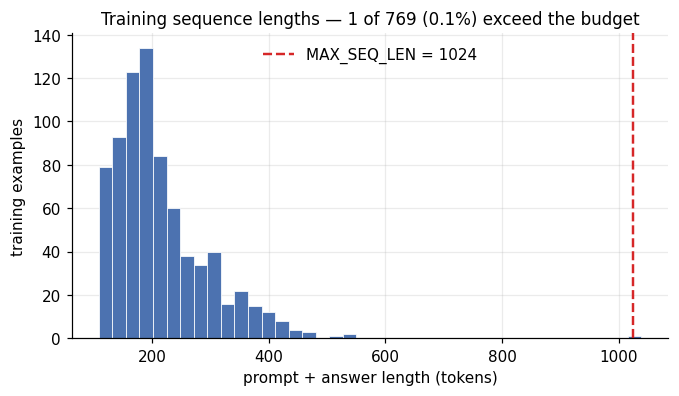

86

In [ ]:
# ------------------------------------------------------------------
# DIAGNOSTIC — training-sequence length budget
# ------------------------------------------------------------------
# The tokeniser used at training time truncates prompt+answer to MAX_SEQ_LEN.
# If EOS is appended BEFORE that truncation (as in the previous run) then every
# example above the budget loses its stop token, and the model learns to keep
# generating until the decoder's cap. This cell quantifies the exposure BEFORE
# training so the fix in Section 7 can be shown to have been necessary.
from transformers import AutoTokenizer as _AutoTok

_diag_tok = _AutoTok.from_pretrained(BASE_MODEL)

def _example_lengths(df, tok, max_len=MAX_SEQ_LEN, limit=None):
    rows = df if limit is None else df.head(limit)
    recs = []
    for _, r in rows.iterrows():
        msgs = [{"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": str(r["instruction"])}]
        prompt = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        p = len(tok(prompt, add_special_tokens=False)["input_ids"])
        a = len(tok(str(r["output"]), add_special_tokens=False)["input_ids"]) + 1  # +1 for EOS
        recs.append({"prompt_tokens": p, "answer_tokens": a, "total_tokens": p + a})
    return pd.DataFrame(recs)

len_df = _example_lengths(train_df, _diag_tok)
over = len_df["total_tokens"] > MAX_SEQ_LEN
TRAIN_LEN_STATS = {
    "n_examples": int(len(len_df)),
    "max_seq_len": int(MAX_SEQ_LEN),
    "median_total_tokens": float(len_df["total_tokens"].median()),
    "p95_total_tokens": float(len_df["total_tokens"].quantile(0.95)),
    "max_total_tokens": int(len_df["total_tokens"].max()),
    "n_over_budget": int(over.sum()),
    "pct_over_budget": float(over.mean() * 100),
}
print(json.dumps(TRAIN_LEN_STATS, indent=2))
with open(f"{OUT_DIR}/train_length_stats.json", "w") as f:
    json.dump(TRAIN_LEN_STATS, f, indent=2)

if over.mean() > 0:
    print(f"\n{over.sum()} of {len(len_df)} examples ({over.mean()*100:.1f}%) exceed "
          f"MAX_SEQ_LEN={MAX_SEQ_LEN}.")
    print("Under the OLD tokenisation these lost their EOS token entirely.")
    print(f"Under TRAIN_LEN_POLICY='{TRAIN_LEN_POLICY}' every example keeps EOS (Section 7).")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(len_df["total_tokens"], bins=40, color="#4c72b0", edgecolor="white", linewidth=0.5)
ax.axvline(MAX_SEQ_LEN, color="#d62728", linestyle="--", linewidth=1.6,
           label=f"MAX_SEQ_LEN = {MAX_SEQ_LEN}")
ax.set_xlabel("prompt + answer length (tokens)"); ax.set_ylabel("training examples")
ax.set_title(f"Training sequence lengths — {over.sum()} of {len(len_df)} "
             f"({over.mean()*100:.1f}%) exceed the budget")
ax.legend(frameon=False)
save_fig(fig, "fig00_training_length_budget",
         "Distribution of training sequence lengths against the truncation budget. "
         "Examples to the right of the dashed line lost their EOS token under the "
         "previous tokenisation.")
plt.show()

del _diag_tok
gc.collect()


## 3. Retrieval corpus & FAISS index

Hand-rolled: bge-base-en-v1.5 → L2-normalised vectors → exact `IndexFlatIP` (cosine).

Five preparation steps, each of which materially affects retrieval quality and each of which belongs in the methodology chapter:

1. **Deduplication** — the Easy Dataset export contains byte-identical repeats; without this a single passage can occupy several top-k slots, shrinking the effective context.
2. **Table flattening** — MinerU renders financial tables as HTML. The tags consume roughly half the token budget and mean nothing to a text embedder, so rows become pipe-delimited lines. Every numeric token is preserved (validated).
3. **Bank attribution from the source filename** — the v8 export is a single merged file holding all three reports, so provenance is taken from each row's own `fileName` (`HSBC-…`, `lbg-…`, `nwg-…`) rather than from the container file or the chunk text. This is not a stylistic choice: **only 11 of 66 chunks name their own institution, and no Lloyds chunk does**. These are extracts of financial statements, where the bank's name lives in the report header rather than in the tables. Attributing by text would mislabel most of the corpus, report Lloyds as absent, and — through the automatic drop rule in Section 5 — leave a Lloyds bank-absence question in the adversarial set where abstaining is now the *wrong* answer.
4. **Disambiguating header** — each chunk is prefixed with `<Bank> — 2023 Annual Report — <section>`. The three reports use near-identical statement wording ("Total equity", "Net interest income"), so without the header their embeddings are nearly indistinguishable, while every eval question names its bank. The header gives the query something to match on and tells a reader of the retrieved context which institution an extract belongs to. Set `PREPEND_CHUNK_HEADER = False` to ablate it and report the difference.
5. **Token-aware sub-chunking** — `bge-base-en-v1.5` encodes a maximum of 512 tokens and **silently truncates** beyond that. Source chunks longer than the limit are split into overlapping windows with parent ids and bank labels retained, so no part of the corpus is unretrievable and no sub-chunk loses its attribution.

Counts from every step, including per-bank chunk and word totals, are written to `corpus_log.json`. The cell finishes with a **bank-aware retrieval probe**: a high similarity score means the index found something similar, not that it found the right bank, and with three near-identical sets of statements that distinction is the main risk to the RAG and Hybrid conditions.


In [ ]:
import html as _html

# MinerU emits financial tables as HTML. The tags cost ~50% of the token budget
# and carry no meaning for a text embedder, so rows are rewritten as
# pipe-delimited lines. Validated to preserve every numeric token exactly.
def flatten_tables(text):
    def row_repr(m):
        cells = re.findall(r"<t[dh][^>]*>(.*?)</t[dh]>", m.group(0), flags=re.S)
        cells = [re.sub(r"<[^>]+>", " ", c).strip() for c in cells]
        return " | ".join(cells) + "\n"
    text = re.sub(r"<tr[^>]*>.*?</tr>", row_repr, text, flags=re.S)
    text = re.sub(r"</?(table|tbody|thead)[^>]*>", "\n", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = _html.unescape(text)
    text = text.replace("一", "-")     # MinerU OCR artefact: en-dash read as a CJK glyph
    text = re.sub(r"[ \t]+", " ", text)
    return re.sub(r"\n{3,}", "\n\n", text).strip()

def fallback_chunk(text, size=CHUNK_WORDS, overlap=CHUNK_OVERLAP):
    words = text.split(); chunks, i = [], 0
    while i < len(words):
        chunks.append(" ".join(words[i:i + size])); i += size - overlap
    return chunks

# Banks the adversarial set may claim are absent. The three under study come from
# BANK_REGISTRY; the rest are the distractors used in Section 5, listed here so
# that indexing any of them in future automatically retires the matching question.
OTHER_BANK_PATTERNS = {
    "Barclays": r"\bBarclays\b",
    "Standard Chartered": r"\bStandard Chartered\b",
    "Santander": r"\bSantander\b",
    "Metro Bank": r"\bMetro Bank\b",
    "Virgin Money": r"\bVirgin Money\b",
    "Nationwide": r"\bNationwide Building Society\b",
    "TSB": r"\bTSB\b",
    "Co-operative Bank": r"\bCo-operative Bank\b",
}

def bank_of_row(file_name, chunk_name, text):
    """Assign a chunk to a bank. Filename first, then chunk name, then text.

    Filename is authoritative because these exports are per-report: every chunk in
    lbg-2023-core-financials.pdf is Lloyds whether or not the word appears in it.
    Text matching is only a fallback for corpora without usable filenames, and it
    is the WRONG primary signal here — in the v8 export 55 of 66 chunks never name
    their own institution, and no Lloyds chunk does.
    """
    for field in (str(file_name), str(chunk_name)):
        for tag, rx in BANK_FILE_RE.items():
            if rx.search(field):
                return tag, "filename"
    found = banks_mentioned(text)
    if len(found) == 1:
        return found[0], "text"
    return "unknown", "unassigned"

def _read_one_corpus(path):
    ext = os.path.splitext(path)[1].lower()
    if ext in (".csv", ".tsv"):
        cdf = pd.read_csv(path, sep="\t" if ext == ".tsv" else ",")
        col = next((c for c in ["text", "chunk", "content", "chunk_text"] if c in cdf.columns), None)
        assert col, f"No text column found in {path}"
        texts = cdf[col].dropna().astype(str).tolist()
        ids = cdf["chunk_id"].astype(str).tolist() if "chunk_id" in cdf.columns else [f"chunk_{i}" for i in range(len(texts))]
        files = (cdf["fileName"].astype(str).tolist() if "fileName" in cdf.columns
                 else [os.path.basename(path)] * len(texts))
        sections = (cdf["summary"].astype(str).tolist() if "summary" in cdf.columns
                    else [""] * len(texts))
        src = "chunk table"
    elif ext in (".jsonl", ".json"):
        rows = [json.loads(l) for l in open(path)] if ext == ".jsonl" else json.load(open(path))
        if isinstance(rows, dict):
            rows = rows.get("chunks") or rows.get("data") or list(rows.values())
        texts = [r.get("text") or r.get("chunk") or r.get("content") or "" for r in rows]
        ids = [str(r.get("chunk_id") or r.get("name") or f"chunk_{i}")
               for i, r in enumerate(rows)]
        # v8: a MERGED export holds all three reports, so provenance must come from
        # each row's own fileName. Falling back to the container filename (as v4
        # did) would label every chunk with the merged file and destroy the
        # per-bank analysis in Section 11.
        files = [str(r.get("fileName") or r.get("source") or os.path.basename(path))
                 for r in rows]
        sections = [str(r.get("summary") or r.get("section") or "") for r in rows]
        src = "chunk export (json)"
    else:
        raw = open(path, encoding="utf-8").read()
        texts = fallback_chunk(raw)
        ids = [f"chunk_{i}" for i in range(len(texts))]
        files = [os.path.basename(path)] * len(texts)
        sections = [""] * len(texts)
        src = f"auto-chunked {ext}"
    return pd.DataFrame({"chunk_id": ids, "text": [str(t) for t in texts],
                         "source_file": files, "section": sections,
                         "container_file": os.path.basename(path)}), src

def load_corpus(paths):
    paths = [paths] if isinstance(paths, str) else list(paths)
    found = [p for p in paths if os.path.exists(p)]
    missing = [p for p in paths if not os.path.exists(p)]
    for p in missing:
        print(f"NOTE: corpus file not found, skipping -> {p}")

    if not found:
        print("=" * 78)
        print("WARNING: no CORPUS_PATH found — building PSEUDO-CORPUS from training answers.")
        print("Pipeline smoke-testing ONLY; replace with the MinerU chunk export before")
        print("any run you intend to report.")
        print("=" * 78)
        corpus = pd.DataFrame({"chunk_id": [f"pseudo_{i}" for i in range(len(train_df))],
                               "text": train_df["output"].astype(str).tolist(),
                               "source_file": "PSEUDO", "section": "",
                               "container_file": "PSEUDO"})
        srcs = ["PSEUDO-CORPUS (invalid for reporting)"]
    else:
        parts, srcs = [], []
        for p in found:
            part, s = _read_one_corpus(p)
            parts.append(part); srcs.append(f"{os.path.basename(p)}: {s} ({len(part)} rows)")
        corpus = pd.concat(parts, ignore_index=True)

    clog = {"sources": srcs, "files_loaded": len(found), "raw_chunks": len(corpus)}

    corpus = corpus[corpus["text"].str.strip().str.len() > 0]
    clog["after_drop_empty"] = len(corpus)

    # Easy Dataset writes one row per generated QA pair, so the same passage text
    # recurs once per question drawn from it. Deduplicating is correct — but the
    # multiplicity is reported here because a large drop is worth understanding
    # rather than assuming, and because effective corpus size drives every
    # retrieval and faithfulness number downstream.
    dup_counts = corpus["text"].value_counts()
    clog["duplicate_groups"] = int((dup_counts > 1).sum())
    clog["max_multiplicity"] = int(dup_counts.max()) if len(dup_counts) else 0
    clog["median_multiplicity"] = float(dup_counts.median()) if len(dup_counts) else 0.0
    corpus = corpus.drop_duplicates(subset=["text"]).reset_index(drop=True)
    clog["after_dedupe"] = len(corpus)

    if FLATTEN_TABLES:
        corpus["text"] = corpus["text"].map(flatten_tables)
        clog["tables_flattened"] = True

    id_counts = corpus["chunk_id"].value_counts()
    corpus["chunk_id"] = [f"{cid}#{i}" if id_counts.get(cid, 0) > 1 else cid
                          for i, cid in enumerate(corpus["chunk_id"])]

    # ---- bank provenance ----
    assigned = [bank_of_row(r["source_file"], r["chunk_id"], r["text"])
                for _, r in corpus.iterrows()]
    corpus["bank"] = [a[0] for a in assigned]
    corpus["bank_source"] = [a[1] for a in assigned]
    clog["bank_assignment_method"] = pd.Series(corpus["bank_source"]).value_counts().to_dict()

    # ---- disambiguating header ----
    # The three reports use near-identical statement wording ("Total equity", "Net
    # interest income"), and most chunks never name their own bank, so their
    # embeddings are nearly indistinguishable. Every eval question DOES name its
    # bank, so a one-line header gives the query something to match against and
    # tells the reader of the RAG context which institution an extract belongs to.
    # This is a deliberate methodological intervention: record it in Chapter 3, and
    # set PREPEND_CHUNK_HEADER=False to ablate it.
    def _header(r):
        full = BANK_REGISTRY.get(r["bank"], {}).get("full", "Unattributed source")
        sect = str(r["section"]).strip()
        return f"{full} — {REPORT_YEAR} Annual Report" + (f" — {sect}" if sect else "")
    corpus["header"] = corpus.apply(_header, axis=1)
    if PREPEND_CHUNK_HEADER:
        corpus["text"] = corpus["header"] + "\n" + corpus["text"]
        clog["chunk_header_prepended"] = True

    # ---- coverage report ----
    joined = " ".join(corpus["text"].tolist())
    clog["banks_present"] = sorted({BANK_LABELS[b] for b in corpus["bank"].unique()
                                    if b in BANK_LABELS})
    clog["other_banks_present"] = sorted([b for b, pat in OTHER_BANK_PATTERNS.items()
                                          if re.search(pat, joined, re.I)])
    clog["total_words"] = int(sum(len(t.split()) for t in corpus["text"]))
    clog["per_bank"] = {
        BANK_LABELS.get(b, b): {"chunks": int(len(g)),
                                "words": int(sum(len(t.split()) for t in g["text"])),
                                "files": sorted(set(g["source_file"]))}
        for b, g in corpus.groupby("bank")}

    print(json.dumps(clog, indent=2))
    if len(corpus) < MIN_CORPUS_CHUNKS:
        print("=" * 78)
        print(f"COVERAGE WARNING: only {len(corpus)} unique chunks (~{clog['total_words']:,} words).")
        print("At this size the index covers a small extract rather than a full report, which")
        print("inflates claim-level hallucination rates (unsupported often just means 'not in")
        print("these chunks') and makes the adversarial set trivially unanswerable.")
        print("Add more exports to CORPUS_PATH, or ingest more of each report, before reporting.")
        print("=" * 78)

    thin = {b: v["chunks"] for b, v in clog["per_bank"].items()
            if b != "unknown" and v["chunks"] < MIN_CHUNKS_PER_BANK}
    if thin:
        print("=" * 78)
        print("PER-BANK COVERAGE WARNING: " + ", ".join(f"{b} has only {n} chunks"
                                                        for b, n in thin.items()))
        print("A bank with thin coverage will look worse under RAG for reasons that have")
        print("nothing to do with the retrieval strategy. Quote chunk counts alongside the")
        print("per-bank results table in Section 11.")
        print("=" * 78)

    missing_banks = [BANK_LABELS[b] for b in BANK_TAGS
                     if b not in set(corpus["bank"])]
    if missing_banks:
        print(f"WARNING: no chunks assigned to {', '.join(missing_banks)}. Check that the "
              "export's fileName values match the `file` patterns in BANK_REGISTRY.")
    if (corpus["bank"] == "unknown").any():
        n_unk = int((corpus["bank"] == "unknown").sum())
        print(f"WARNING: {n_unk} chunks could not be attributed to a bank. They stay in the "
              "index but count against retrieval bank-precision in Section 11.")
    return corpus, clog

corpus_df, corpus_log = load_corpus(CORPUS_PATH)

# Tags of the three study banks that are actually indexed, plus the labels of any
# OTHER bank found in the text — both consumed by the adversarial set in Section 5.
BANKS_IN_CORPUS  = {BANK_LABELS[b] for b in corpus_df["bank"].unique() if b in BANK_LABELS}
BANKS_IN_CORPUS |= set(corpus_log.get("other_banks_present", []))
CHUNK_BANK = dict(zip(corpus_df["chunk_id"].astype(str), corpus_df["bank"]))
print("\nBanks detected in corpus:", sorted(BANKS_IN_CORPUS) or "none")
print("Chunks per bank:", {BANK_LABELS.get(b, b): int(n)
                           for b, n in corpus_df["bank"].value_counts().items()})


{
  "sources": [
    "3bankfinancialschunksmerged.json: chunk export (json) (66 rows)"
  ],
  "files_loaded": 1,
  "raw_chunks": 66,
  "after_drop_empty": 66,
  "duplicate_groups": 0,
  "max_multiplicity": 1,
  "median_multiplicity": 1.0,
  "after_dedupe": 66,
  "tables_flattened": true,
  "bank_assignment_method": {
    "filename": 66
  },
  "chunk_header_prepended": true,
  "banks_present": [
    "HSBC",
    "Lloyds",
    "NatWest"
  ],
  "other_banks_present": [],
  "total_words": 24628,
  "per_bank": {
    "HSBC": {
      "chunks": 27,
      "words": 10265,
      "files": [
        "HSBC-2023-core-financials.pdf"
      ]
    },
    "Lloyds": {
      "chunks": 18,
      "words": 7586,
      "files": [
        "lbg-2023-core-financials.pdf"
      ]
    },
    "NatWest": {
      "chunks": 21,
      "words": 6777,
      "files": [
        "nwg-2023-core-financials.pdf"
      ]
    }
  }
}

Banks detected in corpus: ['HSBC', 'Lloyds', 'NatWest']
Chunks per bank: {'HSBC': 27, 'NatWest': 

In [ ]:
import faiss
from sentence_transformers import SentenceTransformer

INDEX_PATH, CORPUS_SAVE = f"{OUT_DIR}/faiss_flatip.index", f"{OUT_DIR}/corpus_indexed.csv"
embedder = SentenceTransformer(EMBED_MODEL, device="cuda")

# bge-base-en-v1.5 encodes at most 512 tokens; anything beyond that is SILENTLY
# TRUNCATED and therefore unretrievable. Source chunks are split into overlapping
# windows inside that budget, keeping parent ids for provenance.
#
# v8: bank, source_file and header travel with every sub-chunk. Without this the
# bank label is lost at the split boundary and retrieval bank-precision cannot be
# measured. When headers are enabled the header is re-prepended to each sub-chunk,
# because a sub-chunk taken from the middle of a long table would otherwise carry
# no attribution at all.
def split_for_embedding(df, tokenizer, max_tokens=EMBED_MAX_TOKENS, overlap=EMBED_SUB_OVERLAP):
    recs, n_split = [], 0
    carry = ["bank", "bank_source", "source_file", "section", "header"]
    for _, r in df.iterrows():
        meta = {c: r[c] for c in carry if c in df.columns}
        ids = tokenizer.encode(str(r["text"]), add_special_tokens=False)
        if len(ids) <= max_tokens:
            recs.append({"chunk_id": r["chunk_id"], "parent_id": r["chunk_id"],
                         "n_tokens": len(ids), "text": r["text"], **meta})
            continue
        n_split += 1
        step, part = max_tokens - overlap, 0
        for s in range(0, len(ids), step):
            piece = ids[s:s + max_tokens]
            if not piece: break
            piece_text = tokenizer.decode(piece)
            if PREPEND_CHUNK_HEADER and part > 0 and meta.get("header"):
                piece_text = f"{meta['header']}\n{piece_text}"
            recs.append({"chunk_id": f"{r['chunk_id']}::s{part}",
                         "parent_id": r["chunk_id"], "n_tokens": len(piece),
                         "text": piece_text, **meta})
            part += 1
            if s + max_tokens >= len(ids): break
    out = pd.DataFrame(recs)
    print(f"Embedding units: {len(df)} source chunks -> {len(out)} sub-chunks "
          f"({n_split} exceeded the {max_tokens}-token limit and were split)")
    print(f"  token length: median={out['n_tokens'].median():.0f} max={out['n_tokens'].max()}")
    if "bank" in out.columns:
        print("  units per bank:", {BANK_LABELS.get(b, b): int(n)
                                    for b, n in out["bank"].value_counts().items()})
    return out

corpus_df = split_for_embedding(corpus_df, embedder.tokenizer)
corpus_log["embedding_subchunks"] = len(corpus_df)
corpus_log["embedding_subchunks_per_bank"] = {
    BANK_LABELS.get(b, b): int(n) for b, n in corpus_df["bank"].value_counts().items()}
with open(f"{OUT_DIR}/corpus_log.json", "w") as f:
    json.dump(corpus_log, f, indent=2)

if os.path.exists(INDEX_PATH) and os.path.exists(CORPUS_SAVE):
    index = faiss.read_index(INDEX_PATH)
    saved_corpus = pd.read_csv(CORPUS_SAVE)
    if index.ntotal == len(saved_corpus) == len(corpus_df) and \
       saved_corpus["chunk_id"].astype(str).tolist() == corpus_df["chunk_id"].astype(str).tolist():
        corpus_df = saved_corpus
        print(f"Reloaded persisted index ({index.ntotal} vectors, matches current corpus).")
    else:
        print(f"Persisted index is STALE ({index.ntotal} vectors vs corpus {len(corpus_df)}) — rebuilding.")
        index = None
else:
    index = None

if index is None:
    emb = embedder.encode(corpus_df["text"].tolist(), batch_size=64,
                          show_progress_bar=True, normalize_embeddings=True).astype("float32")
    index = faiss.IndexFlatIP(emb.shape[1]); index.add(emb)
    faiss.write_index(index, INDEX_PATH)
    corpus_df.to_csv(CORPUS_SAVE, index=False)
    print(f"Built index: {index.ntotal} vectors")

# Sub-chunk id -> bank, rebuilt AFTER splitting so it covers the ids that actually
# appear in retrieved_ids. Section 11 joins on this to measure bank-precision.
CHUNK_BANK = dict(zip(corpus_df["chunk_id"].astype(str), corpus_df["bank"]))

# Bulk encoding is done; keep the embedder on the CPU for the rest of the run.
# Encoding one query costs ~20 ms on CPU, and leaving it (plus its cached
# activations from batch encoding) on the GPU is what starves the 4-bit LLM load.
embedder.to("cpu")
gc.collect(); torch.cuda.empty_cache()
print("Embedder moved to CPU.", gpu_mem())

BGE_QUERY_PREFIX = "Represent this sentence for searching relevant passages: "

def retrieve(question, k=TOP_K):
    q = embedder.encode([BGE_QUERY_PREFIX + question], normalize_embeddings=True).astype("float32")
    scores, idxs = index.search(q, k)
    out = []
    for s, i in zip(scores[0], idxs[0]):
        if i == -1: continue
        row = corpus_df.iloc[int(i)]
        out.append({"chunk_id": str(row["chunk_id"]),
                    "parent_id": str(row.get("parent_id", row["chunk_id"])),
                    "bank": str(row.get("bank", "unknown")),
                    "score": float(s),
                    "text": str(row["text"])})
    return out

# ---- retrieval smoke test, now bank-aware ----
# A high top-1 score means the index found SOMETHING similar; it does not mean it
# found the right bank. With three near-identical sets of statements that
# distinction is the whole risk, so the probe checks it explicitly on a small
# stratified sample before any condition runs.
_probe = stratified_sample(eval_df, min(12, len(eval_df)))
_hits_ok, _rows = 0, []
for _, _r in _probe.iterrows():
    _h = retrieve(_r["question"])
    _top = _h[0] if _h else None
    _ok = bool(_top and _top["bank"] == _r["bank"])
    _hits_ok += _ok
    _rows.append({"bank": _r["bank"], "top1_bank": _top["bank"] if _top else None,
                  "top1_score": round(_top["score"], 3) if _top else None,
                  "any_of_topk_right_bank": any(h["bank"] == _r["bank"] for h in _h)})
_probe_df = pd.DataFrame(_rows)
print(f"\nRetrieval probe on {len(_probe_df)} questions — "
      f"top-1 is the right bank {_hits_ok}/{len(_probe_df)}, "
      f"right bank anywhere in top-{TOP_K} "
      f"{int(_probe_df['any_of_topk_right_bank'].sum())}/{len(_probe_df)}")
display(_probe_df)
if len(_probe_df) and _hits_ok / len(_probe_df) < 0.5:
    print("=" * 78)
    print("RETRIEVAL WARNING: fewer than half of top-1 hits come from the bank the")
    print("question asks about. The RAG and Hybrid conditions are being fed the wrong")
    print("institution's figures, which will read as a strategy effect when it is an")
    print("indexing one. Check PREPEND_CHUNK_HEADER is True, then consider raising TOP_K.")
    print("=" * 78)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (878 > 512). Running this sequence through the model will result in indexing errors


Embedding units: 66 source chunks -> 113 sub-chunks (45 exceeded the 480-token limit and were split)
  token length: median=418 max=480
  units per bank: {'HSBC': 48, 'Lloyds': 33, 'NatWest': 32}


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Built index: 113 vectors
Embedder moved to CPU. {'driver_free_gb': 15.474688, 'torch_allocated_gb': 0.009568256, 'torch_reserved_gb': 0.025165824, 'total_gb': 15.637086208}

Retrieval probe on 15 questions — top-1 is the right bank 15/15, right bank anywhere in top-6 15/15


,bank,top1_bank,top1_score,any_of_topk_right_bank
0,lloyds,lloyds,0.811,True
1,hsbc,hsbc,0.828,True
2,hsbc,hsbc,0.722,True
3,natwest,natwest,0.791,True
4,natwest,natwest,0.772,True
5,lloyds,lloyds,0.846,True
6,natwest,natwest,0.779,True
7,hsbc,hsbc,0.744,True
8,natwest,natwest,0.797,True
9,lloyds,lloyds,0.732,True


### Diagnostic — retrieval corpus profile

Chunk length against the encoder limit, and chunk counts per source document. Figure 01 belongs in the methodology chapter alongside the corpus construction description.

  saved fig01_corpus_profile.png


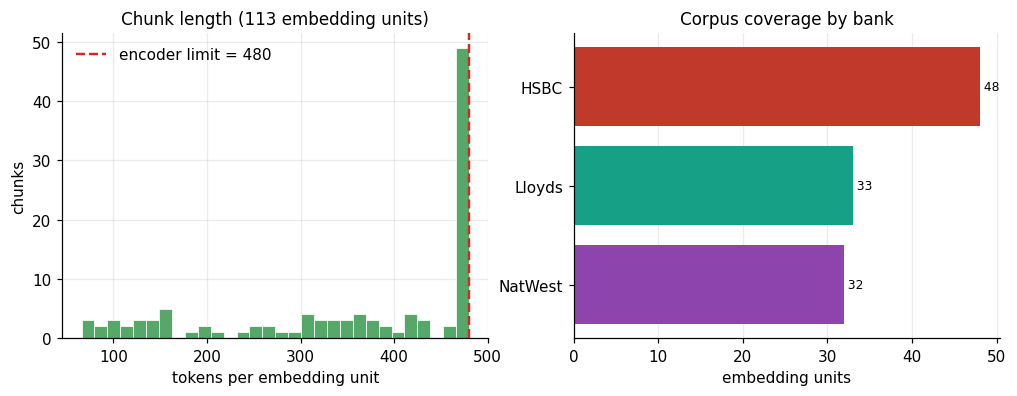

Corpus: 113 embedding units, 40,555 tokens total, median 418 tokens/unit
Words per bank: {'HSBC': 10265, 'Lloyds': 7586, 'NatWest': 6777}


In [ ]:
# ------------------------------------------------------------------
# DIAGNOSTIC — retrieval corpus shape
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(corpus_df["n_tokens"], bins=30, color="#55a868", edgecolor="white", linewidth=0.5)
axes[0].axvline(EMBED_MAX_TOKENS, color="#d62728", linestyle="--", linewidth=1.6,
                label=f"encoder limit = {EMBED_MAX_TOKENS}")
axes[0].set_xlabel("tokens per embedding unit"); axes[0].set_ylabel("chunks")
axes[0].set_title(f"Chunk length ({len(corpus_df)} embedding units)")
axes[0].legend(frameon=False)

# v8: counts per BANK rather than per chunk-id prefix. Unequal coverage is a
# confound for the per-bank results table, so it has to be visible.
bank_counts = corpus_df["bank"].map(lambda b: BANK_LABELS.get(b, b)).value_counts()
axes[1].barh(bank_counts.index[::-1].tolist(), bank_counts.values[::-1].tolist(),
             color=[BANK_COLOURS.get(b, "#4c72b0") for b in bank_counts.index[::-1]])
axes[1].set_xlabel("embedding units"); axes[1].set_title("Corpus coverage by bank")
axes[1].grid(axis="y", alpha=0)
for i, v in enumerate(bank_counts.values[::-1]):
    axes[1].text(v, i, f" {v}", va="center", fontsize=8)

save_fig(fig, "fig01_corpus_profile",
         "Retrieval corpus profile: token length per embedding unit against the "
         "encoder limit, and embedding units per bank. Unequal coverage across the "
         "three reports is a confound for the per-bank results and is reported here "
         "so it can be quoted alongside them.")
plt.show()

print(f"Corpus: {len(corpus_df)} embedding units, "
      f"{corpus_df['n_tokens'].sum():,} tokens total, "
      f"median {corpus_df['n_tokens'].median():.0f} tokens/unit")
print("Words per bank:", {k: v["words"] for k, v in corpus_log.get("per_bank", {}).items()})


## 4. Model, type-aware prompting & the shared inference loop

One base model, one greedy decoding config, one prompt builder — the answer-format instruction depends only on `question_type`, and is **identical across all four conditions**, so strategy is the only independent variable.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

BNB_CONFIG = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.float16,
)

MIN_FREE_GB = 6.0   # 4-bit Qwen2.5-7B needs ~5.5 GB of weights plus working space

def load_base_model():
    # Reclaim anything cached before planning the device map.
    gc.collect(); torch.cuda.empty_cache()
    m = gpu_mem()
    print(f"Loading base model — {m['driver_free_gb']:.2f} GB free "
          f"(torch reserved {m['torch_reserved_gb']:.2f} GB)")
    if m["driver_free_gb"] < MIN_FREE_GB:
        raise RuntimeError(
            f"Only {m['driver_free_gb']:.2f} GB free; need ~{MIN_FREE_GB} GB.\n"
            "Something is still holding VRAM. Fixes, in order:\n"
            "  1. Run the free_gpu(...) prologue at the top of this section.\n"
            "  2. Runtime -> Restart session, then re-run from the top with the\n"
            "     already-completed stage flags set to False.\n"
            "Stage flags + Drive checkpoints mean no completed work is lost.")

    tok = AutoTokenizer.from_pretrained(BASE_MODEL)
    mdl = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL, quantization_config=BNB_CONFIG,
        # Pinned to GPU 0 rather than "auto": on a single-GPU runtime "auto" will
        # silently dispatch layers to CPU/disk when memory looks tight, which
        # bitsandbytes rejects for 4-bit weights. Pinning fails fast instead.
        device_map={"": 0}, torch_dtype=torch.float16)
    mdl.eval()
    return mdl, tok

LETTERS = list(string.ascii_uppercase)

TYPE_INSTRUCTIONS = {
    "true_false":      'Answer with exactly one word: "True" or "False".',
    "single_choice":   "Answer with the letter of the single correct option, and nothing else.",
    "multiple_choice": 'Answer with the letters of ALL correct options, separated by commas (e.g. "A, C").',
    "short_answer":    "Answer with the exact figure or short phrase only — no explanation.",
    "open_ended":      "",
    "adversarial_absent": "",
}

def format_question(row):
    q = str(row["question"]).strip()
    if row.get("options_list"):
        opts = "\n".join(f"{LETTERS[i]}. {o}" for i, o in enumerate(row["options_list"]))
        q = q + "\n\nOptions:\n" + opts
    instr = TYPE_INSTRUCTIONS.get(row.get("question_type", "open_ended"), "")
    return (q + "\n\n" + instr).strip()

def build_messages(row, context_hits=None):
    user_q = format_question(row)
    if context_hits:
        ctx = "\n\n".join(f"[{h['chunk_id']}] {h['text']}" for h in context_hits)
        user = ("Use ONLY the following extracts from the annual report to answer. "
                "If the answer is not contained in the extracts, say so explicitly.\n\n"
                "--- EXTRACTS ---\n" + ctx + "\n--- END EXTRACTS ---\n\n" + user_q)
    else:
        user = user_q
    return [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user}]

@torch.no_grad()
def generate_answer(model, tokenizer, row, context_hits=None):
    # Returns (text, n_generated_tokens). The token count is what makes runaway
    # generation measurable: an adapter that has lost its stop token produces
    # answers pinned at MAX_NEW_TOKENS, which is invisible in the decoded text
    # but obvious in this number.
    prompt = tokenizer.apply_chat_template(build_messages(row, context_hits),
                                           tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=3584).to(model.device)
    out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False,
                         temperature=None, top_p=None, top_k=None,
                         pad_token_id=tokenizer.eos_token_id)
    new_ids = out[0][inputs["input_ids"].shape[1]:]
    text = tokenizer.decode(new_ids, skip_special_tokens=True).strip()
    return text, int(new_ids.shape[0])


In [ ]:
# Resumable inference loop. `suffix` distinguishes the main eval set ("")
# from robustness sets ("_para", "_adv"). Retrieved context text is stored so the
# faithfulness judge can grade grounding later.
#
# v4 additions, all needed by the figures in Section 11:
#   gen_tokens      - number of tokens actually generated, so runaway generation
#                     and cap-hitting can be measured rather than inferred
#   hit_token_cap   - whether generation stopped because of MAX_NEW_TOKENS
#   retrieval_top1  - similarity of the best-matching chunk
#   retrieval_scores- all top-k similarities, for the retrieval-quality figure
#
# v8 additions:
#   bank            - which bank the question is about, so results can be split
#                     three ways without re-joining against the eval file
#   adv_tier        - carried through for the adversarial set. v4 built this
#                     column in adv_df but never wrote it to the results CSV, so
#                     the fabricated-vs-bank-absent breakdown in Section 11 was
#                     silently skipped on every run.
#   retrieved_banks / retrieval_bank_hit / retrieval_bank_precision
#                   - whether retrieval returned the institution the question asks
#                     about. Three reports with near-identical statement wording
#                     make cross-bank retrieval the main failure mode, and it is
#                     invisible in a similarity score.

def run_condition(cond_name, model, tokenizer, use_rag, df=None, suffix=""):
    df = eval_df if df is None else df
    out_path = f"{OUT_DIR}/results_{cond_name}{suffix}.csv"
    cols = ["qid", "question_type", "bank", "adv_tier", "question", "reference", "prediction",
            "retrieved_ids", "retrieved_banks", "retrieval_scores", "retrieval_top1",
            "retrieval_bank_hit", "retrieval_bank_precision", "context",
            "gen_tokens", "hit_token_cap", "latency_s"]
    done = pd.read_csv(out_path) if os.path.exists(out_path) else pd.DataFrame(columns=cols)
    # A results file written before v8 lacks the bank/retrieval-precision columns.
    # Backfilling here keeps the resume path working; the affected rows simply carry
    # nulls, and the figures that depend on those columns skip them.
    _missing = [c for c in cols if c not in done.columns]
    for c in _missing:
        done[c] = np.nan
    if _missing and len(done):
        print(f"  note: {len(done)} resumed rows predate v8 and lack {_missing}. "
              "Delete this CSV and re-run if you need those columns populated.")
    done_ids = set(done["qid"].astype(str))
    rows = list(done.to_dict("records"))
    todo = df[~df["qid"].astype(str).isin(done_ids)]
    print(f"[{cond_name}{suffix}] {len(done_ids)} done, {len(todo)} to run")

    with stage_timer(f"infer_{cond_name}{suffix}"):
        for n, (_, r) in enumerate(todo.iterrows(), 1):
            t0 = time.time()
            hits = retrieve(r["question"]) if use_rag else None
            pred, n_tok = generate_answer(model, tokenizer, r, hits)
            q_bank = str(r.get("bank", "unknown"))
            hit_banks = [h.get("bank", "unknown") for h in hits] if hits else []
            rows.append({
                "qid": str(r["qid"]),
                "question_type": r.get("question_type", "open_ended"),
                "bank": q_bank,
                "adv_tier": r.get("adv_tier", ""),
                "question": r["question"],
                "reference": r["reference"],
                "prediction": pred,
                "retrieved_ids": ";".join(h["chunk_id"] for h in hits) if hits else "",
                "retrieved_banks": ";".join(hit_banks) if hits else "",
                "retrieval_scores": ";".join(f"{h['score']:.4f}" for h in hits) if hits else "",
                "retrieval_top1": (max(h["score"] for h in hits) if hits else None),
                # top-1 came from the right institution (1/0); null when not a RAG
                # condition or when the question has no bank (adversarial set)
                "retrieval_bank_hit": (float(hit_banks[0] == q_bank)
                                       if hits and q_bank in BANK_REGISTRY else None),
                # share of the top-k window spent on the right institution
                "retrieval_bank_precision": (
                    float(sum(b == q_bank for b in hit_banks) / len(hit_banks))
                    if hits and q_bank in BANK_REGISTRY else None),
                "context": (" ||| ".join(h["text"] for h in hits))[:8000] if hits else "",
                "gen_tokens": int(n_tok),
                "hit_token_cap": int(n_tok >= MAX_NEW_TOKENS),
                "latency_s": round(time.time() - t0, 2),
            })
            if n % 5 == 0 or n == len(todo):
                pd.DataFrame(rows).to_csv(out_path, index=False)
                print(f"  {len(rows)}/{len(df)} saved (last {rows[-1]['latency_s']}s, "
                      f"{rows[-1]['gen_tokens']} tok)")
    out_df = pd.DataFrame(rows)
    for c in cols:
        if c not in out_df.columns:
            out_df[c] = np.nan
    out_df = out_df[cols + [c for c in out_df.columns if c not in cols]]
    out_df.to_csv(out_path, index=False)
    capped = out_df["hit_token_cap"].mean() if len(out_df) else float("nan")
    note = (f"({capped*100:.0f}% of answers hit the {MAX_NEW_TOKENS}-token cap)"
            if pd.notna(capped) else "(token counts unavailable for resumed rows)")
    print(f"[{cond_name}{suffix}] complete -> {out_path}  {note}")
    if use_rag and out_df["retrieval_bank_hit"].notna().any():
        print(f"  retrieval: top-1 correct bank {out_df['retrieval_bank_hit'].mean()*100:.0f}%, "
              f"mean top-{TOP_K} bank precision "
              f"{out_df['retrieval_bank_precision'].mean()*100:.0f}%")


## 5. Robustness sets (ToR Metric 4)

Two perturbation sets, both cached to Drive so every condition sees the *same* perturbations. Caches are version-tagged and are rejected if they are materially undersized **or** if their bank mix does not match the current three-bank set.

- **Paraphrased** — a seeded sample of objective-type questions (so the delta is automatically scorable), reworded once by DeepSeek and **stratified by bank and question type**: an unstratified sample of 36 from 300 can easily land half its questions on one bank, and the paraphrase delta would then describe that bank rather than the system. The paraphrase instruction explicitly preserves the bank name and financial year, since those identify which report the answer comes from. Requires `DEEPSEEK_API_KEY` only on first generation (~£0.01).

- **Adversarial absent-content** — questions whose answers are **not in the corpus**. Abstention is the correct behaviour; answering with a number is a hallucination. Three tiers, because they fail for different reasons and only one survives corpus expansion:

  | Tier | What it is | Survives adding a bank? |
  |---|---|---|
  | `fabricated` | False premise for any corpus (an Antarctic payroll, a video-streaming subsidiary). 4 per bank. | Yes — permanently unanswerable |
  | `out_of_scope_year` | Real bank, real metric, year outside the 2023 reports. 3 per bank. | Yes |
  | `bank_absent` | Answerable in principle, absent only because that institution is not indexed. | **No** — dropped automatically once the bank is detected in the corpus |

  The `out_of_scope_year` tier is new in v8 and is the most diagnostic of the three: the question is entirely plausible, so it is where a fine-tuned model is most likely to answer from parametric memory rather than abstain. That is precisely the behaviour ToR Metric 3 is about, and it is invisible in a tier of obviously absurd questions.


In [ ]:
import requests

DEEPSEEK_LAST_ERROR = {"msg": None}

# DeepSeek V4 models default to THINKING mode: the chain of thought is returned in
# `reasoning_content` and consumes the max_tokens budget, so a short budget yields an
# EMPTY `content`. Thinking is disabled explicitly below — judging needs a short
# deterministic verdict, and thinking mode also ignores `temperature`.
DEEPSEEK_THINKING = {"type": "disabled"}

def deepseek_chat(prompt, max_tokens=300, temperature=0.0, retries=3):
    for attempt in range(retries):
        try:
            resp = requests.post(
                "https://api.deepseek.com/chat/completions",
                headers={"Authorization": f"Bearer {DEEPSEEK_API_KEY}"},
                json={"model": DEEPSEEK_MODEL, "temperature": temperature,
                      "max_tokens": max_tokens,
                      "thinking": DEEPSEEK_THINKING,
                      "messages": [{"role": "user", "content": prompt}]},
                timeout=60)
            if resp.status_code != 200:
                DEEPSEEK_LAST_ERROR["msg"] = f"HTTP {resp.status_code}: {resp.text[:300]}"
                time.sleep(3); continue
            msg = resp.json()["choices"][0]["message"]
            content = (msg.get("content") or "").strip()
            if not content:
                # thinking mode slipped through, or the budget was exhausted
                rc = (msg.get("reasoning_content") or "").strip()
                DEEPSEEK_LAST_ERROR["msg"] = (
                    f"empty content (reasoning_content chars={len(rc)}, "
                    f"finish_reason={resp.json()['choices'][0].get('finish_reason')})")
                time.sleep(2); continue
            return content
        except Exception as e:
            DEEPSEEK_LAST_ERROR["msg"] = f"{type(e).__name__}: {e}"
            time.sleep(3)
    print(f"  !! DeepSeek call failed after {retries} attempts -> {DEEPSEEK_LAST_ERROR['msg']}")
    return None

DEEPSEEK_OK = False
if DEEPSEEK_API_KEY:
    _t = deepseek_chat("Reply with exactly: OK", max_tokens=32)
    DEEPSEEK_OK = bool(_t and _t.strip())   # empty content counts as FAILURE
    if DEEPSEEK_OK:
        print(f"DeepSeek API self-test passed (reply: {_t!r}).")
    else:
        print("=" * 78)
        print("DeepSeek API SELF-TEST FAILED — judge, faithfulness, claim-hallucination and")
        print("paraphrase generation will all be skipped this session.")
        print("Last error:", DEEPSEEK_LAST_ERROR["msg"])
        print("Common causes: wrong/expired model name or key, zero balance, or thinking")
        print("mode consuming the token budget (see DEEPSEEK_THINKING above).")
        print("=" * 78)
else:
    print("DEEPSEEK_API_KEY empty -> judge-based metrics will be skipped.")

# ---------- paraphrase set ----------
OBJECTIVE_TYPES = ["true_false", "single_choice", "multiple_choice", "short_answer"]

def _load_jsonl(path):
    return [json.loads(l) for l in open(path) if l.strip()]

# A cache is only trusted if it is BOTH non-empty and close to the configured
# sample size. The previous run inherited a 2-question file from a smoke test and
# reported paraphrase deltas computed on it, where one question flipping moved the
# metric by 50 points.
cached_para = _load_jsonl(PARAPHRASE_PATH) if os.path.exists(PARAPHRASE_PATH) else []
_min_cache = int(PARAPHRASE_N * MIN_CACHE_FRACTION)
if cached_para and len(cached_para) < _min_cache:
    print(f"Cached paraphrase set has only {len(cached_para)} questions, below the "
          f"{_min_cache} required for PARAPHRASE_N={PARAPHRASE_N} — regenerating.")
    cached_para = []
# v8: a cache generated against a different bank mix is also rejected. A paraphrase
# file left over from the single-bank run would otherwise measure robustness on
# HSBC questions only and report it as a whole-corpus number.
if cached_para:
    _cached_banks = {r.get("bank", "unknown") for r in cached_para}
    if not _cached_banks & set(BANK_TAGS) or len(_cached_banks & set(BANK_TAGS)) < 2:
        print(f"Cached paraphrase set covers banks {sorted(_cached_banks)} — not the current "
              "three-bank mix. Regenerating.")
        cached_para = []

if cached_para:
    para_df = pd.DataFrame(cached_para)
    print(f"Loaded cached paraphrase set: {len(para_df)} questions")
elif DEEPSEEK_OK:
    # Stratified by bank AND type: a simple random sample of 36 from a 300-question
    # set can easily land 20 questions on one bank, and the paraphrase delta would
    # then describe that bank rather than the system.
    pool = eval_df[eval_df["question_type"].isin(OBJECTIVE_TYPES)]
    sample = stratified_sample(pool, min(PARAPHRASE_N, len(pool)))
    out = []
    for _, r in sample.iterrows():
        p = deepseek_chat(
            "Paraphrase the following question so the wording differs but the meaning and "
            "the correct answer are IDENTICAL. Keep the name of the bank and the financial "
            "year exactly as written — they identify which report the answer comes from. "
            "Return only the paraphrased question.\n\n"
            + str(r["question"]))
        if p:
            out.append({"qid": "P_" + str(r["qid"]), "question_type": r["question_type"],
                        "bank": r["bank"], "question": p.strip(),
                        "options_list": r["options_list"],
                        "reference": r["reference"], "orig_qid": str(r["qid"])})
    para_df = pd.DataFrame(out)
    if len(out) >= _min_cache:
        with open(PARAPHRASE_PATH, "w", encoding="utf-8") as f:
            for rec in out:
                f.write(json.dumps(rec, ensure_ascii=False) + "\n")
        print(f"Generated and cached paraphrase set: {len(para_df)} questions")
    else:
        print(f"Only {len(out)} paraphrases generated (need {_min_cache}) — NOT cached, "
              "so the next run retries rather than inheriting an undersized set.")
else:
    para_df = pd.DataFrame()
    print("No usable paraphrase cache and DeepSeek unavailable -> paraphrase robustness skipped.")

if len(para_df) < _min_cache:
    print(f"WARNING: paraphrase sample is {len(para_df)} questions. Metric 4 paraphrase "
          "deltas will be under-powered; report the N alongside the delta.")
elif "bank" in para_df.columns:
    print("Paraphrase sample by bank:", para_df["bank"].value_counts().to_dict())

# ---------- adversarial absent-content set ----------
# Three tiers, because they fail for different reasons and only one of them
# survives corpus expansion:
#
#   FABRICATED        — the premise is false for ANY corpus (an Antarctic payroll,
#                       a video-streaming subsidiary). Permanently unanswerable, so
#                       these stay valid however many banks are indexed.
#   OUT_OF_SCOPE_YEAR — a real bank and a real metric, but a year outside the 2023
#                       reports in the index. This is the tier that most resembles a
#                       plausible user mistake, and the one where a fine-tuned model
#                       is most likely to answer from parametric memory instead of
#                       abstaining — which is exactly the behaviour ToR Metric 3
#                       is about.
#   BANK_ABSENT       — answerable in principle, absent only because that institution
#                       is not indexed. The moment its report is added, abstaining
#                       becomes the WRONG behaviour, so each is dropped automatically
#                       once the bank is detected in the corpus.
#
# v8 rebalance: the v4 set put all 16 fabricated questions on HSBC and listed
# Lloyds and NatWest as absent banks. Both are now indexed, so those questions
# would have been auto-dropped, leaving an HSBC-only adversarial set on a
# three-bank study. Fabricated and out-of-scope-year questions are now spread
# evenly across the three banks, and the absent-bank tier uses only institutions
# genuinely outside the corpus.
ADV_FABRICATED = [
    ("hsbc",    "What was the average salary of HSBC's Antarctic operations staff in 2023?"),
    ("hsbc",    "What percentage of HSBC's 2023 revenue came from its video-streaming subsidiary?"),
    ("hsbc",    "What goodwill impairment did HSBC recognise on its acquisition of Deutsche Bank in 2023?"),
    ("hsbc",    "What was the value of HSBC's gold bullion reserves held on the Moon at end-2023?"),
    ("lloyds",  "What provision did Lloyds Banking Group make in 2023 for the settlement of its lawsuit with Apple Inc.?"),
    ("lloyds",  "How much did Lloyds Banking Group spend on sponsorship of the 2023 FIFA World Cup?"),
    ("lloyds",  "What revenue did Lloyds Banking Group report from its deep-sea mining division in 2023?"),
    ("lloyds",  "What restructuring charge did Lloyds Banking Group book for closing its Iceland branch network in 2023?"),
    ("natwest", "What was NatWest Group's cryptocurrency trading revenue in 2023?"),
    ("natwest", "What was NatWest Group's advertising spend on Japanese television in 2023?"),
    ("natwest", "How many retail branches did NatWest Group operate in Argentina at the end of 2023?"),
    ("natwest", "What carbon offset cost did NatWest Group pay to reforest the Amazon in 2023?"),
]

ADV_OUT_OF_SCOPE_YEAR = [
    ("hsbc",    "What was HSBC's net interest margin in 2015?"),
    ("hsbc",    "What was HSBC's profit before tax for the third quarter of 2019?"),
    ("hsbc",    "What CET1 ratio did HSBC report at 31 December 2026?"),
    ("lloyds",  "What was Lloyds Banking Group's underlying profit in 2014?"),
    ("lloyds",  "What dividend per share did Lloyds Banking Group declare for 2018?"),
    ("lloyds",  "What was Lloyds Banking Group's total equity at 31 December 2026?"),
    ("natwest", "What was NatWest Group's operating profit before tax in 2016?"),
    ("natwest", "How many full-time equivalent employees did NatWest Group report at the end of 2012?"),
    ("natwest", "What was NatWest Group's CET1 ratio at 31 December 2026?"),
]

ADV_BANK_ABSENT = [
    ("Barclays",           "What was Barclays' profit before tax in 2023?"),
    ("Standard Chartered", "What was the CET1 ratio reported by Standard Chartered for 2023?"),
    ("Santander",          "What was Santander UK's cost-efficiency ratio in 2023?"),
    ("Metro Bank",         "What was Metro Bank's impairment charge for 2023?"),
    ("Virgin Money",       "What share buyback did Virgin Money announce in its 2023 annual report?"),
    ("Nationwide",         "What was Nationwide Building Society's underlying profit for the year to April 2023?"),
    ("TSB",                "What statutory profit before tax did TSB report for 2023?"),
    ("Co-operative Bank",  "What was the Co-operative Bank's net interest margin in 2023?"),
    ("Barclays",           "How many employees did Barclays report at the end of 2023?"),
]

def build_adversarial_set():
    recs, dropped = [], []
    for i, (bank, q) in enumerate(ADV_FABRICATED, 1):
        recs.append({"qid": f"ADVF{i:03d}", "question_type": "adversarial_absent",
                     "adv_tier": "fabricated", "bank": bank, "question": q,
                     "options_list": None, "reference": "[NOT IN CORPUS]"})
    for i, (bank, q) in enumerate(ADV_OUT_OF_SCOPE_YEAR, 1):
        recs.append({"qid": f"ADVY{i:03d}", "question_type": "adversarial_absent",
                     "adv_tier": "out_of_scope_year", "bank": bank, "question": q,
                     "options_list": None, "reference": "[NOT IN CORPUS]"})
    for i, (bank, q) in enumerate(ADV_BANK_ABSENT, 1):
        # A question is only unanswerable while that institution is unindexed.
        # BANKS_IN_CORPUS carries display labels for both the study banks and any
        # other bank whose name appears in the corpus text.
        if bank in BANKS_IN_CORPUS:
            dropped.append((bank, q)); continue
        recs.append({"qid": f"ADVB{i:03d}", "question_type": "adversarial_absent",
                     "adv_tier": "bank_absent", "bank": "other", "question": q,
                     "options_list": None, "reference": "[NOT IN CORPUS]"})
    if dropped:
        print(f"Dropped {len(dropped)} bank-absence questions — these banks are now indexed "
              f"and the questions are no longer unanswerable:")
        for bank, q in dropped:
            print(f"  - [{bank}] {q}")
    return recs

ADV_TIERS = ["fabricated", "out_of_scope_year", "bank_absent"]

cached_adv = _load_jsonl(ADVERSARIAL_PATH) if os.path.exists(ADVERSARIAL_PATH) else []
# Reject a cache that predates the three-tier rebalance, otherwise the run silently
# reports v4's HSBC-only adversarial behaviour.
if cached_adv and not any(r.get("adv_tier") == "out_of_scope_year" for r in cached_adv):
    print("Cached adversarial set predates the v8 three-tier rebalance — regenerating.")
    cached_adv = []
if cached_adv and len(cached_adv) >= int(ADV_N * MIN_CACHE_FRACTION):
    adv_df = pd.DataFrame(cached_adv)
    print(f"Loaded cached adversarial set: {len(adv_df)}")
else:
    recs = build_adversarial_set()
    with open(ADVERSARIAL_PATH, "w", encoding="utf-8") as f:
        for rec in recs:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    adv_df = pd.DataFrame(recs)
    print(f"Wrote adversarial set: {len(adv_df)} -> {ADVERSARIAL_PATH}")

if "adv_tier" not in adv_df.columns:
    adv_df["adv_tier"] = "unknown"
if "bank" not in adv_df.columns:
    adv_df["bank"] = "other"

# Take a balanced head rather than a flat one: adv_df.head(ADV_N) would truncate
# whichever tier happens to be written last.
if len(adv_df) > ADV_N:
    per_tier = max(1, ADV_N // adv_df["adv_tier"].nunique())
    adv_df = (adv_df.groupby("adv_tier", group_keys=False)
                    .apply(lambda g: g.head(per_tier))
                    .head(ADV_N).reset_index(drop=True))
adv_df = adv_df.reset_index(drop=True)
if not para_df.empty:
    para_df = para_df.head(PARAPHRASE_N).reset_index(drop=True)

print(f"\nRobustness sets in use — paraphrase: {len(para_df)}, adversarial: {len(adv_df)}")
print("  adversarial by tier:", adv_df["adv_tier"].value_counts().to_dict())
print("  adversarial by bank:", adv_df["bank"].value_counts().to_dict())

def run_robustness(cond_name, model, tokenizer, use_rag):
    if not RUN_ROBUSTNESS:
        return
    if not para_df.empty:
        run_condition(cond_name, model, tokenizer, use_rag, df=para_df, suffix="_para")
    run_condition(cond_name, model, tokenizer, use_rag, df=adv_df, suffix="_adv")


DeepSeek API self-test passed (reply: 'OK').
Cached paraphrase set has only 12 questions, below the 28 required for PARAPHRASE_N=36 — regenerating.
Generated and cached paraphrase set: 36 questions
Paraphrase sample by bank: {'hsbc': 12, 'natwest': 12, 'lloyds': 12}
Loaded cached adversarial set: 30

Robustness sets in use — paraphrase: 36, adversarial: 30
  adversarial by tier: {'fabricated': 12, 'out_of_scope_year': 9, 'bank_absent': 9}
  adversarial by bank: {'other': 9, 'hsbc': 7, 'lloyds': 7, 'natwest': 7}


## 6. Condition D (Baseline) & Condition A (RAG)

In [ ]:
if RUN_BASELINE or RUN_RAG:
    # base_model is included: if this cell failed part-way and is being re-run, the
    # previous model is still resident and the reload would stack a second copy.
    free_gpu("base_model", "base_tok", "tuned_model", "tuned_tok", "ft_model",
             "ft_tok", "trainer")
    base_model, base_tok = load_base_model()
    if RUN_BASELINE:
        run_condition("baseline", base_model, base_tok, use_rag=False)
        run_robustness("baseline", base_model, base_tok, use_rag=False)
    if RUN_RAG:
        run_condition("rag", base_model, base_tok, use_rag=True)
        run_robustness("rag", base_model, base_tok, use_rag=True)
    free_gpu("base_model", "base_tok")
else:
    print("Skipped (flags off).")

VRAM after cleanup: 0.01 GB allocated, 15.47 GB free of 15.6 GB
Loading base model — 15.47 GB free (torch reserved 0.03 GB)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

[baseline] 0 done, 300 to run
  5/300 saved (last 0.85s, 9 tok)
  10/300 saved (last 0.72s, 9 tok)
  15/300 saved (last 0.68s, 8 tok)
  20/300 saved (last 0.34s, 2 tok)
  25/300 saved (last 0.51s, 6 tok)
  30/300 saved (last 0.61s, 6 tok)
  35/300 saved (last 0.55s, 5 tok)
  40/300 saved (last 1.98s, 31 tok)
  45/300 saved (last 0.4s, 4 tok)
  50/300 saved (last 0.39s, 2 tok)
  55/300 saved (last 0.67s, 9 tok)
  60/300 saved (last 0.7s, 8 tok)
  65/300 saved (last 0.37s, 2 tok)
  70/300 saved (last 19.42s, 320 tok)
  75/300 saved (last 11.73s, 195 tok)
  80/300 saved (last 0.34s, 2 tok)
  85/300 saved (last 0.34s, 2 tok)
  90/300 saved (last 0.36s, 2 tok)
  95/300 saved (last 0.56s, 4 tok)
  100/300 saved (last 0.38s, 2 tok)
  105/300 saved (last 8.79s, 147 tok)
  110/300 saved (last 0.62s, 8 tok)
  115/300 saved (last 20.17s, 320 tok)
  120/300 saved (last 0.45s, 5 tok)
  125/300 saved (last 0.39s, 4 tok)
  130/300 saved (last 0.45s, 4 tok)
  135/300 saved (last 0.28s, 2 tok)
  140/30

## 7. Condition B training — QLoRA

`peft` + `transformers.Trainer`, explicit prompt-token masking (loss on answer tokens only), chat template identical to inference. **Memory-aware precision policy:** only norm layers upcast to fp32; frozen embeddings/lm_head stay fp16 (saves ~4 GB vs `prepare_model_for_kbit_training` — the difference between fitting and OOM on a T4).

In [ ]:
if RUN_TRAINING:
    from peft import LoraConfig, get_peft_model
    from transformers import Trainer, TrainingArguments
    from torch.utils.data import Dataset

    # ft_model/ft_tok are included: if this cell OOMs or the runtime drops part-way
    # and it is re-run, the previous model is still resident and the reload would
    # stack a second 4-bit copy on a 15.6 GB card.
    free_gpu("ft_model", "ft_tok", "base_model", "base_tok",
             "tuned_model", "tuned_tok", "trainer")
    if "embedder" in globals():
        embedder.to("cpu"); torch.cuda.empty_cache()   # no-op if already on CPU
    print(f"VRAM before training model load: {torch.cuda.memory_allocated()/1e9:.2f} GB")

    ft_model, ft_tok = load_base_model()
    ft_model.train()

    # Lean k-bit prep (replaces peft.prepare_model_for_kbit_training, which
    # upcasts the ~0.5B-param embedding & lm_head to fp32 => OOM on a 16 GB T4)
    ft_model.config.use_cache = False
    ft_model.gradient_checkpointing_enable()
    ft_model.enable_input_require_grads()
    for _name, _module in ft_model.named_modules():
        if "norm" in _name.lower():
            _module.to(torch.float32)

    lora_cfg = LoraConfig(
        r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
        bias="none", task_type="CAUSAL_LM",
        target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"])
    ft_model = get_peft_model(ft_model, lora_cfg)
    ft_model.print_trainable_parameters()

    # ------------------------------------------------------------------
    # EOS-PRESERVING TOKENISATION
    # ------------------------------------------------------------------
    # Previous version:
    #     full  = prompt + answer + eos
    #     f_ids = tok(full)[:max_len]          <-- truncation drops the EOS
    # Any example longer than max_len therefore ended mid-answer with no stop
    # token, training the model to continue past the end of its answer. At
    # inference that shows up as every generation running to MAX_NEW_TOKENS.
    #
    # Now the answer is truncated to fit the remaining budget and the EOS is
    # re-appended afterwards, so EVERY example ends with a stop token. Examples
    # are tokenised once in __init__ so the budget accounting can be reported and
    # asserted before a single optimiser step is taken.
    EOS_ID = ft_tok.eos_token_id
    assert EOS_ID is not None, "Tokeniser has no eos_token_id — cannot teach the model to stop."
    MIN_ANSWER_TOKENS = 16   # below this the example carries no usable signal

    class SFTDataset(Dataset):
        def __init__(self, df, tok, max_len, policy=TRAIN_LEN_POLICY):
            self.examples = []
            self.stats = {"kept": 0, "truncated": 0, "dropped_overlong": 0,
                          "dropped_no_room": 0}
            for r in df.to_dict("records"):
                msgs = [{"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user", "content": str(r["instruction"])}]
                prompt = tok.apply_chat_template(msgs, tokenize=False,
                                                 add_generation_prompt=True)
                p_ids = tok(prompt, add_special_tokens=False)["input_ids"]
                a_ids = tok(str(r["output"]), add_special_tokens=False)["input_ids"]

                room = max_len - len(p_ids) - 1          # -1 reserves the EOS slot
                if room < MIN_ANSWER_TOKENS:
                    # The prompt alone nearly fills the budget; nothing useful left.
                    self.stats["dropped_no_room"] += 1
                    continue
                if len(a_ids) > room:
                    if policy == "drop":
                        self.stats["dropped_overlong"] += 1
                        continue
                    a_ids = a_ids[:room]
                    self.stats["truncated"] += 1

                a_ids = a_ids + [EOS_ID]                 # EOS appended AFTER truncation
                input_ids = p_ids + a_ids
                labels = [-100] * len(p_ids) + a_ids     # loss on answer tokens only
                assert len(input_ids) == len(labels) <= max_len
                assert input_ids[-1] == EOS_ID
                self.examples.append({"input_ids": input_ids, "labels": labels})
                self.stats["kept"] += 1

        def __len__(self): return len(self.examples)
        def __getitem__(self, i): return self.examples[i]

    train_ds = SFTDataset(train_df, ft_tok, MAX_SEQ_LEN)
    print("Tokenisation budget:", json.dumps(train_ds.stats, indent=2))
    assert len(train_ds) > 0, "No usable training examples after budgeting."
    # Every example must end with EOS, otherwise the collapse recurs silently.
    assert all(e["input_ids"][-1] == EOS_ID for e in train_ds.examples), \
        "Some example lost its EOS token — the stop-token fix is not in effect."
    print(f"EOS present on all {len(train_ds)} training examples.")
    with open(f"{OUT_DIR}/train_tokenisation_stats.json", "w") as f:
        json.dump(train_ds.stats, f, indent=2)

    def collate(batch):
        maxlen = max(len(b["input_ids"]) for b in batch)
        pad_id = ft_tok.pad_token_id or ft_tok.eos_token_id
        ii, ll, am = [], [], []
        for b in batch:
            pad = maxlen - len(b["input_ids"])
            ii.append(b["input_ids"] + [pad_id] * pad)
            ll.append(b["labels"] + [-100] * pad)
            am.append([1] * len(b["input_ids"]) + [0] * pad)
        return {"input_ids": torch.tensor(ii), "labels": torch.tensor(ll),
                "attention_mask": torch.tensor(am)}

    # transformers renames TrainingArguments parameters between major versions:
    # v5.2 removed warmup_ratio in favour of warmup_steps. The warmup fraction is
    # converted to an explicit step count, which is valid on every version, and any
    # remaining unsupported key is dropped with a warning rather than crashing a run.
    import inspect
    _eff_bs = BATCH_SIZE * GRAD_ACCUM
    _steps_per_epoch = (len(train_ds) + _eff_bs - 1) // _eff_bs
    _total_steps = MAX_STEPS if (MAX_STEPS and MAX_STEPS > 0) else _steps_per_epoch * EPOCHS
    WARMUP_STEPS = max(1, round(_total_steps * 0.03))
    print(f"Schedule: {_steps_per_epoch} steps/epoch x {EPOCHS} epochs "
          f"= {_total_steps} optimiser steps, {WARMUP_STEPS} warmup")

    _ta_kwargs = dict(
        output_dir=f"{OUT_DIR}/trainer_ckpts",
        num_train_epochs=EPOCHS, max_steps=MAX_STEPS,
        per_device_train_batch_size=BATCH_SIZE, gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LEARNING_RATE, lr_scheduler_type="cosine",
        warmup_steps=WARMUP_STEPS,
        fp16=True, optim="paged_adamw_8bit",
        # ~206 optimiser steps at 819 examples / grad_accum 8 / 2 epochs, so the old
        # save_steps=200 wrote one checkpoint just before the end — no recovery value.
        # save_steps=50 gives four restore points; if the runtime drops, resume with
        # trainer.train(resume_from_checkpoint=True).
        logging_steps=5, save_strategy="steps", save_steps=50, save_total_limit=2,
        report_to="none", seed=SEED)

    _supported = set(inspect.signature(TrainingArguments.__init__).parameters)
    if "kwargs" not in _supported:
        _unsupported = sorted(k for k in _ta_kwargs if k not in _supported)
        if _unsupported:
            print(f"NOTE: this transformers version does not accept {_unsupported} — dropped. "
                  "Check the release notes for the replacement before reporting results.")
            _ta_kwargs = {k: v for k, v in _ta_kwargs.items() if k in _supported}
    args = TrainingArguments(**_ta_kwargs)

    trainer = Trainer(model=ft_model, args=args,
                      train_dataset=train_ds, data_collator=collate)
    with stage_timer("training"):
        trainer.train()

    # Persist the loss curve. Colab renders it as a widget that does not survive
    # saving the notebook, so the methodology chapter needs it on disk.
    with open(f"{OUT_DIR}/train_log_history.json", "w") as f:
        json.dump(trainer.state.log_history, f, indent=2)
    print("Loss history saved to train_log_history.json")

    ADAPTER_DIR = f"{OUT_DIR}/qlora_adapter"
    ft_model.save_pretrained(ADAPTER_DIR); ft_tok.save_pretrained(ADAPTER_DIR)
    print("Adapter saved to", ADAPTER_DIR)
    free_gpu("ft_model", "ft_tok", "trainer")
else:
    print("Skipped (RUN_TRAINING = False).")

VRAM after cleanup: 0.01 GB allocated, 15.47 GB free of 15.6 GB
VRAM before training model load: 0.01 GB
Loading base model — 15.47 GB free (torch reserved 0.03 GB)


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273
Tokenisation budget: {
  "kept": 769,
  "truncated": 1,
  "dropped_overlong": 0,
  "dropped_no_room": 0
}
EOS present on all 769 training examples.
Schedule: 97 steps/epoch x 2 epochs = 194 optimiser steps, 6 warmup


Step,Training Loss
5,1.964225
10,1.264029
15,1.522465
20,1.594232
25,1.234658
30,1.367987
35,1.386775
40,1.301065
45,1.202383
50,1.316618


Loss history saved to train_log_history.json
Adapter saved to /content/drive/MyDrive/dissertation/runs/v8/qlora_adapter
VRAM after cleanup: 2.20 GB allocated, 13.10 GB free of 15.6 GB


## 8. Condition B (Fine-tuned) & Condition C (Hybrid)

In [ ]:
if RUN_FT_INFER or RUN_HYBRID:
    from peft import PeftModel
    free_gpu("ft_model", "ft_tok", "trainer", "base_model", "base_tok")

    ADAPTER_DIR = f"{OUT_DIR}/qlora_adapter"
    assert os.path.exists(ADAPTER_DIR), f"No adapter at {ADAPTER_DIR} — run Section 7 first."

    tuned_model, tuned_tok = load_base_model()
    tuned_model = PeftModel.from_pretrained(tuned_model, ADAPTER_DIR)
    tuned_model.eval()

    # ---------- stop-token probe ----------
    # Three cheap prompts, run before the 191-question sweep. A healthy adapter
    # answers a short factual question in a few dozen tokens. If every probe runs
    # to the cap, the adapter never learned to emit EOS and there is no point
    # spending an hour of GPU time producing results that only measure that bug.
    _probe = [
        {"question": "What was the reporting period covered by this annual report?",
         "question_type": "short_answer", "options_list": None},
        {"question": "Is the bank profitable?", "question_type": "true_false",
         "options_list": None},
        {"question": "Summarise the group's performance in one sentence.",
         "question_type": "open_ended", "options_list": None},
    ]
    print(f"\nStop-token probe (decoder cap = {MAX_NEW_TOKENS} tokens)")
    _lens = []
    for _p in _probe:
        _txt, _n = generate_answer(tuned_model, tuned_tok, _p, None)
        _lens.append(_n)
        print(f"  {_n:>4} tokens {'<-- HIT CAP' if _n >= MAX_NEW_TOKENS else '':<12} "
              f"{_txt[:80]!r}")
    if all(n >= MAX_NEW_TOKENS for n in _lens):
        print("\n" + "=" * 78)
        print("WARNING: every probe hit the cap — the adapter is not emitting EOS.")
        print("Check train_tokenisation_stats.json and re-run Section 7 before reporting")
        print("anything from conditions B or C.")
        print("=" * 78 + "\n")
    else:
        print("Adapter terminates normally.\n")

    if RUN_FT_INFER:
        run_condition("finetuned", tuned_model, tuned_tok, use_rag=False)
        run_robustness("finetuned", tuned_model, tuned_tok, use_rag=False)
    if RUN_HYBRID:
        run_condition("hybrid", tuned_model, tuned_tok, use_rag=True)
        run_robustness("hybrid", tuned_model, tuned_tok, use_rag=True)
    free_gpu("tuned_model", "tuned_tok")
else:
    print("Skipped (flags off).")


VRAM after cleanup: 2.20 GB allocated, 13.10 GB free of 15.6 GB
Loading base model — 13.10 GB free (torch reserved 2.25 GB)


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]


Stop-token probe (decoder cap = 320 tokens)
    15 tokens              '**the year ended 31 December 2023**'
     4 tokens              '**True**'
    23 tokens              'The group generated strong revenue growth and delivered a robust profit despite '
Adapter terminates normally.

[finetuned] 0 done, 300 to run
  5/300 saved (last 1.44s, 9 tok)
  10/300 saved (last 1.4s, 11 tok)
  15/300 saved (last 1.29s, 10 tok)
  20/300 saved (last 0.65s, 4 tok)
  25/300 saved (last 1.2s, 10 tok)
  30/300 saved (last 1.48s, 10 tok)
  35/300 saved (last 0.91s, 7 tok)
  40/300 saved (last 1.08s, 7 tok)
  45/300 saved (last 0.8s, 6 tok)
  50/300 saved (last 0.67s, 4 tok)
  55/300 saved (last 1.35s, 11 tok)
  60/300 saved (last 1.06s, 8 tok)
  65/300 saved (last 0.68s, 4 tok)
  70/300 saved (last 23.68s, 207 tok)
  75/300 saved (last 21.75s, 184 tok)
  80/300 saved (last 0.64s, 4 tok)
  85/300 saved (last 0.62s, 4 tok)
  90/300 saved (last 0.65s, 4 tok)
  95/300 saved (last 1.97s, 12 tok)
  100/30

## 9. Scoring — Metric 1 (Correctness) & the automatic hallucination proxy

Type-aware parsing and scoring:
- `true_false` → parsed True/False, **accuracy**
- `single_choice` → parsed letter, **accuracy**
- `multiple_choice` → parsed letter set, **exact-set accuracy** + letter-level Jaccard
- `short_answer` → normalised exact match OR numeric-tolerant match (handles `$5.4bn`, `285,762`, `2%`), plus token-F1
- `open_ended` → token-F1, ROUGE-L, BERTScore (judged correctness added in §10)
- `adversarial_absent` → **abstention** is the correct behaviour

Automatic hallucination proxy (Metric 3a): on objective questions, the share of answers that are **wrong AND not abstentions** — a confidently stated falsehood.

In [ ]:
from rouge_score import rouge_scorer
rl = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

ABSTAIN_RE = re.compile(
    r"(not (contained|present|provided|available|specified|mentioned|found|stated|disclosed)|"
    r"cannot (be )?(determine|answer|find)|can't (determine|answer|find)|"
    r"do not have (enough|sufficient|the)|insufficient information|"
    r"no information|not in the extracts|does not (contain|include|mention|provide)|unable to)",
    re.I)

def is_abstention(pred):
    return bool(ABSTAIN_RE.search(str(pred)))

def normalize(s):
    s = str(s).lower()
    s = "".join(ch for ch in s if ch not in string.punctuation)
    return " ".join(s.split())

def token_f1(pred, ref):
    p, r = normalize(pred).split(), normalize(ref).split()
    if not p or not r: return float(p == r)
    pc, rc = {}, {}
    for t in p: pc[t] = pc.get(t, 0) + 1
    for t in r: rc[t] = rc.get(t, 0) + 1
    ov = sum(min(c, rc.get(t, 0)) for t, c in pc.items())
    if ov == 0: return 0.0
    prec, rec = ov / len(p), ov / len(r)
    return 2 * prec * rec / (prec + rec)

MAGNITUDE = {"bn": 1e9, "billion": 1e9, "b": 1e9, "m": 1e6, "million": 1e6,
             "mn": 1e6, "k": 1e3, "thousand": 1e3, "tn": 1e12, "trillion": 1e12}
NUM_RE = re.compile(r"[-+]?\d[\d,]*\.?\d*\s*(bn|billion|mn|million|m|k|thousand|tn|trillion|b)?\b", re.I)

def extract_numbers(s):
    vals = []
    for m in NUM_RE.finditer(str(s)):
        raw = m.group(0)
        suffix = (m.group(1) or "").lower()
        num = raw[: len(raw) - len(m.group(1) or "")].replace(",", "").strip()
        try:
            vals.append(float(num) * MAGNITUDE.get(suffix, 1))
        except ValueError:
            pass
    return vals

def numbers_match(pred, ref, rtol=1e-4):
    rv, pv = extract_numbers(ref), extract_numbers(pred)
    if not rv: return None                      # reference is non-numeric
    return all(any(abs(x - y) <= rtol * max(1.0, abs(x)) for y in pv) for x in rv)

def parse_letters(pred):
    first = str(pred).strip().split("\n")[0]
    found = re.findall(r"\b([A-F])\b", first) or re.findall(r"\b([A-F])\b", str(pred))
    return sorted(set(found))

def score_row(r):
    t, pred, ref = r["question_type"], str(r["prediction"]), str(r["reference"])
    abstained = is_abstention(pred)
    correct, jacc = None, None
    if t == "true_false":
        m = re.search(r"\b(true|false)\b", pred, re.I)
        correct = float(m.group(1).lower() == ref.lower()) if m else 0.0
    elif t == "single_choice":
        letters = parse_letters(pred)
        correct = float(len(letters) >= 1 and letters[0] == ref)
    elif t == "multiple_choice":
        got, want = set(parse_letters(pred)), set(ref.split(","))
        correct = float(got == want)
        jacc = len(got & want) / len(got | want) if (got | want) else 1.0
    elif t == "short_answer":
        nm = numbers_match(pred, ref)
        if nm is not None:      # reference contains numbers -> numeric comparison decides
            correct = float(nm) # (prevents magnitude errors like '220,861 million' vs '220861')
        else:
            correct = float(normalize(ref) in normalize(pred) or normalize(pred) == normalize(ref))
    elif t == "adversarial_absent":
        correct = float(abstained)
    tf1 = token_f1(pred, ref) if t in ("short_answer", "open_ended") else None
    rlf = rl.score(ref, pred)["rougeL"].fmeasure if t == "open_ended" else None
    halluc = None
    if t in ("true_false", "single_choice", "multiple_choice", "short_answer"):
        halluc = float((correct == 0.0) and not abstained)
    elif t == "adversarial_absent":
        halluc = float(not abstained)
    # Answer-shape features. A model that has lost its stop token shows up here
    # long before it shows up in accuracy, so these feed the length figure and
    # the behavioural breakdown.
    return pd.Series({"correct": correct, "mc_jaccard": jacc, "token_f1": tf1,
                      "rougeL": rlf, "abstained": float(abstained), "halluc_proxy": halluc,
                      "pred_words": float(len(str(pred).split())),
                      "pred_chars": float(len(str(pred)))})

CONDITIONS = ["baseline", "rag", "finetuned", "hybrid"]
OPEN_TYPE  = "open_ended"

def load_all_results():
    out = {}
    for p in sorted(glob.glob(f"{OUT_DIR}/results_*.csv")):
        key = os.path.basename(p)[len("results_"):-len(".csv")]
        out[key] = pd.read_csv(p)
    return out

all_results = load_all_results()
print("Result files:", list(all_results.keys()))
assert all_results, f"No results_*.csv in {OUT_DIR} — run the inference sections first."

for key, df in all_results.items():
    scored = df.apply(score_row, axis=1)
    for c in scored.columns:
        df[c] = scored[c]
    # Backfill columns absent from older runs so every figure has something to read.
    for c in ("gen_tokens", "hit_token_cap", "retrieval_top1",
              "bank", "adv_tier", "retrieved_banks",
              "retrieval_bank_hit", "retrieval_bank_precision"):
        if c not in df.columns:
            df[c] = np.nan
    # A results file from the single-bank run has no bank labels at all. Filling
    # it with "unknown" keeps the pooled tables working and makes the per-bank
    # section skip it explicitly, rather than silently reporting a third of the
    # questions under one arbitrary bank.
    df["bank"] = df["bank"].fillna("unknown")
    df["adv_tier"] = df["adv_tier"].fillna("")
    df.to_csv(f"{OUT_DIR}/results_{key}.csv", index=False)

if USE_BERTSCORE:
    from bert_score import score as bertscore
    for key, df in all_results.items():
        mask = df["question_type"] == OPEN_TYPE
        if mask.any():
            _, _, F = bertscore(df.loc[mask, "prediction"].astype(str).tolist(),
                                df.loc[mask, "reference"].astype(str).tolist(),
                                lang="en", verbose=False)
            df.loc[mask, "bertscore_f1"] = F.numpy()
            df.to_csv(f"{OUT_DIR}/results_{key}.csv", index=False)
print("Type-aware scoring complete.")


Result files: ['baseline', 'baseline_adv', 'baseline_para', 'finetuned', 'finetuned_adv', 'finetuned_para', 'hybrid', 'hybrid_adv', 'hybrid_para', 'rag', 'rag_adv', 'rag_para']


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Type-aware scoring complete.


## 10. LLM-as-judge — Metrics 1 (open-ended correctness), 2 (faithfulness) & 3b (claim-level hallucination)

Requires `DEEPSEEK_API_KEY`; skipped cleanly otherwise (automatic metrics remain valid). Per the ToR, judge-based numbers should be reported alongside agreement on a small human-checked sample — spot-check ~20 judgements yourself and report the agreement rate in the results chapter.

In [ ]:
JUDGE_CORRECT = (
    "You are grading a financial QA system.\n"
    "Question: {q}\n\nReference answer: {ref}\n\nSystem answer: {pred}\n\n"
    "Score CORRECTNESS of the system answer against the reference, 1-5 "
    "(5 = fully correct and complete, 3 = partially correct, 1 = wrong). "
    'Respond ONLY with JSON: {{"correctness": <int>}}')

JUDGE_FAITHFUL = (
    "You are auditing whether an answer is grounded in its source extracts.\n"
    "Extracts:\n{ctx}\n\nQuestion: {q}\n\nAnswer: {pred}\n\n"
    "Score FAITHFULNESS 1-5: 5 = every claim supported by the extracts, "
    "3 = mostly supported with minor unsupported detail, 1 = contradicts or fabricates. "
    'Respond ONLY with JSON: {{"faithfulness": <int>}}')

def judge_json(prompt, field):
    txt = deepseek_chat(prompt, max_tokens=120)
    if not txt: return None
    try:
        return json.loads(re.sub(r"```json|```", "", txt).strip()).get(field)
    except Exception:
        m = re.search(r"\d", txt)
        return int(m.group(0)) if m else None

# Judge coverage is written to disk. In the previous run this cell had no
# execution record yet judge columns were populated, which left the provenance of
# those numbers unclear — a coverage file makes the audit trail explicit.
JUDGE_COVERAGE = {}

if DEEPSEEK_OK:
    for cond in CONDITIONS:
        key = cond
        if key not in all_results: continue
        df = all_results[key]
        cov = {}
        # open-ended correctness
        mask = df["question_type"] == OPEN_TYPE
        if "judge_correctness" not in df.columns:
            df["judge_correctness"] = np.nan
        todo = df[mask & df["judge_correctness"].isna()]
        if len(todo):
            print(f"[{cond}] judging correctness on {len(todo)} open-ended answers")
            for i, r in todo.iterrows():
                df.loc[i, "judge_correctness"] = judge_json(
                    JUDGE_CORRECT.format(q=r["question"], ref=r["reference"], pred=r["prediction"]),
                    "correctness")
        cov["open_ended_total"] = int(mask.sum())
        cov["judged_correctness"] = int(df.loc[mask, "judge_correctness"].notna().sum())
        # faithfulness for retrieval conditions
        if cond in ("rag", "hybrid"):
            if "judge_faithfulness" not in df.columns:
                df["judge_faithfulness"] = np.nan
            todo = df[df["judge_faithfulness"].isna() & df["context"].astype(str).str.len().gt(0)]
            if len(todo):
                print(f"[{cond}] judging faithfulness on {len(todo)} answers")
                for i, r in todo.iterrows():
                    df.loc[i, "judge_faithfulness"] = judge_json(
                        JUDGE_FAITHFUL.format(ctx=str(r["context"])[:6000], q=r["question"],
                                              pred=r["prediction"]),
                        "faithfulness")
            cov["judged_faithfulness"] = int(df["judge_faithfulness"].notna().sum())
        JUDGE_COVERAGE[cond] = cov
        df.to_csv(f"{OUT_DIR}/results_{key}.csv", index=False)
    JUDGE_COVERAGE["_meta"] = {"model": DEEPSEEK_MODEL,
                               "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")}
    with open(f"{OUT_DIR}/judge_coverage.json", "w") as f:
        json.dump(JUDGE_COVERAGE, f, indent=2)
    print("Judge pass complete. Coverage:")
    print(json.dumps(JUDGE_COVERAGE, indent=2))
else:
    print("DeepSeek unavailable -> judge metrics skipped (see self-test in Section 5).")


[baseline] judging correctness on 60 open-ended answers
[rag] judging correctness on 60 open-ended answers
[rag] judging faithfulness on 300 answers
[finetuned] judging correctness on 60 open-ended answers
[hybrid] judging correctness on 60 open-ended answers
[hybrid] judging faithfulness on 300 answers
Judge pass complete. Coverage:
{
  "baseline": {
    "open_ended_total": 60,
    "judged_correctness": 60
  },
  "rag": {
    "open_ended_total": 60,
    "judged_correctness": 60,
    "judged_faithfulness": 300
  },
  "finetuned": {
    "open_ended_total": 60,
    "judged_correctness": 60
  },
  "hybrid": {
    "open_ended_total": 60,
    "judged_correctness": 60,
    "judged_faithfulness": 300
  },
  "_meta": {
    "model": "deepseek-v4-flash",
    "timestamp": "2026-08-14 23:42:49"
  }
}


In [ ]:
# Metric 3b — claim-level hallucination rate on a sample of open-ended answers:
# decompose each answer into atomic claims (LLM), then verify each claim against
# the top-k retrieved corpus chunks (LLM). Rate = unsupported claims / all claims.
#
# NOTE for the write-up: "unsupported" means "not supported by THIS corpus", so
# the absolute rate scales with corpus coverage. Only compare rates measured
# against the same index; the ranking across conditions is the reportable result.
#
# This cell makes roughly 4 x 30 x 9 = ~1,000 API calls, so every verdict is
# cached to claim_verdicts.csv as it is produced. If the runtime drops or the API
# rate-limits, re-running resumes from the cache instead of paying for it twice.

CLAIM_SPLIT = (
    "Decompose the following answer into its atomic factual claims. "
    "Return ONLY a JSON list of short claim strings.\n\nAnswer: {pred}")

CLAIM_VERIFY = (
    "Corpus extracts:\n{ctx}\n\nClaim: {claim}\n\n"
    "Is the claim supported by the extracts? "
    'Respond ONLY with JSON: {{"supported": true}} or {{"supported": false}}')

CLAIM_VERIFY_K = 5      # retrieval depth for VERIFICATION, deliberately independent
                        # of TOP_K: this is auditing a claim, not answering a question
MAX_CLAIMS_PER_ANSWER = 8
CLAIM_CACHE = f"{OUT_DIR}/claim_verdicts.csv"

def parse_claims(txt, max_claims=MAX_CLAIMS_PER_ANSWER):
    """Tolerant parser: the judge returns a bare JSON list most of the time, but
    also dicts, prose-wrapped lists and bullet points. The previous version did
    claims[:8] on whatever came back, which silently iterated the CHARACTERS of a
    string response and crashed outright on a dict."""
    if not txt:
        return []
    t = re.sub(r"```json|```", "", str(txt)).strip()
    v = None
    try:
        v = json.loads(t)
    except Exception:
        m = re.search(r"\[.*\]", t, re.S)           # list embedded in prose
        if m:
            try: v = json.loads(m.group(0))
            except Exception: v = None
    if v is None:                                    # bullet / numbered fallback
        lines = [re.sub(r"^\s*(?:[-*•]|\d+[.)])\s*", "", l).strip().strip('",')
                 for l in t.splitlines() if l.strip()]
        return [l for l in lines if len(l) > 12][:max_claims]
    if isinstance(v, dict):
        for k in ("claims", "facts", "atomic_claims", "items"):
            if isinstance(v.get(k), list):
                v = v[k]; break
        else:
            v = list(v.values())
    if isinstance(v, str):
        v = [v]
    if not isinstance(v, (list, tuple)):
        return []
    out = []
    for c in v:
        if isinstance(c, dict):
            c = c.get("claim") or c.get("text") or json.dumps(c)
        c = str(c).strip()
        if len(c) > 3:
            out.append(c)
    return out[:max_claims]

def parse_supported(verdict):
    """True / False / None, where None means the response was unusable and the
    claim is excluded from the denominator rather than counted as supported."""
    if not verdict:
        return None
    t = re.sub(r"```json|```", "", str(verdict)).strip()
    try:
        v = json.loads(t)
        if isinstance(v, dict) and "supported" in v:
            s = v["supported"]
            if isinstance(s, bool): return s
            if isinstance(s, str):  return s.strip().lower() in ("true", "yes", "1")
    except Exception:
        pass
    low = t.lower()
    m = re.search(r'"?supported"?\s*[:=]\s*"?(true|false|yes|no)', low)
    if m:
        return m.group(1) in ("true", "yes")
    # negatives first: "not supported" contains "supported"
    if re.search(r"\b(not supported|unsupported|false|no)\b", low):
        return False
    if re.search(r"\b(supported|true|yes)\b", low):
        return True
    return None

CLAIM_HALLU = pd.DataFrame()
if DEEPSEEK_OK:
    # The SAME questions are sampled for every condition, so the rates compare
    # like with like. Seeded, and the chosen ids are written out for the appendix.
    _ref = next((c for c in CONDITIONS if c in all_results), None)
    _pool = all_results[_ref][all_results[_ref]["question_type"] == OPEN_TYPE]
    # v8: stratified by bank. An unstratified sample of 30 from a 60-question
    # open-ended pool can land two-thirds on one bank, and the claim-level rate
    # would then describe that report's coverage rather than the condition.
    if "bank" in _pool.columns and _pool["bank"].isin(BANK_TAGS).any():
        _sample_qids = (stratified_sample(_pool[_pool["bank"].isin(BANK_TAGS)],
                                          min(HALLU_SAMPLE_N, len(_pool)),
                                          keys=("bank",))["qid"].astype(str).tolist())
    else:
        _sample_qids = (_pool["qid"].astype(str)
                        .sample(n=min(HALLU_SAMPLE_N, len(_pool)), random_state=SEED)
                        .tolist())
    print(f"Claim-level check on {len(_sample_qids)} shared open-ended questions "
          f"(seed={SEED}), up to {MAX_CLAIMS_PER_ANSWER} claims each.")

    cache = (pd.read_csv(CLAIM_CACHE) if os.path.exists(CLAIM_CACHE)
             else pd.DataFrame(columns=["condition", "qid", "claim_idx", "claim", "supported"]))
    cache["qid"] = cache["qid"].astype(str)
    seen_pairs = set(zip(cache["condition"], cache["qid"]))
    if len(cache):
        print(f"Resuming: {len(cache)} verdicts already cached "
              f"({len(seen_pairs)} answers done).")

    new_rows, since_save = [], 0
    def _flush():
        global cache, new_rows, since_save
        if new_rows:
            cache = pd.concat([cache, pd.DataFrame(new_rows)], ignore_index=True)
            new_rows = []
        cache.to_csv(CLAIM_CACHE, index=False)
        since_save = 0

    for cond in CONDITIONS:
        if cond not in all_results:
            continue
        df = all_results[cond]
        sample = df[df["qid"].astype(str).isin(_sample_qids)]
        n_split_fail = 0
        for _, r in sample.iterrows():
            qid = str(r["qid"])
            if (cond, qid) in seen_pairs:
                continue                                   # already verified
            txt = deepseek_chat(CLAIM_SPLIT.format(pred=str(r["prediction"])[:2500]),
                                max_tokens=700)
            claims = parse_claims(txt)
            if not claims:
                n_split_fail += 1
                continue
            for idx, claim in enumerate(claims):
                ctx = "\n".join(h["text"] for h in retrieve(str(claim), k=CLAIM_VERIFY_K))[:6000]
                verdict = deepseek_chat(CLAIM_VERIFY.format(ctx=ctx, claim=claim), max_tokens=40)
                sup = parse_supported(verdict)
                if sup is None:
                    continue                               # unusable -> excluded, not assumed
                new_rows.append({"condition": cond, "qid": qid, "claim_idx": idx,
                                 "claim": claim[:300], "supported": bool(sup)})
                since_save += 1
                if since_save >= 25:
                    _flush()
            seen_pairs.add((cond, qid))
        _flush()
        if n_split_fail:
            print(f"  [{cond}] {n_split_fail} answers could not be decomposed "
                  "into claims this session (they are retried on the next run)")

    # ---- aggregate from the cache, so a resumed run and a fresh one agree ----
    # Some answers cannot be decomposed into claims, and it is not the same answers
    # for every condition. Rates computed over whatever survived would compare
    # different question sets, so the headline rate uses only questions verified
    # for ALL conditions; the unmatched rate is kept alongside for transparency.
    _present = {c: set(cache.loc[cache["condition"] == c, "qid"])
                for c in CONDITIONS if c in all_results}
    _common = set.intersection(*_present.values()) if _present else set()
    if not _common:
        print("WARNING: no question was verified across every condition — falling back "
              "to unmatched rates, which are NOT directly comparable.")
    print(f"Matched subset: {len(_common)} questions verified for all "
          f"{len(_present)} conditions.")

    rows = []
    for cond in CONDITIONS:
        if cond not in all_results:
            continue
        sub = cache[cache["condition"] == cond]
        tot_all = len(sub)
        uns_all = int((~sub["supported"].astype(bool)).sum()) if tot_all else 0
        mat = sub[sub["qid"].isin(_common)] if _common else sub
        tot_m = len(mat)
        uns_m = int((~mat["supported"].astype(bool)).sum()) if tot_m else 0
        rows.append({"condition": cond,
                     "answers_matched": int(mat["qid"].nunique()),
                     "claims_checked": tot_m,
                     "unsupported": uns_m,
                     "claim_halluc_rate": (uns_m / tot_m) if tot_m else None,
                     "answers_all": int(sub["qid"].nunique()),
                     "claims_checked_all": tot_all,
                     "claim_halluc_rate_all": (uns_all / tot_all) if tot_all else None})
        print(f"[{cond}] matched: {tot_m} claims, {uns_m} unsupported, "
              f"rate={rows[-1]['claim_halluc_rate']}  |  all: {tot_all} claims, "
              f"rate={rows[-1]['claim_halluc_rate_all']}")
    CLAIM_HALLU = pd.DataFrame(rows)
    CLAIM_HALLU.to_csv(f"{OUT_DIR}/claim_hallucination.csv", index=False)
    with open(f"{OUT_DIR}/claim_sample_qids.json", "w") as f:
        json.dump({"seed": SEED, "qids": _sample_qids}, f, indent=2)
    print(f"\nPer-claim verdicts: {CLAIM_CACHE}  (delete to force a full re-check)")
else:
    print("DeepSeek unavailable -> claim-level hallucination skipped (proxy from Section 9 still available).")
    _p = f"{OUT_DIR}/claim_hallucination.csv"
    if os.path.exists(_p):
        CLAIM_HALLU = pd.read_csv(_p)
        print("Reusing cached claim_hallucination.csv from an earlier session.")

Claim-level check on 30 shared open-ended questions (seed=42), up to 8 claims each.
Matched subset: 30 questions verified for all 4 conditions.
[baseline] matched: 230 claims, 119 unsupported, rate=0.5173913043478261  |  all: 230 claims, rate=0.5173913043478261
[rag] matched: 217 claims, 88 unsupported, rate=0.4055299539170507  |  all: 217 claims, rate=0.4055299539170507
[finetuned] matched: 239 claims, 203 unsupported, rate=0.8493723849372385  |  all: 239 claims, rate=0.8493723849372385
[hybrid] matched: 231 claims, 105 unsupported, rate=0.45454545454545453  |  all: 231 claims, rate=0.45454545454545453

Per-claim verdicts: /content/drive/MyDrive/dissertation/runs/v8/claim_verdicts.csv  (delete to force a full re-check)


## 11. Results — every table and figure the results chapter needs

**Tables — pooled across the three banks**

1. `summary_overall.csv` — Metrics 1, 3a, 5 per condition, with N for each subset
2. `summary_per_type.csv` — ToR §4.3 hypothesis test, with N per question type
3. `summary_open_ended.csv` — open-ended quality on four continuous measures
4. `summary_latency_by_type.csv` — latency separated by question type
5. `summary_robustness.csv` — Metric 4, split by adversarial tier
6. `summary_cost.csv` / `summary_cost_by_condition.csv` — Metric 5

**Tables — per bank (Section 11b)**

7. `summary_per_bank.csv` — every headline metric split by bank, with N
8. `summary_bank_spread.csv` — pooled accuracy against its spread across banks
9. `summary_per_bank_type.csv` — bank × question type, the ToR §4.3 test cross-checked
10. `summary_retrieval_by_bank.csv` — top-1 correct-bank rate and top-k bank precision
11. `summary_retrieval_confusion.csv` — which bank retrieval returned when it was wrong
12. `summary_adversarial_by_tier.csv` — abstention by why the question is unanswerable

**Figures** (300 dpi, in `figures/`, captions in `figure_captions.md`)

| Figure | Shows | Chapter |
|---|---|---|
| 00 | Training sequence lengths against the truncation budget | Methodology |
| 01 | Corpus chunk profile and coverage per bank | Methodology |
| 02 | Accuracy by question type | Results |
| 03 | Open-ended quality — four measures | Results |
| 04 | Hallucination measured three ways | Results |
| 05 | Accuracy against cost, marker area = GPU spend | Results |
| 06 | Paraphrase sensitivity, original vs reworded | Results |
| 07 | Behaviour on unanswerable questions | Results |
| 08 | Answer length against the decoder cap | Results / diagnosis |
| 09 | Response profile: correct / wrong-abstained / wrong-confident | Results |
| 10 | Retrieval confidence and accuracy by confidence quartile | Analysis |
| 11 | QLoRA training loss | Methodology |
| 12 | All headline metrics in one rescaled heatmap | Results |
| **13** | **Objective accuracy by bank** — does the pooled result hold? | Results |
| **14** | **Retrieval bank-precision and cross-bank confusion** | Results / analysis |
| **15** | **Abstention by adversarial tier** | Results |


In [ ]:
main = {c: all_results[c] for c in CONDITIONS if c in all_results}
assert main, "No main-condition results found."

# ---------- 1. overall ----------
rows = []
for c, df in main.items():
    obj  = df[df["question_type"].isin(OBJECTIVE_TYPES)]
    opn  = df[df["question_type"] == OPEN_TYPE]
    row = {"condition": c, "n": len(df), "n_objective": len(obj), "n_open": len(opn),
           "objective_accuracy": obj["correct"].mean(),
           "halluc_proxy_rate": obj["halluc_proxy"].mean(),
           "open_token_f1": opn["token_f1"].mean(),
           "open_rougeL": opn["rougeL"].mean(),
           "latency_median_s": df["latency_s"].median(),
           "latency_p95_s": df["latency_s"].quantile(0.95)}
    if "gen_tokens" in df.columns and df["gen_tokens"].notna().any():
        row["gen_tokens_median"] = df["gen_tokens"].median()
        row["pct_hit_token_cap"] = df["hit_token_cap"].mean() * 100
    for col, name in [("bertscore_f1", "open_bertscore"),
                      ("judge_correctness", "judge_correctness"),
                      ("judge_faithfulness", "judge_faithfulness")]:
        if col in df.columns:
            row[name] = df[col].mean()
    rows.append(row)
overall = pd.DataFrame(rows).set_index("condition").round(4)
overall.to_csv(f"{OUT_DIR}/summary_overall.csv")
print("=== OVERALL (Metrics 1, 3a, 5) ==="); display(overall)

# ---------- 2. per-type accuracy (hypothesis test) ----------
# open_ended is EXCLUDED here by design. It has no binary correct/incorrect, so
# `correct` is null for every open-ended row; including the type produced an
# all-NaN row and an empty bar in the previous chart. Open-ended quality is
# reported on its own scale in summary_open_ended.csv and Figure 3.
per_type = pd.DataFrame({
    c: df[df["question_type"] != OPEN_TYPE].groupby("question_type")["correct"].mean()
    for c, df in main.items()
}).round(4)
type_counts = (main[CONDITIONS[0]] if CONDITIONS[0] in main else list(main.values())[0])
type_counts = type_counts[type_counts["question_type"] != OPEN_TYPE] \
                  .groupby("question_type").size().rename("n")
per_type_out = per_type.join(type_counts)
per_type_out.to_csv(f"{OUT_DIR}/summary_per_type.csv")
print("\n=== ACCURACY BY QUESTION TYPE (ToR 4.3 hypotheses) ===")
print("(open_ended excluded — no binary correctness; see Figure 3)")
display(per_type_out)
_small = type_counts[type_counts < 15]
if len(_small):
    print(f"CAUTION: {', '.join(f'{t} (n={n})' for t, n in _small.items())} — "
          "single-item changes move these by several points. Report N with any claim.")

# ---------- 2b. open-ended quality (replaces the empty accuracy row) ----------
open_rows = []
for c, df in main.items():
    opn = df[df["question_type"] == OPEN_TYPE]
    rec = {"condition": c, "n_open": len(opn),
           "token_f1": opn["token_f1"].mean(),
           "rougeL": opn["rougeL"].mean()}
    if "bertscore_f1" in opn.columns:
        rec["bertscore_f1"] = opn["bertscore_f1"].mean()
    if "judge_correctness" in opn.columns:
        rec["judge_correctness_1to5"] = opn["judge_correctness"].mean()
        rec["judge_correctness_norm"] = opn["judge_correctness"].mean() / 5.0
        rec["judge_n"] = int(opn["judge_correctness"].notna().sum())
    open_rows.append(rec)
open_quality = pd.DataFrame(open_rows).set_index("condition").round(4)
open_quality.to_csv(f"{OUT_DIR}/summary_open_ended.csv")
print("\n=== OPEN-ENDED QUALITY (Metric 1, non-binary) ==="); display(open_quality)

# ---------- 2c. latency by question type ----------
# Pooled latency is misleading: open-ended answers generate far more tokens than
# a true/false answer, so a condition's median mostly reflects the type mix.
lat_type = pd.DataFrame({
    c: df.groupby("question_type")["latency_s"].median() for c, df in main.items()
}).round(2)
lat_type.to_csv(f"{OUT_DIR}/summary_latency_by_type.csv")
print("\n=== MEDIAN LATENCY (s) BY QUESTION TYPE ==="); display(lat_type)

if {"rag", "finetuned"} <= set(main):
    lookup = ["short_answer", "single_choice", "true_false"]
    r_look = main["rag"][main["rag"]["question_type"].isin(lookup)]["correct"].mean()
    f_look = main["finetuned"][main["finetuned"]["question_type"].isin(lookup)]["correct"].mean()
    r_open = main["rag"].loc[main["rag"]["question_type"] == OPEN_TYPE, "rougeL"].mean()
    f_open = main["finetuned"].loc[main["finetuned"]["question_type"] == OPEN_TYPE, "rougeL"].mean()
    print(f"\nH: RAG > FT on numeric/lookup -> RAG {r_look:.3f} vs FT {f_look:.3f} "
          f"({'supported' if r_look > f_look else 'NOT supported'})")
    print(f"H: FT > RAG on analytical/open -> FT {f_open:.3f} vs RAG {r_open:.3f} (ROUGE-L) "
          f"({'supported' if f_open > r_open else 'NOT supported'})")

# ---------- 3. robustness ----------
rob_rows = []
for c in main:
    rec = {"condition": c}
    if f"{c}_para" in all_results:
        para = all_results[f"{c}_para"]
        orig_ids = set(para.get("qid", pd.Series(dtype=str)).astype(str).str.replace("P_", "", regex=False))
        orig = main[c][main[c]["qid"].astype(str).isin(orig_ids)]
        rec["n_para"] = len(para)
        rec["orig_acc_on_sample"] = orig["correct"].mean()
        rec["paraphrased_acc"] = para["correct"].mean()
        rec["paraphrase_delta"] = (para["correct"].mean() - orig["correct"].mean()
                                   if len(orig) else None)
    if f"{c}_adv" in all_results:
        adv = all_results[f"{c}_adv"]
        rec["n_adv"] = len(adv)
        rec["adv_abstention_rate"] = adv["abstained"].mean()
        rec["adv_hallucination_rate"] = adv["halluc_proxy"].mean()
        if "adv_tier" in adv.columns:
            for tier in ADV_TIERS:
                sub = adv[adv["adv_tier"] == tier]
                if len(sub):
                    rec[f"adv_abstain_{tier}"] = sub["abstained"].mean()
    rob_rows.append(rec)
robustness = pd.DataFrame(rob_rows).set_index("condition").round(4)
robustness.to_csv(f"{OUT_DIR}/summary_robustness.csv")
print("\n=== ROBUSTNESS (Metric 4) ==="); display(robustness)

# ---------- 4/5. cost ----------
cost = pd.DataFrame()
if os.path.exists(f"{OUT_DIR}/stage_times.json"):
    times = json.load(open(f"{OUT_DIR}/stage_times.json"))
    cost = pd.DataFrame([
        {"stage": k, "hours": v / 3600,
         "est_colab_units": v / 3600 * T4_UNITS_PER_HOUR}
        for k, v in times.items()]).round(3)
    cost.loc[len(cost)] = ["TOTAL", cost["hours"].sum(), cost["est_colab_units"].sum()]
    cost.to_csv(f"{OUT_DIR}/summary_cost.csv", index=False)
    print("\n=== COST ==="); display(cost)

# Per-condition GPU cost, used by the cost-benefit figure. Training is a one-off
# capital cost carried by both conditions that depend on the adapter.
def condition_hours(c):
    times = json.load(open(f"{OUT_DIR}/stage_times.json")) if os.path.exists(f"{OUT_DIR}/stage_times.json") else {}
    infer = sum(v for k, v in times.items() if k.startswith(f"infer_{c}"))
    train = times.get("training", 0.0) if c in ("finetuned", "hybrid") else 0.0
    return {"infer_hours": infer / 3600, "train_hours": train / 3600,
            "total_hours": (infer + train) / 3600}

cost_by_cond = pd.DataFrame({c: condition_hours(c) for c in main}).T.round(3)
cost_by_cond["est_colab_units"] = (cost_by_cond["total_hours"] * T4_UNITS_PER_HOUR).round(3)
cost_by_cond.to_csv(f"{OUT_DIR}/summary_cost_by_condition.csv")
print("\n=== GPU COST BY CONDITION ==="); display(cost_by_cond)

print("\nSaved: summary_overall.csv, summary_per_type.csv, summary_open_ended.csv,")
print("       summary_latency_by_type.csv, summary_robustness.csv, summary_cost.csv,")
print("       summary_cost_by_condition.csv")


=== OVERALL (Metrics 1, 3a, 5) ===


,n,n_objective,n_open,objective_accuracy,halluc_proxy_rate,open_token_f1,open_rougeL,latency_median_s,latency_p95_s,gen_tokens_median,pct_hit_token_cap,open_bertscore,judge_correctness,judge_faithfulness
condition,,,,,,,,,,,,,,
baseline,300,240,60,0.2083,0.7750,0.3102,0.1788,0.580,19.4315,6.0,7.3333,0.8371,1.7167,NaN
rag,300,240,60,0.5208,0.4542,0.3725,0.2481,6.285,37.0700,8.0,24.0000,0.8572,2.8167,3.8633
finetuned,300,240,60,0.2625,0.7375,0.3815,0.2212,1.100,25.6800,8.0,0.0000,0.8725,1.6000,NaN
hybrid,300,240,60,0.5250,0.4708,0.3930,0.2547,7.350,43.6705,10.0,22.0000,0.8627,2.7833,3.7067



=== ACCURACY BY QUESTION TYPE (ToR 4.3 hypotheses) ===
(open_ended excluded — no binary correctness; see Figure 3)


,baseline,rag,finetuned,hybrid,n
question_type,,,,,
multiple_choice,0.0833,0.2500,0.2222,0.2222,36
short_answer,0.0294,0.5515,0.0809,0.5368,136
single_choice,0.5682,0.5682,0.6136,0.6136,44
true_false,0.7500,0.6667,0.7083,0.7500,24



=== OPEN-ENDED QUALITY (Metric 1, non-binary) ===


...


=== COST ===


,stage,hours,est_colab_units
0,infer_baseline,0.325,0.349
1,infer_baseline_para,0.008,0.008
2,infer_baseline_adv,0.043,0.046
3,infer_rag,1.255,1.351
4,infer_rag_para,0.139,0.150
5,infer_rag_adv,0.122,0.132
6,training,0.540,0.581
7,infer_finetuned,0.427,0.459
8,infer_finetuned_para,0.010,0.011
9,infer_finetuned_adv,0.021,0.023



=== GPU COST BY CONDITION ===


,infer_hours,train_hours,total_hours,est_colab_units
baseline,0.375,0.00,0.375,0.404
rag,1.517,0.00,1.517,1.632
finetuned,0.459,0.54,0.999,1.075
hybrid,1.832,0.54,2.372,2.552



Saved: summary_overall.csv, summary_per_type.csv, summary_open_ended.csv,
       summary_latency_by_type.csv, summary_robustness.csv, summary_cost.csv,
       summary_cost_by_condition.csv


## 11b. Per-bank results

The tables above pool all three banks. That pooled number is the headline, but it can hide the two confounds this design is most exposed to: a bank the fine-tuned model saw more of in training, and a bank whose passages retrieval keeps confusing with another's. Either would read as a strategy effect.

This section splits the same scored rows three ways and adds the measurement that only a multi-bank study can make — **retrieval bank-precision**, i.e. whether the context fed to the RAG and Hybrid conditions actually came from the institution the question asks about. A high-similarity chunk from the wrong bank is the worst case for a financial QA system: confident, well-grounded, and about someone else.

Every table carries its own N, because a per-bank cell is a third the size of the pooled one.


In [ ]:
# ============================================================
# 11b. PER-BANK RESULTS  (v8)
# ============================================================
# Everything above pools the three banks. That pooled number is the headline, but
# it can hide the two failure modes this design is most exposed to:
#
#   1. a bank the fine-tuned model saw more of during training, and
#   2. a bank whose passages retrieval keeps confusing with another's.
#
# Both would read as a strategy effect in the pooled table. The tables below split
# the same scored rows three ways so the pooled claim can be defended, and every
# one of them carries its own N because a per-bank cell is a third the size of the
# pooled one.
STUDY_BANKS = [b for b in BANK_TAGS]

def _bank_frame(df):
    return df[df["bank"].isin(STUDY_BANKS)] if "bank" in df.columns else df.iloc[0:0]

# ---------- 6. per-bank headline metrics ----------
rows = []
for c, df in main.items():
    d = _bank_frame(df)
    for b, g in d.groupby("bank"):
        obj = g[g["question_type"].isin(OBJECTIVE_TYPES)]
        opn = g[g["question_type"] == OPEN_TYPE]
        rec = {"condition": c, "bank": bank_label(b), "n": len(g),
               "n_objective": len(obj), "n_open": len(opn),
               "objective_accuracy": obj["correct"].mean(),
               "halluc_proxy_rate": obj["halluc_proxy"].mean(),
               "open_rougeL": opn["rougeL"].mean(),
               "open_token_f1": opn["token_f1"].mean(),
               "latency_median_s": g["latency_s"].median()}
        for col, name in [("bertscore_f1", "open_bertscore"),
                          ("judge_correctness", "judge_correctness"),
                          ("judge_faithfulness", "judge_faithfulness")]:
            if col in g.columns and g[col].notna().any():
                rec[name] = g[col].mean()
        if "retrieval_bank_hit" in g.columns and g["retrieval_bank_hit"].notna().any():
            rec["retrieval_top1_correct_bank"] = g["retrieval_bank_hit"].mean()
        rows.append(rec)

per_bank_long = pd.DataFrame(rows).round(4)
if len(per_bank_long):
    per_bank_long.to_csv(f"{OUT_DIR}/summary_per_bank.csv", index=False)
    per_bank_acc = per_bank_long.pivot(index="bank", columns="condition",
                                       values="objective_accuracy")
    per_bank_acc = per_bank_acc[[c for c in CONDITIONS if c in per_bank_acc.columns]]
    bank_n = per_bank_long.groupby("bank")["n_objective"].max().rename("n_objective")
    print("=== OBJECTIVE ACCURACY BY BANK ===")
    display(per_bank_acc.join(bank_n).round(4))

    # Pooled-vs-per-bank spread. A condition whose banks disagree by more than a
    # few points is not one number, and the write-up should say so.
    spread = (per_bank_acc.max() - per_bank_acc.min()).round(4).rename("bank_spread")
    pooled = overall["objective_accuracy"].rename("pooled")
    spread_tbl = pd.concat([pooled, spread], axis=1)
    spread_tbl.to_csv(f"{OUT_DIR}/summary_bank_spread.csv")
    print("\n=== POOLED ACCURACY vs SPREAD ACROSS BANKS ===")
    display(spread_tbl)
    _wide = spread_tbl[spread_tbl["bank_spread"] > 0.10]
    if len(_wide):
        print("NOTE: " + ", ".join(f"{COND_LABELS.get(c, c)} varies by "
                                   f"{r['bank_spread']:.2f} across banks"
                                   for c, r in _wide.iterrows()))
        print("Report the per-bank figures alongside the pooled number for these conditions; "
              "the pooled value is an average over materially different behaviours.")
    print("\n=== FULL PER-BANK TABLE ==="); display(per_bank_long)
else:
    per_bank_acc = pd.DataFrame()
    print("Per-bank tables skipped — no bank labels in the results "
          "(results_*.csv predate v8; delete them and re-run inference).")

# ---------- 7. per-bank x per-type accuracy ----------
# The ToR 4.3 hypotheses are about question type. This crosses them with bank so a
# type-level claim can be checked for whether it holds in all three reports or is
# carried by one.
bt_rows = []
for c, df in main.items():
    d = _bank_frame(df)
    d = d[d["question_type"] != OPEN_TYPE]
    for (b, t), g in d.groupby(["bank", "question_type"]):
        bt_rows.append({"condition": c, "bank": bank_label(b), "question_type": t,
                        "n": len(g), "accuracy": g["correct"].mean()})
per_bank_type = pd.DataFrame(bt_rows).round(4)
if len(per_bank_type):
    per_bank_type.to_csv(f"{OUT_DIR}/summary_per_bank_type.csv", index=False)
    print("\n=== ACCURACY BY BANK x QUESTION TYPE (n in the second table) ===")
    display(per_bank_type.pivot_table(index=["bank", "question_type"],
                                      columns="condition", values="accuracy"))
    display(per_bank_type.pivot_table(index=["bank", "question_type"],
                                      columns="condition", values="n").astype(int))

# ---------- 8. retrieval bank-precision and cross-bank confusion ----------
# The measurement that says whether the RAG conditions were ever shown the right
# institution. A high similarity score with the wrong bank's figures is the worst
# case for a financial QA system: confident, well-grounded and about someone else.
ret_rows, confusion = [], []
for c, df in main.items():
    if "retrieval_bank_hit" not in df.columns or not df["retrieval_bank_hit"].notna().any():
        continue
    d = _bank_frame(df)
    for b, g in d.groupby("bank"):
        ret_rows.append({"condition": c, "bank": bank_label(b), "n": len(g),
                         "top1_correct_bank": g["retrieval_bank_hit"].mean(),
                         f"top{TOP_K}_bank_precision": g["retrieval_bank_precision"].mean(),
                         "mean_top1_score": g["retrieval_top1"].mean()})
    # confusion: which bank did top-1 actually come from?
    for _, r in d.iterrows():
        banks = str(r.get("retrieved_banks", "") or "").split(";")
        if banks and banks[0]:
            confusion.append({"condition": c, "asked": bank_label(r["bank"]),
                              "retrieved_top1": bank_label(banks[0])})

retrieval_by_bank = pd.DataFrame(ret_rows).round(4)
if len(retrieval_by_bank):
    retrieval_by_bank.to_csv(f"{OUT_DIR}/summary_retrieval_by_bank.csv", index=False)
    print("\n=== RETRIEVAL BANK-PRECISION (RAG conditions only) ===")
    display(retrieval_by_bank)

    conf_df = pd.DataFrame(confusion)
    conf_tab = pd.crosstab(conf_df["asked"], conf_df["retrieved_top1"], normalize="index").round(3)
    conf_tab.to_csv(f"{OUT_DIR}/summary_retrieval_confusion.csv")
    print("\n=== CROSS-BANK RETRIEVAL CONFUSION (row = bank asked about, "
          "col = bank of top-1 chunk, pooled over RAG conditions) ===")
    display(conf_tab)
    _off = float(1 - np.mean([conf_tab.loc[b, b] for b in conf_tab.index
                              if b in conf_tab.columns]))
    print(f"Off-diagonal mass: {_off:.1%} of top-1 hits came from the wrong institution.")
    if _off > 0.25:
        print("This is large enough to be the dominant error source in the RAG and Hybrid "
              "conditions. Discuss it as a retrieval-design limitation rather than "
              "attributing the gap to the strategy itself.")
else:
    retrieval_by_bank = pd.DataFrame()
    print("\nRetrieval bank-precision skipped — no RAG results with bank labels.")

# ---------- 9. adversarial behaviour by tier and bank ----------
adv_rows = []
for c in main:
    if f"{c}_adv" not in all_results:
        continue
    adv = all_results[f"{c}_adv"]
    if "adv_tier" not in adv.columns:
        continue
    for tier, g in adv.groupby("adv_tier"):
        adv_rows.append({"condition": c, "adv_tier": tier, "n": len(g),
                         "abstention_rate": g["abstained"].mean(),
                         "hallucination_rate": g["halluc_proxy"].mean()})
adv_by_tier = pd.DataFrame(adv_rows).round(4)
if len(adv_by_tier):
    adv_by_tier.to_csv(f"{OUT_DIR}/summary_adversarial_by_tier.csv", index=False)
    print("\n=== ADVERSARIAL BEHAVIOUR BY TIER ===")
    display(adv_by_tier.pivot(index="adv_tier", columns="condition", values="abstention_rate"))
    print("(fabricated = false premise; out_of_scope_year = real bank, wrong year; "
          "bank_absent = unindexed institution. Abstention is the correct behaviour "
          "in all three.)")

print("\nSaved: summary_per_bank.csv, summary_bank_spread.csv, summary_per_bank_type.csv,")
print("       summary_retrieval_by_bank.csv, summary_retrieval_confusion.csv,")
print("       summary_adversarial_by_tier.csv")


=== OBJECTIVE ACCURACY BY BANK ===


,baseline,rag,finetuned,hybrid,n_objective
bank,,,,,
HSBC,0.2125,0.5625,0.2000,0.5375,80
Lloyds,0.1750,0.5000,0.3125,0.4875,80
NatWest,0.2375,0.5000,0.2750,0.5500,80



=== POOLED ACCURACY vs SPREAD ACROSS BANKS ===


,pooled,bank_spread
condition,,
baseline,0.2083,0.0625
rag,0.5208,0.0625
finetuned,0.2625,0.1125
hybrid,0.5250,0.0625


NOTE: B: Fine-tuned varies by 0.11 across banks
Report the per-bank figures alongside the pooled number for these conditions; the pooled value is an average over materially different behaviours.

=== FULL PER-BANK TABLE ===


...


=== CROSS-BANK RETRIEVAL CONFUSION (row = bank asked about, col = bank of top-1 chunk, pooled over RAG conditions) ===


retrieved_top1,HSBC,Lloyds,NatWest
asked,,,
HSBC,1.0,0.0,0.0
Lloyds,0.0,1.0,0.0
NatWest,0.0,0.0,1.0


Off-diagonal mass: 0.0% of top-1 hits came from the wrong institution.

=== ADVERSARIAL BEHAVIOUR BY TIER ===


condition,baseline,finetuned,hybrid,rag
adv_tier,,,,
bank_absent,0.5556,0.0,0.0000,0.6667
fabricated,0.0833,0.0,0.0833,0.5833
out_of_scope_year,0.2222,0.0,0.0000,0.3333


(fabricated = false premise; out_of_scope_year = real bank, wrong year; bank_absent = unindexed institution. Abstention is the correct behaviour in all three.)

Saved: summary_per_bank.csv, summary_bank_spread.csv, summary_per_bank_type.csv,
       summary_retrieval_by_bank.csv, summary_retrieval_confusion.csv,
       summary_adversarial_by_tier.csv


  saved fig02_accuracy_by_type.png


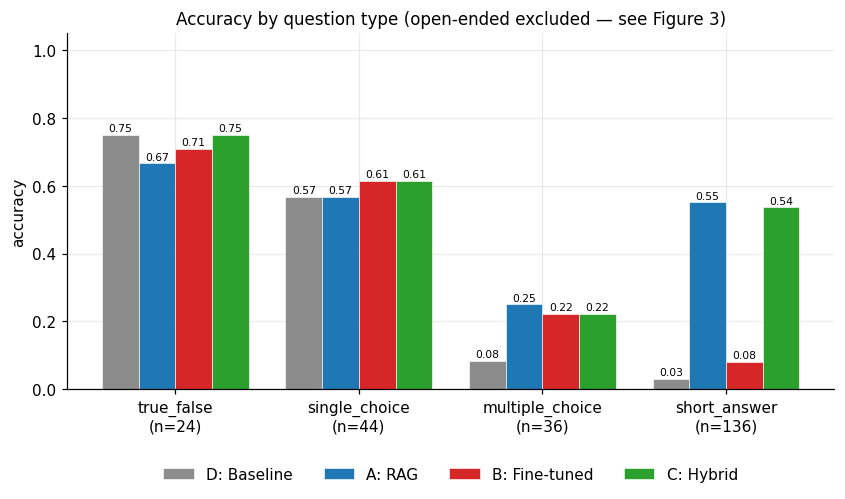

  saved fig03_open_ended_quality.png


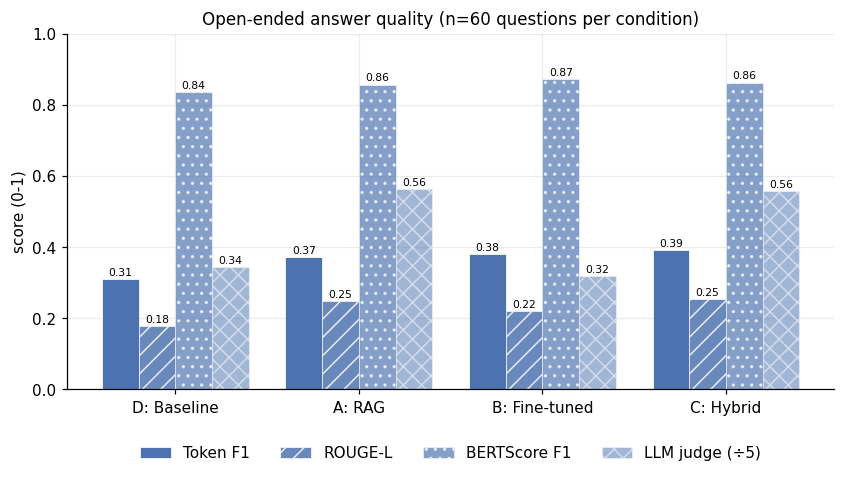

  saved fig04_hallucination_profile.png


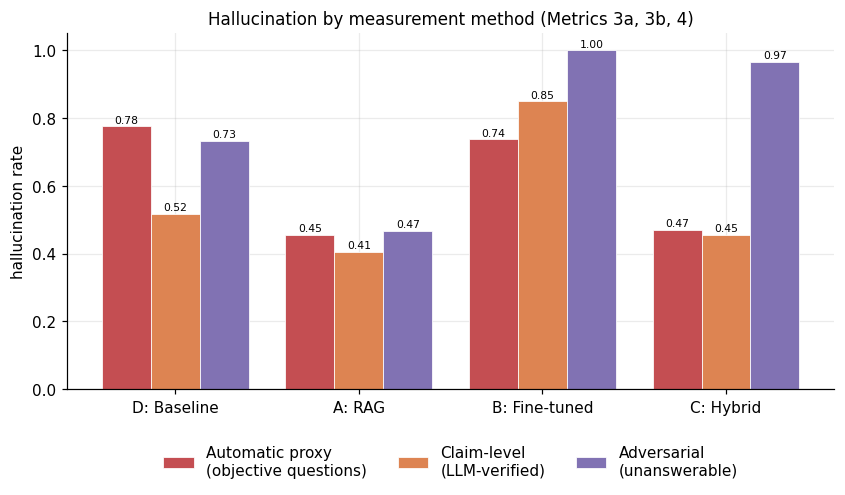

In [ ]:
# ============================================================
# FIGURES 2-4 — correctness, open-ended quality, hallucination
# ============================================================
CONDS = [c for c in CONDITIONS if c in main]
X = np.arange(len(CONDS))

# ---------- Figure 2: accuracy by question type ----------
types_present = [t for t in ["true_false", "single_choice", "multiple_choice", "short_answer"]
                 if t in per_type.index]
fig, ax = plt.subplots(figsize=(9, 4.2))
w = 0.8 / max(len(CONDS), 1)
for i, c in enumerate(CONDS):
    vals = [per_type.loc[t, c] if t in per_type.index else np.nan for t in types_present]
    ax.bar(np.arange(len(types_present)) + i * w - 0.4 + w / 2, vals, w,
           label=COND_LABELS.get(c, c), color=cond_colour(c), edgecolor="white", linewidth=0.4)
ax.set_xticks(np.arange(len(types_present)))
ax.set_xticklabels([f"{t}\n(n={int(type_counts.get(t, 0))})" for t in types_present])
ax.set_ylabel("accuracy"); ax.set_ylim(0, 1.05)
ax.set_title("Accuracy by question type (open-ended excluded — see Figure 3)")
ax.legend(frameon=False, ncol=len(CONDS), loc="upper center", bbox_to_anchor=(0.5, -0.18))
bar_labels(ax)
save_fig(fig, "fig02_accuracy_by_type",
         "Objective accuracy by question type for each condition. Open-ended questions "
         "are excluded because they have no binary correctness; n per type is shown on "
         "the axis to make small-sample types explicit.")
plt.show()

# ---------- Figure 3: open-ended quality (the empty-bar fix) ----------
# The previous chart plotted `correct` for every type. Open-ended rows have no
# binary correctness, so that series was entirely null and rendered as a gap.
# Open-ended answers are instead scored on four continuous measures, rescaled to
# a common 0-1 axis so they can share one panel.
open_metrics = [("token_f1", "Token F1"), ("rougeL", "ROUGE-L")]
if "bertscore_f1" in open_quality.columns:
    open_metrics.append(("bertscore_f1", "BERTScore F1"))
if "judge_correctness_norm" in open_quality.columns:
    open_metrics.append(("judge_correctness_norm", "LLM judge (÷5)"))

fig, ax = plt.subplots(figsize=(9, 4.2))
w = 0.8 / len(open_metrics)
hatches = ["", "//", "..", "xx"]
for j, (col, label) in enumerate(open_metrics):
    vals = [open_quality.loc[c, col] if col in open_quality.columns else np.nan for c in CONDS]
    ax.bar(X + j * w - 0.4 + w / 2, vals, w, label=label,
           color="#4c72b0", alpha=1 - 0.16 * j, hatch=hatches[j % len(hatches)],
           edgecolor="white", linewidth=0.5)
n_open = int(open_quality["n_open"].iloc[0]) if len(open_quality) else 0
ax.set_xticks(X); ax.set_xticklabels([COND_LABELS.get(c, c) for c in CONDS])
ax.set_ylabel("score (0-1)"); ax.set_ylim(0, 1.0)
ax.set_title(f"Open-ended answer quality (n={n_open} questions per condition)")
ax.legend(frameon=False, ncol=len(open_metrics), loc="upper center", bbox_to_anchor=(0.5, -0.12))
bar_labels(ax)
save_fig(fig, "fig03_open_ended_quality",
         "Open-ended answer quality on four complementary measures. BERTScore is "
         "bounded well above zero by construction, so differences rather than absolute "
         "levels are the meaningful comparison.")
plt.show()

# ---------- Figure 4: hallucination profile ----------
fig, ax = plt.subplots(figsize=(9, 4.2))
series = [("halluc_proxy_rate", "Automatic proxy\n(objective questions)", overall)]
if len(CLAIM_HALLU):
    ch = CLAIM_HALLU.set_index("condition")
    series.append(("claim_halluc_rate", "Claim-level\n(LLM-verified)", ch))
if "adv_hallucination_rate" in robustness.columns:
    series.append(("adv_hallucination_rate", "Adversarial\n(unanswerable)", robustness))

w = 0.8 / len(series)
for j, (col, label, src) in enumerate(series):
    vals = [src.loc[c, col] if (c in src.index and col in src.columns) else np.nan for c in CONDS]
    ax.bar(X + j * w - 0.4 + w / 2, vals, w, label=label,
           color=["#c44e52", "#dd8452", "#8172b3"][j % 3], edgecolor="white", linewidth=0.5)
ax.set_xticks(X); ax.set_xticklabels([COND_LABELS.get(c, c) for c in CONDS])
ax.set_ylabel("hallucination rate"); ax.set_ylim(0, 1.05)
ax.set_title("Hallucination by measurement method (Metrics 3a, 3b, 4)")
ax.legend(frameon=False, ncol=len(series), loc="upper center", bbox_to_anchor=(0.5, -0.12))
bar_labels(ax)
save_fig(fig, "fig04_hallucination_profile",
         "Hallucination measured three ways. The automatic proxy counts confident wrong "
         "answers, the claim-level rate verifies decomposed claims against the corpus, and "
         "the adversarial rate counts non-abstentions on unanswerable questions.")
plt.show()


  saved fig05_accuracy_vs_cost.png


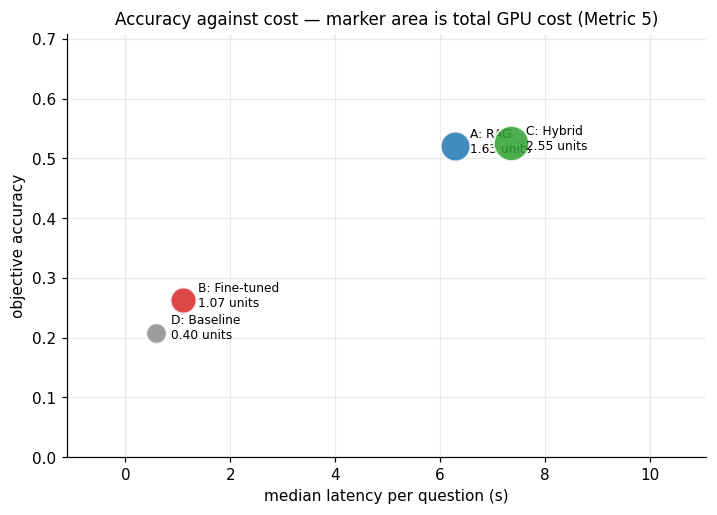

  saved fig06_paraphrase_robustness.png


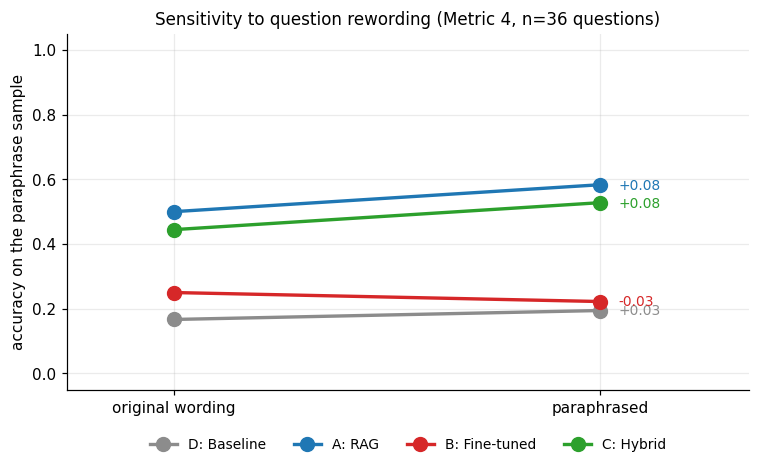

  saved fig07_adversarial_behaviour.png


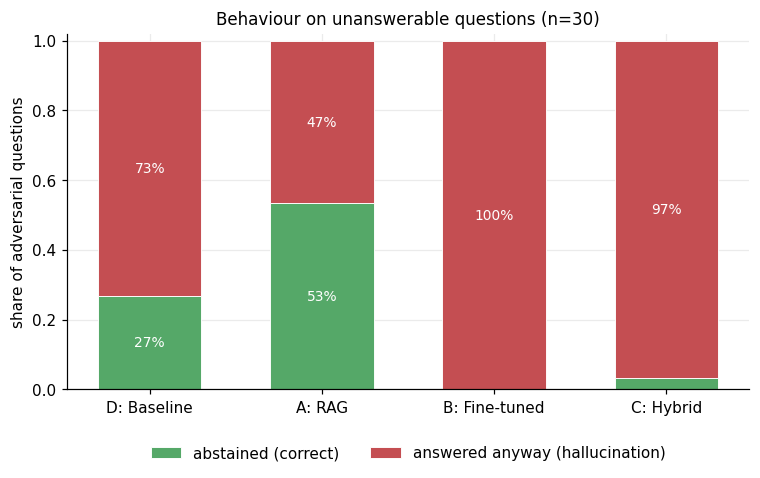

In [ ]:
# ============================================================
# FIGURES 5-7 — cost-benefit, paraphrase robustness, adversarial behaviour
# ============================================================

# ---------- Figure 5: accuracy against cost ----------
fig, ax = plt.subplots(figsize=(7.5, 5))
for c in CONDS:
    x = overall.loc[c, "latency_median_s"]
    y = overall.loc[c, "objective_accuracy"]
    units = cost_by_cond.loc[c, "est_colab_units"] if c in cost_by_cond.index else 1.0
    ax.scatter(x, y, s=120 + 420 * float(units) / max(cost_by_cond["est_colab_units"].max(), 1e-9),
               color=cond_colour(c), alpha=0.85, edgecolor="white", linewidth=1.5, zorder=3)
    ax.annotate(f"{COND_LABELS.get(c, c)}\n{units:.2f} units",
                (x, y), textcoords="offset points", xytext=(10, -4), fontsize=8)
ax.set_xlabel("median latency per question (s)")
ax.set_ylabel("objective accuracy")
ax.set_title("Accuracy against cost — marker area is total GPU cost (Metric 5)")
ax.set_ylim(0, min(1.0, max(overall["objective_accuracy"].max() * 1.35, 0.2)))
ax.margins(x=0.25)
_x0, _x1 = ax.get_xlim(); ax.set_xlim(_x0, _x1 + (_x1 - _x0) * 0.20)
save_fig(fig, "fig05_accuracy_vs_cost",
         "Accuracy against inference latency, with marker area proportional to total GPU "
         "cost including the one-off training cost carried by the tuned conditions. "
         "Upper-left is better.")
plt.show()

# ---------- Figure 6: paraphrase robustness ----------
if "paraphrased_acc" in robustness.columns and robustness["paraphrased_acc"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 4.2))
    for i, c in enumerate(CONDS):
        if c not in robustness.index: continue
        o = robustness.loc[c, "orig_acc_on_sample"]
        p = robustness.loc[c, "paraphrased_acc"]
        if pd.isna(o) or pd.isna(p): continue
        ax.plot([0, 1], [o, p], color=cond_colour(c), linewidth=2.2, marker="o",
                markersize=9, label=COND_LABELS.get(c, c), zorder=3)
        ax.annotate(f"{p - o:+.2f}", (1, p), textcoords="offset points",
                    xytext=(12, -3), fontsize=9, color=cond_colour(c))
    n_para = int(robustness["n_para"].max()) if "n_para" in robustness.columns else 0
    ax.set_xticks([0, 1]); ax.set_xticklabels(["original wording", "paraphrased"])
    ax.set_xlim(-0.25, 1.35); ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("accuracy on the paraphrase sample")
    ax.set_title(f"Sensitivity to question rewording (Metric 4, n={n_para} questions)")
    ax.legend(frameon=False, ncol=len(CONDS), loc="upper center",
              bbox_to_anchor=(0.5, -0.10), fontsize=9)
    save_fig(fig, "fig06_paraphrase_robustness",
             "Accuracy on the same questions before and after paraphrasing. A steep "
             "downward slope indicates a system keyed to surface wording rather than meaning.")
    plt.show()
else:
    print("Figure 6 skipped — no paraphrase results available.")

# ---------- Figure 7: behaviour on unanswerable questions ----------
if "adv_abstention_rate" in robustness.columns:
    fig, ax = plt.subplots(figsize=(8, 4.2))
    abst = [robustness.loc[c, "adv_abstention_rate"] if c in robustness.index else np.nan
            for c in CONDS]
    hall = [robustness.loc[c, "adv_hallucination_rate"] if c in robustness.index else np.nan
            for c in CONDS]
    ax.bar(X, abst, 0.6, label="abstained (correct)", color="#55a868",
           edgecolor="white", linewidth=0.6)
    ax.bar(X, hall, 0.6, bottom=abst, label="answered anyway (hallucination)",
           color="#c44e52", edgecolor="white", linewidth=0.6)
    for i, (a, h) in enumerate(zip(abst, hall)):
        if not pd.isna(a) and a > 0.06:
            ax.text(i, a / 2, f"{a:.0%}", ha="center", va="center", color="white", fontsize=9)
        if not pd.isna(h) and h > 0.06:
            ax.text(i, a + h / 2, f"{h:.0%}", ha="center", va="center", color="white", fontsize=9)
    n_adv = int(robustness["n_adv"].max()) if "n_adv" in robustness.columns else 0
    ax.set_xticks(X); ax.set_xticklabels([COND_LABELS.get(c, c) for c in CONDS])
    ax.set_ylabel("share of adversarial questions"); ax.set_ylim(0, 1.02)
    ax.set_title(f"Behaviour on unanswerable questions (n={n_adv})")
    ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12))
    save_fig(fig, "fig07_adversarial_behaviour",
             "Response to questions with no answer in the corpus. Abstention is the correct "
             "behaviour; the red segment is fabricated content.")
    plt.show()
else:
    print("Figure 7 skipped — no adversarial results available.")


  saved fig08_answer_length.png


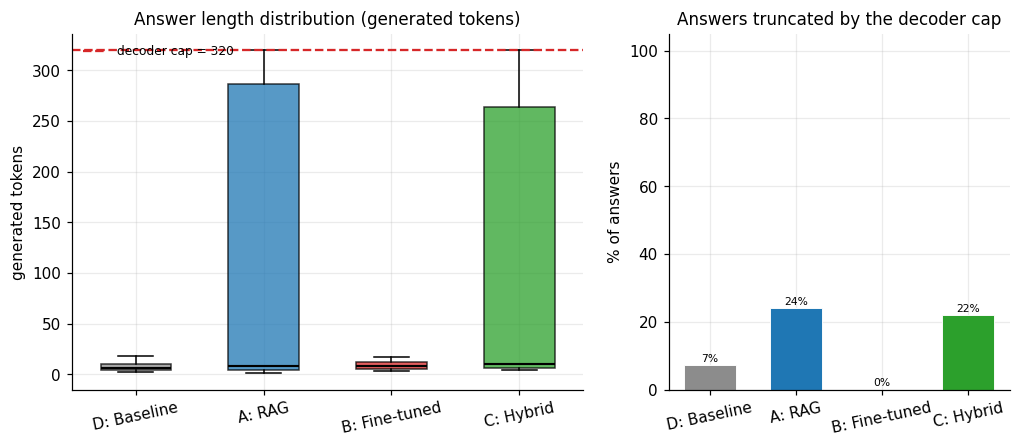

  saved fig09_response_profile.png


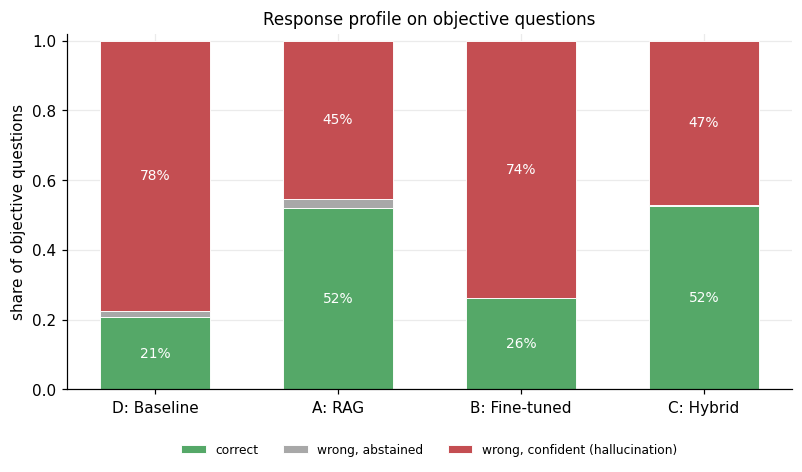

  saved fig10_retrieval_quality.png


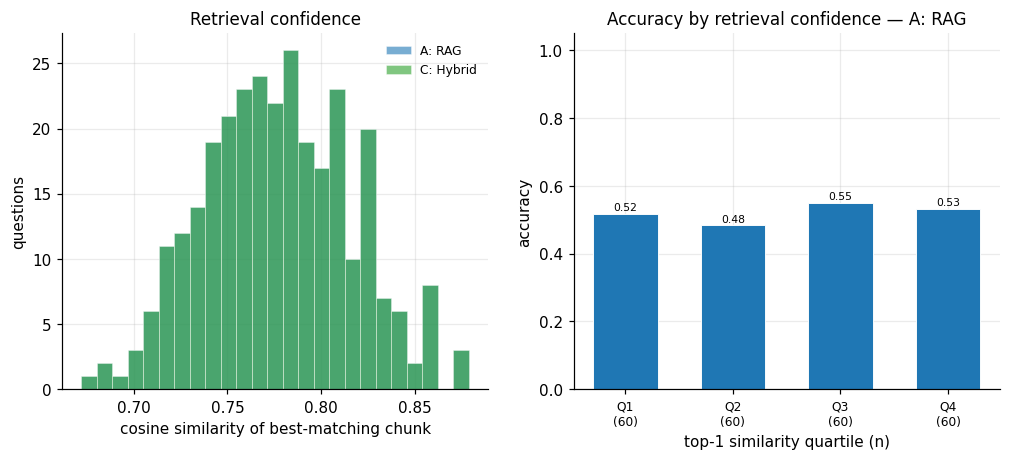

In [ ]:
# ============================================================
# FIGURES 8-10 — answer length, response profile, retrieval quality
# ============================================================

# ---------- Figure 8: answer length ----------
# A model that has lost its stop token shows up here first: generations pile up
# against MAX_NEW_TOKENS instead of terminating. This is the figure that
# distinguishes "fine-tuning changed the answers" from "fine-tuning broke
# termination", and it belongs in the write-up for exactly that reason.
len_col = "gen_tokens" if ("gen_tokens" in main[CONDS[0]].columns
                           and main[CONDS[0]]["gen_tokens"].notna().any()) else "pred_words"
unit = "generated tokens" if len_col == "gen_tokens" else "words in answer"

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2),
                         gridspec_kw={"width_ratios": [1.5, 1]})
data = [main[c][len_col].dropna().values for c in CONDS]
bp = axes[0].boxplot(data, tick_labels=[COND_LABELS.get(c, c) for c in CONDS],
                     patch_artist=True, showfliers=False, widths=0.55)
for patch, c in zip(bp["boxes"], CONDS):
    patch.set_facecolor(cond_colour(c)); patch.set_alpha(0.75)
for med in bp["medians"]:
    med.set_color("black"); med.set_linewidth(1.4)
if len_col == "gen_tokens":
    axes[0].axhline(MAX_NEW_TOKENS, color="#d62728", linestyle="--", linewidth=1.5,
                    label=f"decoder cap = {MAX_NEW_TOKENS}")
    axes[0].legend(frameon=False, fontsize=8)
axes[0].set_ylabel(unit); axes[0].set_title(f"Answer length distribution ({unit})")
axes[0].tick_params(axis="x", labelrotation=12)

if "hit_token_cap" in main[CONDS[0]].columns and main[CONDS[0]]["hit_token_cap"].notna().any():
    caps = [main[c]["hit_token_cap"].mean() * 100 for c in CONDS]
    axes[1].bar(X, caps, 0.6, color=[cond_colour(c) for c in CONDS],
                edgecolor="white", linewidth=0.6)
    axes[1].set_xticks(X)
    axes[1].set_xticklabels([COND_LABELS.get(c, c) for c in CONDS], rotation=12)
    axes[1].set_ylabel("% of answers"); axes[1].set_ylim(0, 105)
    axes[1].set_title("Answers truncated by the decoder cap")
    bar_labels(axes[1], fmt="{:.0f}%")
else:
    axes[1].text(0.5, 0.5, "gen_tokens not recorded\n(re-run inference)",
                 ha="center", va="center", transform=axes[1].transAxes, fontsize=9)
    axes[1].set_axis_off()

save_fig(fig, "fig08_answer_length",
         "Answer length by condition against the decoder cap. A distribution pressed "
         "against the cap indicates the model is not emitting its stop token rather than "
         "genuinely producing longer answers.")
plt.show()

# ---------- Figure 9: response profile on objective questions ----------
fig, ax = plt.subplots(figsize=(8.5, 4.2))
corr, abst_wrong, conf_wrong = [], [], []
for c in CONDS:
    obj = main[c][main[c]["question_type"].isin(OBJECTIVE_TYPES)]
    n = max(len(obj), 1)
    ok = (obj["correct"] == 1.0)
    corr.append(ok.mean())
    abst_wrong.append(((~ok) & (obj["abstained"] == 1.0)).sum() / n)
    conf_wrong.append(((~ok) & (obj["abstained"] == 0.0)).sum() / n)
ax.bar(X, corr, 0.6, label="correct", color="#55a868", edgecolor="white", linewidth=0.6)
ax.bar(X, abst_wrong, 0.6, bottom=corr, label="wrong, abstained",
       color="#a8a8a8", edgecolor="white", linewidth=0.6)
ax.bar(X, conf_wrong, 0.6, bottom=np.add(corr, abst_wrong),
       label="wrong, confident (hallucination)", color="#c44e52",
       edgecolor="white", linewidth=0.6)
for i in range(len(CONDS)):
    for val, base in [(corr[i], 0), (abst_wrong[i], corr[i]),
                      (conf_wrong[i], corr[i] + abst_wrong[i])]:
        if val > 0.06:
            ax.text(i, base + val / 2, f"{val:.0%}", ha="center", va="center",
                    color="white", fontsize=9)
ax.set_xticks(X); ax.set_xticklabels([COND_LABELS.get(c, c) for c in CONDS])
ax.set_ylabel("share of objective questions"); ax.set_ylim(0, 1.02)
ax.set_title("Response profile on objective questions")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=8)
save_fig(fig, "fig09_response_profile",
         "Decomposition of every objective answer into correct, wrong-but-abstaining, and "
         "wrong-but-confident. The red band is the share of answers that are both wrong and "
         "assertive, which is the operationally dangerous category.")
plt.show()

# ---------- Figure 10: retrieval quality ----------
rag_conds = [c for c in CONDS if c in ("rag", "hybrid")
             and "retrieval_top1" in main[c].columns
             and main[c]["retrieval_top1"].notna().any()]
if rag_conds:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    for c in rag_conds:
        axes[0].hist(main[c]["retrieval_top1"].dropna(), bins=25, alpha=0.6,
                     label=COND_LABELS.get(c, c), color=cond_colour(c),
                     edgecolor="white", linewidth=0.4)
    axes[0].set_xlabel("cosine similarity of best-matching chunk")
    axes[0].set_ylabel("questions")
    axes[0].set_title("Retrieval confidence")
    axes[0].legend(frameon=False, fontsize=8)

    ref = rag_conds[0]
    obj = main[ref][main[ref]["question_type"].isin(OBJECTIVE_TYPES)].dropna(
        subset=["retrieval_top1", "correct"])
    if len(obj) >= 8:
        try:
            obj = obj.assign(bin=pd.qcut(obj["retrieval_top1"], 4, duplicates="drop"))
            grp = obj.groupby("bin", observed=True)["correct"].agg(["mean", "size"])
            axes[1].bar(range(len(grp)), grp["mean"], 0.6, color=cond_colour(ref),
                        edgecolor="white", linewidth=0.6)
            axes[1].set_xticks(range(len(grp)))
            axes[1].set_xticklabels([f"Q{i+1}\n({int(n)})" for i, n in
                                     enumerate(grp["size"])], fontsize=8)
            axes[1].set_xlabel("top-1 similarity quartile (n)")
            axes[1].set_ylabel("accuracy"); axes[1].set_ylim(0, 1.05)
            axes[1].set_title(f"Accuracy by retrieval confidence — {COND_LABELS.get(ref, ref)}")
            bar_labels(axes[1])
        except Exception as e:
            axes[1].text(0.5, 0.5, f"binning unavailable\n{e}", ha="center",
                         va="center", transform=axes[1].transAxes, fontsize=8)
            axes[1].set_axis_off()
    else:
        axes[1].text(0.5, 0.5, "too few scored rows", ha="center", va="center",
                     transform=axes[1].transAxes)
        axes[1].set_axis_off()

    save_fig(fig, "fig10_retrieval_quality",
             "Distribution of best-match similarity per question, and objective accuracy "
             "by similarity quartile. A flat right-hand panel would indicate that retrieval "
             "confidence carries no signal about answer correctness.")
    plt.show()
else:
    print("Figure 10 skipped — retrieval_top1 not recorded (re-run RAG/hybrid inference).")


  saved fig11_training_loss.png


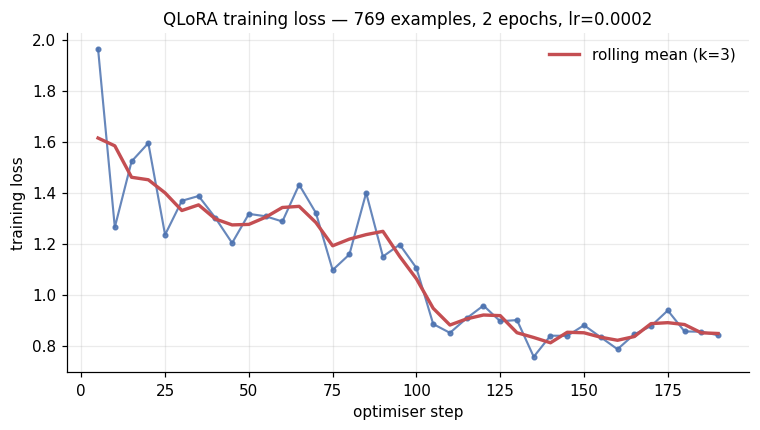

  saved fig12_results_heatmap.png


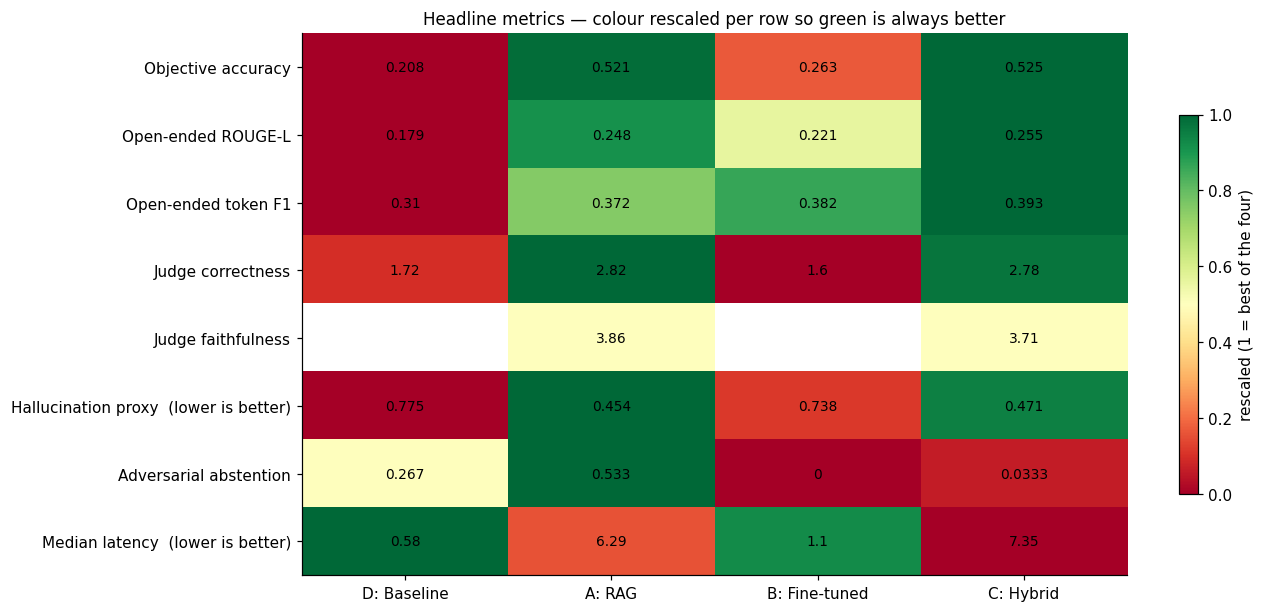

In [ ]:
# ============================================================
# FIGURES 11-12 — training loss, results heatmap
# ============================================================

# ---------- Figure 11: training loss ----------
_log_path = f"{OUT_DIR}/train_log_history.json"
if os.path.exists(_log_path):
    hist = json.load(open(_log_path))
    pts = [(h["step"], h["loss"]) for h in hist if "loss" in h and "step" in h]
    if pts:
        steps, losses = zip(*pts)
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(steps, losses, color="#4c72b0", linewidth=1.4, marker="o",
                markersize=3, alpha=0.85)
        if len(losses) >= 5:
            k = max(3, len(losses) // 12)
            smooth = pd.Series(losses).rolling(k, center=True, min_periods=1).mean()
            ax.plot(steps, smooth, color="#c44e52", linewidth=2.2,
                    label=f"rolling mean (k={k})")
            ax.legend(frameon=False)
        ax.set_xlabel("optimiser step"); ax.set_ylabel("training loss")
        ax.set_title(f"QLoRA training loss — {len(train_df)} examples, "
                     f"{EPOCHS} epochs, lr={LEARNING_RATE}")
        save_fig(fig, "fig11_training_loss",
                 "QLoRA training loss. Colab renders the live curve as a widget that does "
                 "not survive saving the notebook, so it is reconstructed here from the "
                 "persisted log history.")
        plt.show()
    else:
        print("Figure 11 skipped — log history contains no loss entries.")
else:
    print(f"Figure 11 skipped — {_log_path} not found (run Section 7).")

# ---------- Figure 12: results heatmap ----------
# One panel summarising every headline metric. Each row is min-max rescaled
# across conditions so that colour always means "better", regardless of whether
# the underlying metric is maximised or minimised.
heat_spec = [
    ("objective_accuracy", "Objective accuracy", overall, True),
    ("open_rougeL",        "Open-ended ROUGE-L", overall, True),
    ("open_token_f1",      "Open-ended token F1", overall, True),
    ("judge_correctness",  "Judge correctness", overall, True),
    ("judge_faithfulness", "Judge faithfulness", overall, True),
    ("halluc_proxy_rate",  "Hallucination proxy", overall, False),
    ("adv_abstention_rate", "Adversarial abstention", robustness, True),
    ("latency_median_s",   "Median latency", overall, False),
]
rows_lbl, mat = [], []
for col, label, src, higher_better in heat_spec:
    if col not in src.columns: continue
    vals = np.array([src.loc[c, col] if c in src.index else np.nan for c in CONDS],
                    dtype=float)
    if np.all(np.isnan(vals)): continue
    lo, hi = np.nanmin(vals), np.nanmax(vals)
    spread, scale = hi - lo, max(abs(hi), abs(lo), 1e-9)
    # A row populated for only one or two conditions, or whose spread is
    # negligible next to the values themselves, would otherwise be painted full
    # red and green off a rounding difference. Such rows are shown neutral.
    if np.count_nonzero(~np.isnan(vals)) < 3 or spread / scale < 0.05:
        norm = np.where(np.isnan(vals), np.nan, 0.5)
    else:
        norm = (vals - lo) / spread
    if not higher_better:
        norm = 1 - norm
    rows_lbl.append(label + ("" if higher_better else "  (lower is better)"))
    mat.append(norm)

if mat:
    mat = np.array(mat)
    raw = []
    for col, label, src, hb in heat_spec:
        if col not in src.columns: continue
        v = np.array([src.loc[c, col] if c in src.index else np.nan for c in CONDS], dtype=float)
        if np.all(np.isnan(v)): continue
        raw.append(v)
    raw = np.array(raw)

    fig, ax = plt.subplots(figsize=(1.9 * len(CONDS) + 4.5, 0.55 * len(rows_lbl) + 2))
    im = ax.imshow(mat, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(CONDS)))
    ax.set_xticklabels([COND_LABELS.get(c, c) for c in CONDS])
    ax.set_yticks(range(len(rows_lbl))); ax.set_yticklabels(rows_lbl)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if not np.isnan(raw[i, j]):
                ax.text(j, i, f"{raw[i, j]:.3g}", ha="center", va="center",
                        fontsize=9, color="black")
    ax.set_title("Headline metrics — colour rescaled per row so green is always better")
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.7, label="rescaled (1 = best of the four)")
    save_fig(fig, "fig12_results_heatmap",
             "All headline metrics in one panel. Cell values are the raw metric; colour is "
             "min-max rescaled within each row so that green always indicates the better "
             "result, including for metrics where lower is better.")
    plt.show()
else:
    print("Figure 12 skipped — no metrics available.")


### Figures 13–15 — per-bank results

Figure 13 answers "does the pooled ranking hold in all three reports?". Figure 14 shows whether retrieval ever found the right institution, and where it went instead. Figure 15 separates abstention behaviour by *why* a question is unanswerable.


  saved fig13_accuracy_by_bank.png


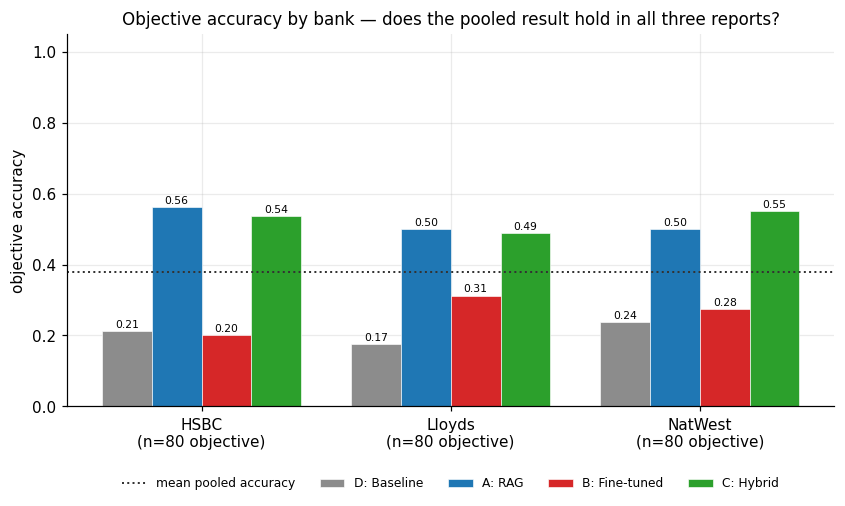

  saved fig14_retrieval_bank_precision.png


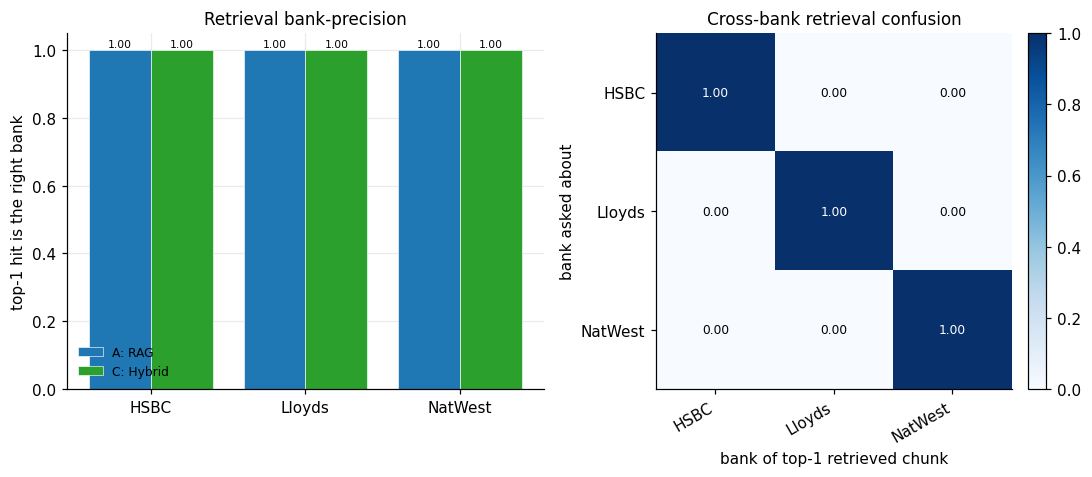

  saved fig15_adversarial_by_tier.png


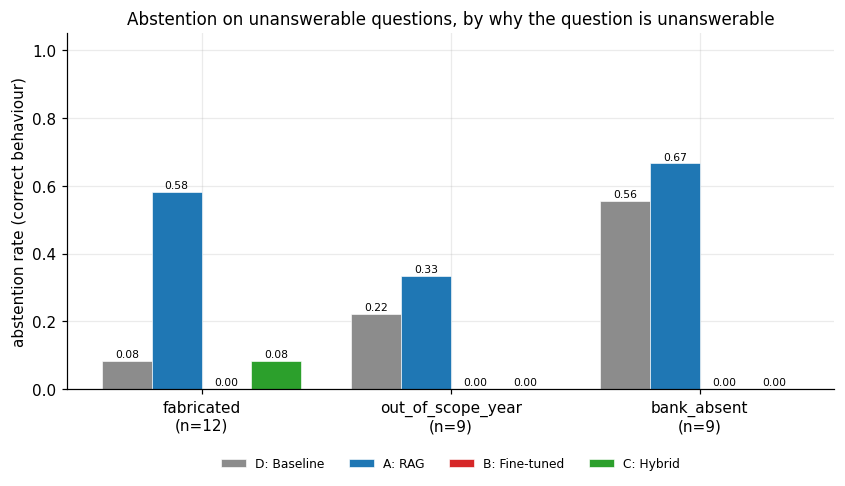

In [ ]:
# ============================================================
# FIGURES 13-15 — per-bank results (v8)
# ============================================================

# ---------- Figure 13: accuracy by bank and condition ----------
if len(per_bank_acc):
    banks_present = [b for b in [bank_label(t) for t in BANK_TAGS] if b in per_bank_acc.index]
    fig, ax = plt.subplots(figsize=(9, 4.4))
    w = 0.8 / max(len(CONDS), 1)
    for i, c in enumerate(CONDS):
        vals = [per_bank_acc.loc[b, c] if c in per_bank_acc.columns else np.nan
                for b in banks_present]
        ax.bar(np.arange(len(banks_present)) + i * w - 0.4 + w / 2, vals, w,
               label=COND_LABELS.get(c, c), color=cond_colour(c),
               edgecolor="white", linewidth=0.4)
    pooled_vals = [overall.loc[c, "objective_accuracy"] for c in CONDS]
    ax.axhline(float(np.mean(pooled_vals)), color="#333333", linestyle=":", linewidth=1.3,
               label="mean pooled accuracy")
    ns = per_bank_long.groupby("bank")["n_objective"].max()
    ax.set_xticks(np.arange(len(banks_present)))
    ax.set_xticklabels([f"{b}\n(n={int(ns.get(b, 0))} objective)" for b in banks_present])
    ax.set_ylabel("objective accuracy"); ax.set_ylim(0, 1.05)
    ax.set_title("Objective accuracy by bank — does the pooled result hold in all three reports?")
    ax.legend(frameon=False, ncol=len(CONDS) + 1, loc="upper center",
              bbox_to_anchor=(0.5, -0.16), fontsize=8)
    bar_labels(ax)
    save_fig(fig, "fig13_accuracy_by_bank",
             "Objective accuracy split by bank. Bars that move together across the three "
             "reports support the pooled comparison; a condition that wins on one bank and "
             "loses on another is reporting coverage or retrieval behaviour rather than a "
             "property of the strategy.")
    plt.show()
else:
    print("Figure 13 skipped — no per-bank results available.")

# ---------- Figure 14: cross-bank retrieval confusion ----------
if len(retrieval_by_bank):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2),
                             gridspec_kw={"width_ratios": [1.15, 1]})

    # left: top-1 correct-bank rate per bank, per RAG condition
    rag_conds = sorted(retrieval_by_bank["condition"].unique(),
                       key=lambda c: CONDITIONS.index(c) if c in CONDITIONS else 99)
    banks_r = [b for b in [bank_label(t) for t in BANK_TAGS]
               if b in set(retrieval_by_bank["bank"])]
    w = 0.8 / max(len(rag_conds), 1)
    for i, c in enumerate(rag_conds):
        sub = retrieval_by_bank[retrieval_by_bank["condition"] == c].set_index("bank")
        vals = [sub.loc[b, "top1_correct_bank"] if b in sub.index else np.nan for b in banks_r]
        axes[0].bar(np.arange(len(banks_r)) + i * w - 0.4 + w / 2, vals, w,
                    label=COND_LABELS.get(c, c), color=cond_colour(c),
                    edgecolor="white", linewidth=0.4)
    axes[0].set_xticks(np.arange(len(banks_r))); axes[0].set_xticklabels(banks_r)
    axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("top-1 hit is the right bank")
    axes[0].set_title("Retrieval bank-precision")
    axes[0].legend(frameon=False, fontsize=8)
    bar_labels(axes[0])

    # right: confusion matrix
    im = axes[1].imshow(conf_tab.values, cmap="Blues", vmin=0, vmax=1)
    axes[1].set_xticks(range(len(conf_tab.columns)))
    axes[1].set_xticklabels(conf_tab.columns, rotation=30, ha="right")
    axes[1].set_yticks(range(len(conf_tab.index)))
    axes[1].set_yticklabels(conf_tab.index)
    axes[1].set_xlabel("bank of top-1 retrieved chunk"); axes[1].set_ylabel("bank asked about")
    axes[1].set_title("Cross-bank retrieval confusion")
    axes[1].grid(False)
    for r in range(conf_tab.shape[0]):
        for cc in range(conf_tab.shape[1]):
            v = conf_tab.values[r, cc]
            axes[1].text(cc, r, f"{v:.2f}", ha="center", va="center", fontsize=8,
                         color="white" if v > 0.55 else "black")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    save_fig(fig, "fig14_retrieval_bank_precision",
             "Retrieval bank-precision and the cross-bank confusion matrix. The three "
             "reports use near-identical statement wording, so a passage retrieved with a "
             "high similarity score can still belong to the wrong institution; mass off "
             "the diagonal is context that was well-matched and wrong.")
    plt.show()
else:
    print("Figure 14 skipped — no retrieval bank-precision data.")

# ---------- Figure 15: adversarial abstention by tier ----------
if len(adv_by_tier):
    tiers = [t for t in ["fabricated", "out_of_scope_year", "bank_absent"]
             if t in set(adv_by_tier["adv_tier"])]
    fig, ax = plt.subplots(figsize=(9, 4.2))
    w = 0.8 / max(len(CONDS), 1)
    for i, c in enumerate(CONDS):
        sub = adv_by_tier[adv_by_tier["condition"] == c].set_index("adv_tier")
        vals = [sub.loc[t, "abstention_rate"] if t in sub.index else np.nan for t in tiers]
        ax.bar(np.arange(len(tiers)) + i * w - 0.4 + w / 2, vals, w,
               label=COND_LABELS.get(c, c), color=cond_colour(c),
               edgecolor="white", linewidth=0.4)
    tier_n = adv_by_tier.groupby("adv_tier")["n"].max()
    ax.set_xticks(np.arange(len(tiers)))
    ax.set_xticklabels([f"{t}\n(n={int(tier_n.get(t, 0))})" for t in tiers])
    ax.set_ylim(0, 1.05); ax.set_ylabel("abstention rate (correct behaviour)")
    ax.set_title("Abstention on unanswerable questions, by why the question is unanswerable")
    ax.legend(frameon=False, ncol=len(CONDS), loc="upper center",
              bbox_to_anchor=(0.5, -0.16), fontsize=8)
    bar_labels(ax)
    save_fig(fig, "fig15_adversarial_by_tier",
             "Abstention rate on the three adversarial tiers. Fabricated premises are "
             "unanswerable for any corpus; out-of-scope-year questions name a real bank and "
             "a real metric and are the tier where a fine-tuned model is most likely to "
             "answer from parametric memory; bank-absent questions concern institutions "
             "outside the index.")
    plt.show()
else:
    print("Figure 15 skipped — no tiered adversarial results.")


In [ ]:
# ------------------------------------------------------------------
# Figure manifest — captions ready to paste into the results chapter
# ------------------------------------------------------------------
fig_index = pd.DataFrame(FIGURE_INDEX)
if len(fig_index):
    fig_index.to_csv(f"{OUT_DIR}/figure_index.csv", index=False)
    with open(f"{OUT_DIR}/figure_captions.md", "w") as f:
        for i, r in fig_index.iterrows():
            f.write(f"**{r['figure']}** — {r['caption']}\n\n")
    print(f"{len(fig_index)} figures written to {FIG_DIR}\n")
    for _, r in fig_index.iterrows():
        print(f"  {r['figure']}")
    print(f"\nManifest: figure_index.csv, figure_captions.md")
else:
    print("No figures recorded — run the figure cells above.")


16 figures written to /content/drive/MyDrive/dissertation/runs/v8/figures

  fig00_training_length_budget
  fig01_corpus_profile
  fig02_accuracy_by_type
  fig03_open_ended_quality
  fig04_hallucination_profile
  fig05_accuracy_vs_cost
  fig06_paraphrase_robustness
  fig07_adversarial_behaviour
  fig08_answer_length
  fig09_response_profile
  fig10_retrieval_quality
  fig11_training_loss
  fig12_results_heatmap
  fig13_accuracy_by_bank
  fig14_retrieval_bank_precision
  fig15_adversarial_by_tier

Manifest: figure_index.csv, figure_captions.md


---
### RQ / metric coverage checklist
- **RQ1** (which metrics): the framework above — each metric's computation method is in the
  corresponding section, ready to transfer into the methodology chapter with its ToR grounding.
- **RQ2** (how do the four systems compare): `summary_overall.csv` + `summary_per_type.csv`
  + `summary_open_ended.csv`, with Figures 02, 03, 04 and 12 — then `summary_per_bank.csv`
  and Figure 13 to show the comparison holds in all three reports rather than in one.
- **RQ3** (cost / practicality): `summary_cost_by_condition.csv` and Figure 05.

### Before reporting anything, check
1. **`train_tokenisation_stats.json`** — `dropped_no_room` should be near zero and every
   example must have passed the EOS assertion. The stop-token probe in Section 8 must not
   report that every prompt hit the cap.
2. **`corpus_log.json`** — check `per_bank`. If one bank has materially fewer chunks than
   another, its RAG results are worse for reasons that have nothing to do with the retrieval
   strategy, and the chunk counts must be quoted alongside the per-bank table. If the overall
   coverage warning fired, the claim-level hallucination rates and the adversarial set are
   measuring corpus thinness rather than model behaviour.
3. **`summary_retrieval_confusion.csv`** — off-diagonal mass is context that was retrieved
   confidently from the wrong institution. If it is large, it is the dominant error source in
   the RAG and Hybrid conditions and belongs in the limitations discussion, not in a claim
   about the strategy.
4. **`summary_bank_spread.csv`** — a condition whose accuracy varies by more than ~10 points
   across the three banks is not one number. Report the per-bank figures with it.
5. **`filter_log.json` → `train_bank_mix`** — a lopsided training mix is the alternative
   explanation for any fine-tuned/baseline gap that appears on one bank only.
6. **`judge_coverage.json`** — confirms how many answers each judge metric actually covers,
   and when. Judge numbers without this file have no audit trail.
7. **N with every claim.** `summary_per_type.csv`, `summary_per_bank.csv` and
   `summary_robustness.csv` all carry their own N. Per-bank × per-type cells are roughly a
   third the size of the pooled ones and the loader in Section 2 flags any below n=5.
8. **Latency** — quote `summary_latency_by_type.csv`, not the pooled median, which mostly
   reflects the question-type mix.
9. **Eval N** — if `EVAL_SUBSAMPLE_N` was set, the reported N is the subsample, not 300.
